In [163]:

from spiketurnpike_postanalysis.Extract_ephys_from_struct import ExtractEphysData
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import mannwhitneyu, kruskal, shapiro, ttest_ind
from scipy import stats

import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'


# class and methods set up 

In [670]:


class DataFrameManager:
    def __init__(self, eed_object):
        self.eed = eed_object
        self.dataframes = {}  # Dictionary to hold multiple DataFrames
        self.detailed_dataframes = {}

    def create_dataframe(self, columns, df_name):
        data = []
        # Assuming the eed object has a structure similar to what you described
        for groupname, recordings in self.eed.all_data.items():
            for recordingname, cells in recordings.items():
                for cid, metrics in cells.items():
                    row = {'groupname': groupname, 'recordingname': recordingname, 'cid': cid}
                    for column in columns:
                        row[column] = metrics.get(column, None)
                    data.append(row)
        
        new_df = pd.DataFrame(data)
        if df_name in self.dataframes:
            self.dataframes[df_name] = pd.concat([self.dataframes[df_name], new_df], ignore_index=True)
        else:
            self.dataframes[df_name] = new_df
    
    def append_data(self, df_name, new_data):
        if df_name in self.dataframes:
            self.dataframes[df_name] = pd.concat([self.dataframes[df_name], new_data], ignore_index=True)
        else:
            self.dataframes[df_name] = new_data
            
    def get_filtered_data(self, df_name, is_single_unit=None, cell_type=None, stim_responsivity=None, groupname=None):
        """
        Retrieve filtered data from the specified DataFrame based on IsSingleUnit, Cell_Type, 
        and StimResponsivity with the option to not filter on any of these by passing None.

        Parameters:
        df_name (str): Name of the DataFrame to filter.
        is_single_unit (float or None): If 1.0, filter for single units, if 0.0, filter for non-single units, 
                                        if None, do not filter by this criterion.
        cell_type (str or None): Filter for 'FS' or 'RS' cell types. If None, no filtering by cell type.
        stim_responsivity (float or None): Value to filter by in the StimResponsivity column. Can be 1.0, 0.0, or -1.0.
                                           If None, no filtering by StimResponsivity.

        Returns:
        pandas.DataFrame: The filtered DataFrame.
        """
        if df_name not in self.dataframes:
            print(f"No DataFrame found with the name '{df_name}'.")
            return None

        # Start with the full DataFrame
        filtered_df = self.dataframes[df_name]

        # Filter by cell type if provided
        if cell_type:
            filtered_df = filtered_df[filtered_df['Cell_Type'] == cell_type]

        # Filter by IsSingleUnit if not None
        if is_single_unit is not None:
            filtered_df = filtered_df[filtered_df['IsSingleUnit'] == is_single_unit]

        # Filter by StimResponsivity if not None
        if stim_responsivity is not None:
            filtered_df = filtered_df[filtered_df['StimResponsivity'] == stim_responsivity]
        if groupname is not None:
            filtered_df = filtered_df[filtered_df['groupname'] == groupname]

        return filtered_df
   
    def create_psth_dataframe(self):
        """
        Creates and stores a DataFrame for each stimulation type using the 'SpikeTrains_for_PSTHs' and 'PSTHs_raw' columns from the base PSTH DataFrame. 
        Each DataFrame is stored as an attribute of the DataFrameManager under a name that corresponds to the stimulation type.

        Details:
            'SpikeTrains_for_PSTHs' is expected to be a pandas Series where each entry is a list of arrays.
            Each array in the list corresponds to spike train data for one of the four distinct stimulations, with dimensions (n_trials, n_time_points), 
            where 'n_trials' varies per stimulation and 'n_time_points' is consistent (usually the length of the trial in ms).

            'PSTHs_raw' is expected to be a pandas Series where each entry is a numpy ndarray with dimensions (4, n_time_points), 
            where the first dimension corresponds to the four stimulation types and 'n_time_points' matches the second dimension of the arrays in 'SpikeTrains_for_PSTHs'.

        Processes:
            - A base DataFrame is created with necessary columns.
            - For each stimulation label (e.g., 'Zero', 'Low', 'Mid', 'Max'), a new DataFrame is created.
            - Each new DataFrame includes adjusted 'SpikeTrains_for_PSTHs' and 'PSTHs_raw' columns to isolate the data corresponding to the respective stimulation type.
            - Each DataFrame is stored in the class dictionary, keyed by the name 'psth_dataframe_' followed by the stimulation label.
        """
        # Create the base dataframe for PSTH analysis
        self.create_dataframe(['Cell_Type', 'LaminarLabel','IsSingleUnit', 'StimResponsivity', 'SpikeTrains_for_PSTHs', 'PSTHs_raw', 'ModulationIndex'], 'psth_dataframe')

        # Extracting trial tags
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']

        # Process each label
        for index, label in enumerate(stim_labels):
            # Retrieve spike trains and PSTHs for each label and create a new DataFrame
            df_name = f'psth_dataframe_{label}'
            self.dataframes[df_name] = self.dataframes['psth_dataframe'].copy()
            self.dataframes[df_name]['SpikeTrains_for_PSTHs'] = self.dataframes['psth_dataframe']['SpikeTrains_for_PSTHs'].apply(lambda x: x[index])
            self.dataframes[df_name]['PSTHs_raw'] = self.dataframes['psth_dataframe']['PSTHs_raw'].apply(lambda x: x[index])

    def create_psth_dataframe_opto(self):
        """
        Creates and stores a DataFrame for optogenetic stimulation using the 'SpikeTrains_for_PSTHs' and 'PSTHs_raw' columns from the base PSTH DataFrame. 
        The DataFrame is stored as an attribute of the DataFrameManager under a name that corresponds to the optogenetic stimulation type.

        Details:
            'SpikeTrains_for_PSTHs' is expected to be a pandas Series where each entry is an array of spike train data for the optogenetic stimulation,
            with dimensions (n_trials, n_time_points), where 'n_trials' is the number of trials and 'n_time_points' is consistent (usually the length of the trial in ms).

            'PSTHs_raw' is expected to be a pandas Series where each entry is a numpy ndarray with dimensions (n_time_points),
            where 'n_time_points' is consistent and should be 1500, corresponding to the time points of the optogenetic stimulation.

        Processes:
            - A base DataFrame is created with necessary columns.
            - Retrieve trial tags specific for optogenetic stimulation.
            - For each label (expected to be one for optogenetic stimulation), a new DataFrame is created.
            - Adjusted 'SpikeTrains_for_PSTHs' and 'PSTHs_raw' columns are created to isolate the data corresponding to the optogenetic stimulation.
            - The DataFrame is stored in the class dictionary, keyed by the name 'psth_dataframe_' followed by the stimulation label.
        """
        # Create the base dataframe for PSTH analysis
        self.create_dataframe(['Cell_Type', 'LaminarLabel', 'IsSingleUnit', 'StimResponsivity', 'SpikeTrains_for_PSTHs', 'PSTHs_raw'], 'psth_dataframe')

        # Extracting trial tags
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # This should only contain the optogenetic stimulation label

        # Process each label (typically only one for optogenetic stimulation)
        for index, label in enumerate(stim_labels):
            # Create a new DataFrame for optogenetic stimulation
            df_name = f'psth_dataframe_{label}'
            self.dataframes[df_name] = self.dataframes['psth_dataframe'].copy()
            self.dataframes[df_name]['SpikeTrains_for_PSTHs'] = self.dataframes['psth_dataframe']['SpikeTrains_for_PSTHs'].apply(lambda x: x[index])
            # Keep the same number of time points (1500) for the PSTH data
            self.dataframes[df_name]['PSTHs_raw'] = self.dataframes['psth_dataframe']['PSTHs_raw'].apply(lambda x: x[:, index] if x.ndim > 1 else x)
            
    def plot_psth(self, stim_label, cell_type=None, is_single_unit=None, stim_responsivity=None, groupname=None):
        """
        Plots the PSTH for a given stimulation type, with optional filtering on cell type, single unit status, and stimulus responsivity.
        Uses the 'relative_time_ms' from the ExtractEphysData object to correctly label the time axis.

        Args:
            stim_label (str): The label of the stimulation type to plot (e.g., 'Zero', 'Low', 'Mid', 'Max').
            cell_type (str, optional): Filter for specific cell types (e.g., 'FS', 'RS'). Default is None, which means no filtering by cell type.
            is_single_unit (float, optional): Filter for single units (1.0) or multi-units (0.0). None means no filtering.
            stim_responsivity (float, optional): Filter by stimulus responsivity (1.0, 0.0, -1.0). None means no filtering.

        Processes:
            - Retrieves the corresponding DataFrame for the specified stimulation.
            - Applies additional filtering based on the provided arguments.
            - Averages the PSTH data across all remaining units and plots the result using the relative time axis.
        """
        # Retrieve the DataFrame for the specified stimulation
        df_name = f'psth_dataframe_{stim_label}'
        if df_name not in self.dataframes:
            print(f"No data available for the stimulation: {stim_label}")
            return

        df = self.dataframes[df_name]

        # Apply filtering based on the optional parameters
        if cell_type is not None:
            df = df[df['Cell_Type'] == cell_type]
        if is_single_unit is not None:
            df = df[df['IsSingleUnit'] == is_single_unit]
        if stim_responsivity is not None:
            df = df[df['StimResponsivity'] == stim_responsivity]
        if groupname is not None:
            df = df[df['groupname'] == groupname]

        # Check if there is any data left after filtering
        if df.empty:
            print("No data matches the specified filters.")
            return

        # Get relative time array for x-axis
        time_array = self.eed.relative_time_ms['relative_time_ms']

        # Aggregate the PSTH data
        aggregated_psth = df['PSTHs_raw'].apply(pd.Series).mean(axis=0)

        # Plotting the aggregated PSTH
        plt.figure(figsize=(10, 5))
        plt.plot(time_array, aggregated_psth, label=f'PSTH for {stim_label}')
        plt.title(f'PSTH for {stim_label} - {cell_type or "All Types"}, SingleUnit: {is_single_unit}, Responsivity: {stim_responsivity}')
        plt.xlabel('Time (ms)')
        plt.ylabel('Average Spike Rate')
        plt.legend()
        plt.show()
    
    def create_time_mask(self, time_array, time_range):
        """
        Creates a mask for the time array based on the specified time range.
        
        Args:
            time_array (np.array): The array of time points.
            time_range (tuple): The start and end time for the mask (in ms).
            
        Returns:
            time_mask (np.array): Boolean array where True indicates the time points within the specified range.
        """
        if time_range:
            time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
        else:
            time_mask = slice(None)
        return time_mask

    def filter_data(self, stim_label, cell_type=None, is_single_unit=None, stim_responsivity=None, groupname=None, modulation_label=None, recordingname=None):
        df_name = f'psth_dataframe_{stim_label}'
        if df_name not in self.dataframes:
            print(f"No data available for the stimulation: {stim_label}")
            return pd.DataFrame()

        df = self.dataframes[df_name]

        # Apply filtering based on the optional parameters
        if cell_type is not None:
            df = df[df['Cell_Type'] == cell_type]
        if is_single_unit is not None:
            df = df[df['IsSingleUnit'] == is_single_unit]
        if stim_responsivity is not None:
            df = df[df['StimResponsivity'] == stim_responsivity]
        if groupname is not None:
            df = df[df['groupname'] == groupname]
        if recordingname is not None:
            df = df[df['recordingname'] == recordingname]
        
        if modulation_label is not None:
            # Validate the modulation label input
            if modulation_label not in ['positive', 'negative', 'none']:
                raise ValueError("Modulation label must be one of 'positive', 'negative', or 'none'.")
            
            # Apply modulation label filtering
            if modulation_label == 'positive' or modulation_label == 'negative':
                df = df[df['ModulationLabel'] == modulation_label]
            elif modulation_label == 'none':
                df = df[df['ModulationLabel'].isnull()]
        
        return df

    def plot_individual_psths(self, stim_label, cell_type=None, is_single_unit=None, stim_responsivity=None, groupname=None, modulation_label=None, time_range=None):
        df = self.filter_data(stim_label, cell_type, is_single_unit, stim_responsivity, groupname, modulation_label)
        
        # Print the number of units that match the filter
        print(f"Number of units that match the filter: {df.shape[0]}")

        if df.empty:
            print("No data matches the specified filters.")
            return

        # Get relative time array for x-axis
        time_array = self.eed.relative_time_ms['relative_time_ms']
        
        # Create time mask and adjust time array
        time_mask = self.create_time_mask(time_array, time_range)
        time_array = time_array[time_mask]

        plt.figure(figsize=(10, 5))

        for index, row in df.iterrows():
            individual_psth = row['PSTHs_raw']
            # Apply time mask to individual PSTH
            individual_psth = np.array(individual_psth)[time_mask]
            # Apply a smoothing window
            window = np.ones(3) / 3  # 3ms window of smoothing


            
            individual_psth = np.convolve(individual_psth, window, mode='same')
            plt.plot(time_array, individual_psth, label=f'Unit {index}')

        plt.title(f'Individual PSTHs for {stim_label} - {cell_type or "All Types"}, SingleUnit: {is_single_unit}, Responsivity: {stim_responsivity}, Modulation: {modulation_label}')
        plt.xlabel('Time (ms)')
        plt.ylabel('Spike Rate')
        plt.legend().set_visible(False)
        plt.show()
        
    def compare_groups(self, group1, group2, stim_label, cell_type=None, is_single_unit=None, stim_responsivity=None):
        """
        Compares PSTH data between two specified groups for a given stimulation.
        This method is called within the plot_psth_comparison method which is called within the main function plot_all_stimulations. 
        

        Args:
            group1 (str): The first group name for comparison.
            group2 (str): The second group name for comparison.
            stim_label (str): The label of the stimulation type (e.g., 'Zero', 'Low', 'Mid', 'Max').
            cell_type (str, optional): Specific cell type to filter by.
            is_single_unit (float, optional): Filter for single units (1.0) or multi-units (0.0).
            stim_responsivity (float, optional): Filter by stimulus responsivity.

        Returns:
            A tuple containing two pandas Series (or DataFrames) representing the filtered data for each group.
        """
        df_name = f'psth_dataframe_{stim_label}'
        if df_name not in self.dataframes:
            print(f"No data available for the stimulation: {stim_label}")
            return None, None

        base_df = self.dataframes[df_name]
        

        # Create a query string based on the provided filters
        query_str = f"(groupname == '{group1}')"
        if cell_type is not None:
            query_str += f" & (Cell_Type == '{cell_type}')"
        if is_single_unit is not None:
            query_str += f" & (IsSingleUnit == {is_single_unit})"
        if stim_responsivity is not None:
            query_str += f" & (StimResponsivity == {stim_responsivity})"

        
        print(f"Query for group1: {query_str}")
        filtered_df1 = base_df.query(query_str)
        print(f"Filtered df1: {filtered_df1.shape}")
        
        # Adjust the query for the second group
        query_str = query_str.replace(f"groupname == '{group1}'", f"groupname == '{group2}'")
        print(f"Query for group2: {query_str}")
        filtered_df2 = base_df.query(query_str)
        print(f"Filtered df2: {filtered_df2.shape}")
        
        return filtered_df1, filtered_df2
        
    def plot_all_stimulations(self, group1, group2, cell_type=None, is_single_unit=None, stim_responsivity=None, time_range=None, plot_mode='mean', smoothing_window=None):
        """
        Plots a 1x4 subplot of PSTH comparisons for all stimulation types.
        1. Grabs the trial tags labels from the ExtractEphysData object to determine the stimulation types
        and create labels for the subplots.
        2. Calls the plot_psth_comparison method for each stimulation type and plots them in a single figure.
        
        Args:
            group1 (str): First group name.
            group2 (str): Second group name.
            cell_type (str): 'FS' or 'RS'
            is_single_unit (float, optional): Single unit filter.
            stim_responsivity (float, optional): Stimulus responsivity filter.
            time_range (tuple, optional): Tuple specifying the start and end of the time range (e.g., (-100, 200)).
            plot_mode (str, optional): Plotting mode ('mean', 'traces', 'sem').
        """
        
        
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']
        fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

        for i, stim_label in enumerate(stim_labels):
            self.plot_psth_comparison(group1, group2, stim_label, axs[i], cell_type=cell_type, is_single_unit=is_single_unit, stim_responsivity=stim_responsivity, time_range=time_range, plot_mode=plot_mode, smoothing_window=smoothing_window)
            axs[i].set_title(stim_label)

        plt.tight_layout()
        plt.show()

    def plot_psth_comparison(self, group1, group2, stim_label, 
                             ax=None, cell_type=None, is_single_unit=None, stim_responsivity=None, 
                             time_range=None, plot_mode='mean', smoothing_window=None):
        """
        called within plot_all_stimulations which is called within the main function plot_all_stimulations
        
        uses the compare_groups method to get the data for the two groups and the specified stimulation type 
        and fetches the two DataFrames for the groups
        
        Plots a PSTH comparison on the provided axes object or creates a new figure if not provided.
        Optionally overlays the stimulator signal as a thin black line.

        Args:
            group1 (str): First group name.
            group2 (str): Second group name.
            stim_label (str): Stimulation label.
            ax (matplotlib.axes.Axes, optional): Axes object to plot on.
            cell_type (str, optional): Cell type to filter.
            is_single_unit (float, optional): Single unit filter.
            stim_responsivity (float, optional): Stimulus responsivity filter.
            time_range (tuple, optional): Tuple specifying the start and end of the time range (e.g., (-100, 200)).
            plot_mode (str, optional): Plotting mode ('mean', 'traces', 'sem').
            smoothing_window (int, optional): Size of the smoothing window; if None, no smoothing is applied.
            groups_to_plot (str, optional): Specifies which group(s) to plot ('both', 'group1', 'group2').
        """
        # Define colors
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'}
        # Fetch data
        df1, df2 = self.compare_groups(group1, group2, stim_label, cell_type, is_single_unit, stim_responsivity)
        if df1.empty or df2.empty:
            print("One of the groups has no data after filtering.")
            return
        if df1.empty or df2.empty:
            print("One of the groups has no data after filtering.")
            return
        

        # Get the time array and adjust for the specified time range
        time_array = self.eed.relative_time_ms['relative_time_ms']
        if time_range:
            time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
            time_array = time_array[time_mask]
        else:
            time_mask = slice(None)

        # Check if we need to create a new figure
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        
        # DataFrame to store all traces ###new addition to the code
        all_traces_df = pd.DataFrame()
        
        # Process and plot data
        for df, group in zip([df1, df2], [group1, group2]):
            data = df['PSTHs_raw'].apply(lambda x: np.array(x)[time_mask])
            if smoothing_window:
                window = np.ones(smoothing_window) / smoothing_window
                data = data.apply(lambda x: np.convolve(x, window, mode='same'))
                
            mean_psth = data.apply(pd.Series).mean(axis=0)
            
            # Store each trace in the DataFrame ## new addition to the code 
            # Store each trace in the DataFrame with additional metadata
            group_traces_df = pd.DataFrame(data.tolist(), columns=time_array)
            group_traces_df['Group'] = group
            group_traces_df['Stimulation'] = stim_label
            group_traces_df['Cell_Type'] = cell_type
            group_traces_df['IsSingleUnit'] = is_single_unit
            group_traces_df['StimResponsivity'] = stim_responsivity
            all_traces_df = pd.concat([all_traces_df, group_traces_df])

            
            if plot_mode == 'sem':
                sem = data.apply(pd.Series).sem(axis=0)

            # Plot individual traces or mean with SEM
            if plot_mode == 'traces':
                for trace in data:
                    ax.plot(time_array, trace, color=group_colors[group]+'33', alpha=0.2)  # Lighter traces
            
            elif plot_mode == 'sem':
                ax.fill_between(time_array, mean_psth - sem, mean_psth + sem, color=group_colors[group], alpha=0.2)  # SEM shading

            ax.plot(time_array, mean_psth, label=f'{group}', color=group_colors[group])  # Mean trace

        # Set plot attributes
        ax.set_title(f'PSTH Comparison of {stim_label} between {group1} and {group2}')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Average Spike Rate')
        ax.legend()

        # Only show the plot if an axes object was not provided
        if ax is None:
            plt.tight_layout()
            plt.show()
        
        # Return the DataFrame containing all traces
        return all_traces_df
    
    def plot_psth_comparison_grouprecordings(self, group1, group2, stim_label, 
                                            ax=None, cell_type=None, is_single_unit=None, stim_responsivity=None, 
                                            time_range=None, plot_mode='mean', smoothing_window=None, group_by_recordings=False):
        """
        Plots a PSTH comparison on the provided axes object or creates a new figure if not provided.
        Optionally overlays the stimulator signal as a thin black line.
        Optionally groups data by recordings before calculating mean PSTHs.

        Args:
            group1 (str): First group name.
            group2 (str): Second group name.
            stim_label (str): Stimulation label.
            ax (matplotlib.axes.Axes, optional): Axes object to plot on.
            cell_type (str, optional): Cell type to filter.
            is_single_unit (float, optional): Single unit filter.
            stim_responsivity (float, optional): Stimulus responsivity filter.
            time_range (tuple, optional): Tuple specifying the start and end of the time range (e.g., (-100, 200)).
            plot_mode (str, optional): Plotting mode ('mean', 'traces', 'sem').
            smoothing_window (int, optional): Size of the smoothing window; if None, no smoothing is applied.
            group_by_recordings (bool, optional): If True, calculates the mean PSTHs at the recording level.
        """
        # Define colors
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }
        
        # Fetch data
        df1, df2 = self.compare_groups(group1, group2, stim_label, cell_type, is_single_unit, stim_responsivity)
        if df1.empty or df2.empty:
            print("One of the groups has no data after filtering.")
            return

        # Get the time array and adjust for the specified time range
        time_array = self.eed.relative_time_ms['relative_time_ms']
        if time_range:
            time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
            time_array = time_array[time_mask]
        else:
            time_mask = slice(None)

        # Check if we need to create a new figure
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))

        # Helper function to process data
        def process_data(df, group):
            if group_by_recordings:
                grouped = df.groupby('recordingname')
                grouped_data = grouped['PSTHs_raw'].apply(lambda x: np.mean([np.array(i)[time_mask] for i in x], axis=0))
            else:
                grouped_data = df['PSTHs_raw'].apply(lambda x: np.array(x)[time_mask])

            if smoothing_window:
                window = np.ones(smoothing_window) / smoothing_window
                grouped_data = grouped_data.apply(lambda x: np.convolve(x, window, mode='same'))
            
            return grouped_data

        # Process and plot data
        for df, group in zip([df1, df2], [group1, group2]):
            data = process_data(df, group)
            mean_psth = data.apply(pd.Series).mean(axis=0)
            
            if plot_mode == 'sem':
                sem = data.apply(pd.Series).sem(axis=0)

            # Plot individual traces or mean with SEM
            if plot_mode == 'traces':
                for trace in data:
                    ax.plot(time_array, trace, color=group_colors[group]+'33', alpha=0.2)  # Lighter traces
            
            elif plot_mode == 'sem':
                ax.fill_between(time_array, mean_psth - sem, mean_psth + sem, color=group_colors[group], alpha=0.2)  # SEM shading

            ax.plot(time_array, mean_psth, label=f'{group}', color=group_colors[group])  # Mean trace

        # Set plot attributes
        ax.set_title(f'PSTH Comparison of {stim_label} between {group1} and {group2}')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Average Spike Rate')
        ax.legend()

        # Only show the plot if an axes object was not provided
        if ax is None:
            plt.tight_layout()
            plt.show()
        return data 

    def extract_stim_signals(self):
        """
        Extracts and formats the stimulation signals for each relevant stimulation type and synthesizes a flat line for the 'Zero' stimulation.
        """
        stim_voltages = self.eed.StimVoltageTraces_ms['StimVoltageTraces_ms']
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']

        aligned_signals = {}
        full_length = len(self.eed.relative_time_ms['relative_time_ms'])
        stim_start_index = 500
        stim_end_index = 1000

        # Determine the global maximum voltage to set a unified y-axis for the stimulation signals
        max_voltage = np.max(stim_voltages)

        # Extract and pad signals
        for index, label in enumerate(stim_labels):
            if label in ['Low', 'Mid', 'Max']:
                signal_column_index = ['Low', 'Mid', 'Max'].index(label)
                signal = stim_voltages[:, signal_column_index]

                pre_padding = np.zeros(stim_start_index)
                post_padding = np.zeros(full_length - stim_end_index)
                padded_signal = np.concatenate((pre_padding, signal, post_padding))

                aligned_signals[label] = padded_signal[:1500]

            elif label == 'Zero':
                # Create a flat line using the minimum voltage from 'Low'
                min_voltage = np.min(stim_voltages[:, 0])
                flat_signal = np.full(full_length, min_voltage)
                aligned_signals[label] = flat_signal[:1500]

        return aligned_signals, max_voltage
    
    def extract_stim_signals_opto(self):
        """
        Extracts and formats the stimulation signals for the optogenetic stimulation type. 
        Since there is only one stimulation type and the array is 1D, the method simplifies handling of the array.
        """
        stim_voltages = self.eed.StimVoltageTraces_ms['StimVoltageTrace_ms'] #Trace not Traces for opto
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # This should contain only the optogenetic stimulation label.

        aligned_signals = {}
        full_length = len(self.eed.relative_time_ms['relative_time_ms'])
        stim_start_index = 500
        stim_end_index = 1000

        # Determine the global maximum voltage to set a unified y-axis for the stimulation signals
        max_voltage = np.max(stim_voltages)

        # Extract and pad the signal for the optogenetic stimulation
        for label in stim_labels:
            signal = stim_voltages  # Directly use the 1D array as there's only one type of stimulation

            pre_padding = np.zeros(stim_start_index)
            post_padding = np.zeros(full_length - stim_end_index)
            padded_signal = np.concatenate((pre_padding, signal, post_padding))

            aligned_signals[label] = padded_signal[:1500]

        return aligned_signals, max_voltage

    def plot_psth_with_stim(self, group1, group2, stim_label, ax=None, max_voltage=None, cell_type=None, is_single_unit=None, stim_responsivity=None, time_range=None, plot_mode='mean', smoothing_window=None):
        """
        Plots a PSTH comparison on the provided axes object or creates a new figure if not provided,
        and overlays the stimulation signal on a secondary y-axis.

        The other parameters function as in the original plot_psth_comparison method.
        """
        # Fetch the base data
        #df1, df2 = self.compare_groups(group1, group2, stim_label, cell_type, is_single_unit, stim_responsivity)
        
        # Add debug statement to check input parameters and data
        print(f"Plotting PSTH for groups: {group1}, {group2} with stimulation: {stim_label}")
        

        # Get the time array and adjust for the specified time range
        time_array = self.eed.relative_time_ms['relative_time_ms']
        if time_range:
            time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
            time_array = time_array[time_mask]
        else:
            time_mask = slice(None)

        # Check if we need to create a new figure
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
            created_fig = True
        else:
            created_fig = False

        # Plot PSTH data as before
        traces_df = self.plot_psth_comparison(group1, group2, stim_label, ax=ax, cell_type=cell_type, is_single_unit=is_single_unit, stim_responsivity=stim_responsivity, time_range=time_range, plot_mode=plot_mode, smoothing_window=smoothing_window)
        
        ax2 = ax.twinx()
        stim_signals, _ = self.extract_stim_signals()
        if stim_label in stim_signals:
            stim_signal = stim_signals[stim_label]  # Assuming full signal is handled correctly
            stim_signal = stim_signal[:1500]
            if time_range:
                stim_signal = stim_signal[time_mask]  # Apply time mask if time range is specified
            ax2.plot(time_array, stim_signal, 'r-', label='Stim Signal', alpha=0.5)
            ax2.set_ylabel('Stimulation Voltage (uV)', color='r')
            ax2.legend(loc='upper right')
            ax2.set_ylim(0, max_voltage)  # Set consistent y-axis scale

        # Only show the plot if an axes object was not provided
        if created_fig:
            plt.tight_layout()
            plt.show()
        
        return traces_df
    
    def plot_psth_with_stim_opto(self, group1, group2, stim_label, ax=None, max_voltage=None, cell_type=None, is_single_unit=None, stim_responsivity=None, time_range=None, plot_mode='mean', smoothing_window=None):
        """
        Plots a PSTH comparison on the provided axes object or creates a new figure if not provided,
        and overlays the stimulation signal on a secondary y-axis.

        The other parameters function as in the original plot_psth_comparison method.
        """
        # Fetch the base data
        df1, df2 = self.compare_groups(group1, group2, stim_label, cell_type, is_single_unit, stim_responsivity)

        # Get the time array and adjust for the specified time range
        time_array = self.eed.relative_time_ms['relative_time_ms']
        if time_range:
            time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
            time_array = time_array[time_mask]
        else:
            time_mask = slice(None)

        # Check if we need to create a new figure
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
            created_fig = True
        else:
            created_fig = False

        # Plot PSTH data as before
        self.plot_psth_comparison(group1, group2, stim_label, ax=ax, cell_type=cell_type, is_single_unit=is_single_unit, stim_responsivity=stim_responsivity, time_range=time_range, plot_mode=plot_mode, smoothing_window=smoothing_window)
        ax2 = ax.twinx()
        stim_signals, _ = self.extract_stim_signals_opto()
        if stim_label in stim_signals:
            stim_signal = stim_signals[stim_label]  # Assuming full signal is handled correctly
            stim_signal = stim_signal[:1500]
            if time_range:
                stim_signal = stim_signal[time_mask]  # Apply time mask if time range is specified
            ax2.plot(time_array, stim_signal, 'r-', label='Stim Signal', alpha=0.5)
            ax2.set_ylabel('LED Stimulation Voltage (uV)', color='r')
            ax2.legend(loc='upper right')
            ax2.set_ylim(0, max_voltage)  # Set consistent y-axis scale

        # Only show the plot if an axes object was not provided
        if created_fig:
            plt.tight_layout()
            plt.show()

    def plot_all_stimulations_with_stim(self, group1, group2, cell_type=None, is_single_unit=None, stim_responsivity=None, time_range=None, plot_mode='mean', smoothing_window=None, directory=None, file_name=None):
        
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']
        fig, axs = plt.subplots(1, len(stim_labels), figsize=(20, 5), sharey=True)

        # Retrieve stimulation signals to determine the maximum voltage
        stim_signals, max_voltage = self.extract_stim_signals()

        all_traces_df = pd.DataFrame()
        
        for i, stim_label in enumerate(stim_labels):
            traces_df = self.plot_psth_with_stim(group1, group2, stim_label, axs[i], max_voltage=max_voltage, cell_type=cell_type, is_single_unit=is_single_unit, stim_responsivity=stim_responsivity, time_range=time_range, plot_mode=plot_mode, smoothing_window=smoothing_window)
            traces_df['Stimulation'] = stim_label  # Ensure the correct stim label is assigned
            all_traces_df = pd.concat([all_traces_df, traces_df], ignore_index=True)
            axs[i].set_title(stim_label)
            
        # Create directory if it does not exist
        os.makedirs(directory, exist_ok=True)
        
        # Save the figure as an SVG file in the specified directory
        file_path = os.path.join(directory, f'{file_name}.svg')
        fig.savefig(file_path, format='svg')

        plt.tight_layout()
        plt.show()
        
        return all_traces_df
    
    def calculate_basic_stats(self, group1, group2, stim_label=None, baseline_range=(-100, 1), stim_range=(0, 50), cell_type=None, is_single_unit=None, stim_responsivity=None, smoothing_window=None):
        """
        Calculates basic statistics for baseline and stimulation windows for two groups across all or a specific stimulation type and stores the detailed data used for these calculations.

        Args:
            group1 (str): First group name.
            group2 (str): Second group name.
            stim_label (str or None): Specific stimulation label to analyze, or None to analyze all.
            baseline_range (tuple): Time range for baseline window.
            stim_range (tuple): Time range for stimulation window.
            cell_type (str, optional): Filter for specific cell types.
            is_single_unit (float, optional): Filter for single units.
            stim_responsivity (float, optional): Filter by stimulus responsivity.
            smoothing_window (int, optional): Size of the smoothing window.

        Returns:
            pandas.DataFrame: A DataFrame containing means and standard deviations for the specified windows.
        """
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']
        if stim_label:
            stim_labels = [stim_label]  # If specific stim_label is provided, use that

        results = []

        for stim in stim_labels:
            df1, df2 = self.compare_groups(group1, group2, stim, cell_type, is_single_unit, stim_responsivity)

            # Function to calculate stats and add to DataFrame
            def calculate_and_store_stats(df, time_range, window_label):
                if df is None or df.empty:
                    return df

                time_array = self.eed.relative_time_ms['relative_time_ms']
                time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
                
                # Apply the time mask and store the result in a new column safely
                df.loc[:, 'masked_data'] = df['PSTHs_raw'].apply(lambda x: np.array(x)[time_mask])

                if smoothing_window:
                    window = np.ones(smoothing_window) / smoothing_window
                    df.loc[:, 'smoothed_data'] = df['masked_data'].apply(lambda x: np.convolve(x, window, mode='same'))
                else:
                    df.loc[:, 'smoothed_data'] = df['masked_data']

                # Calculate mean and standard deviation and store them in new columns
                df.loc[:, f'mean_{window_label}'] = df['smoothed_data'].apply(np.mean)
                df.loc[:, f'std_{window_label}'] = df['smoothed_data'].apply(np.std)

                return df


            # Calculate and store stats in the DataFrames
            df1 = calculate_and_store_stats(df1, baseline_range, 'baseline')
            df1 = calculate_and_store_stats(df1, stim_range, 'stimulation')
            df2 = calculate_and_store_stats(df2, baseline_range, 'baseline')
            df2 = calculate_and_store_stats(df2, stim_range, 'stimulation')

            self.detailed_dataframes[(group1, stim)] = df1
            self.detailed_dataframes[(group2, stim)] = df2

            # Extract group-level results to return
            baseline_stats_group1 = {'mean': df1['mean_baseline'].mean(), 'std': df1['std_baseline'].mean()}
            stim_stats_group1 = {'mean': df1['mean_stimulation'].mean(), 'std': df1['std_stimulation'].mean()}
            baseline_stats_group2 = {'mean': df2['mean_baseline'].mean(), 'std': df2['std_baseline'].mean()}
            stim_stats_group2 = {'mean': df2['mean_stimulation'].mean(), 'std': df2['std_stimulation'].mean()}

            results.extend([
                {'Group': group1, 'Stimulation': stim, 'Window': 'Baseline', 'Mean': baseline_stats_group1['mean'], 'Std': baseline_stats_group1['std']},
                {'Group': group1, 'Stimulation': stim, 'Window': 'Stimulation', 'Mean': stim_stats_group1['mean'], 'Std': stim_stats_group1['std']},
                {'Group': group2, 'Stimulation': stim, 'Window': 'Baseline', 'Mean': baseline_stats_group2['mean'], 'Std': baseline_stats_group2['std']},
                {'Group': group2, 'Stimulation': stim, 'Window': 'Stimulation', 'Mean': stim_stats_group2['mean'], 'Std': stim_stats_group2['std']}
            ])

        return pd.DataFrame(results)
    
    def prepare_for_boxplot(self):
        """
        Organizes data into a DataFrame suitable for plotting boxplots. It extracts the 'mean_stimulation'
        values from detailed DataFrames, including labels for stimulation type and group.

        Returns:
            pandas.DataFrame: A DataFrame with columns for 'mean_stimulation', 'Stimulation', and 'Group'.
        """
        boxplot_data = []

        # Iterate over each stored DataFrame key (group and stimulation)
        for (group, stim), df in self.detailed_dataframes.items():
            if not df.empty:  # Corrected check for an empty DataFrame
                # Extract 'mean_stimulation' and corresponding labels
                for index, row in df.iterrows():
                    boxplot_data.append({
                        'mean_stimulation': row['mean_stimulation'],
                        'Stimulation': stim,
                        'Group': group
                    })

        # Convert list of data to DataFrame
        boxplot_df = pd.DataFrame(boxplot_data)

        return boxplot_df
    
    def plot_box_and_strip(self, groups=None, stimulations=None, show_outliers=True, hue_order=None, directory=None, file_name=None):
        """
        Plots boxplots and stripplots for specified groups and stimulations, with color adjustments made directly in the plotting calls.

        Args:
            groups (list of str, optional): List of groups to include in the plot.
            stimulations (list of str, optional): List of stimulations to include in the plot.
            show_outliers (bool, optional): Whether to show outliers.
            hue_order (list, optional): Order of the hue levels.
        """
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        # Prepare data for boxplot
        boxplot_df = self.prepare_for_boxplot()

        # Filter by specified groups and stimulations
        if groups:
            boxplot_df = boxplot_df[boxplot_df['Group'].isin(groups)]
        if stimulations:
            boxplot_df = boxplot_df[boxplot_df['Stimulation'].isin(stimulations)]

        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=boxplot_df, x='Stimulation', y='mean_stimulation', hue='Group', **boxplot_kwargs)

        # Manually set the facecolor for boxplot
        for i, artist in enumerate(ax.artists):
            col = lightened_colors[ax.get_legend_handles_labels()[1][i // len(stimulations)]]
            artist.set_facecolor(col)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=boxplot_df, x='Stimulation', y='mean_stimulation', hue='Group', **stripplot_kwargs)
        

        # Enhance the plot
        plt.title('Comparison of Mean Stimulation Across Groups and Stimulations')
        plt.ylabel('Mean Stimulation')
        plt.xlabel('Stimulation Type')
        ax.legend(title='Group')
        
        # Prompt user for directory and file name if not provided
        if directory is None:
            directory = input("Please enter the directory to save the plot: ")
        if file_name is None:
            file_name = input("Please enter the file name to save the plot: ")

        # Create directory if it does not exist
        os.makedirs(directory, exist_ok=True)

        # Save the figure as an SVG file in the specified directory
        file_path = os.path.join(directory, f'{file_name}.svg')
        plt.savefig(file_path, format='svg')

        plt.show()
        
        return boxplot_df # Return the DataFrame for further analysis
        
    def plot_rasters_for_cid(self, groupname, recordingname, cid, time_window=None):
        """
        Plots raster plots for a specific cid within a specific group and recording across all stimulations,
        with an optional custom time window.

        Args:
            groupname (str): The name of the group.
            recordingname (str): The name of the recording.
            cid (str): The cell ID for which to plot the raster plots.
            time_window (tuple, optional): The window of time to plot, within the range -500 to 999 ms. 
                                           Default is None, which uses the full range.
        """
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']
        time_array = self.eed.relative_time_ms['relative_time_ms']  # Full time array from -500 to 999 ms

        # Determine the indices for slicing time_array based on the specified or default time window
        if time_window is not None:
            start_index = np.searchsorted(time_array, time_window[0])
            end_index = np.searchsorted(time_array, time_window[1], side='right')
        else:
            start_index, end_index = 0, len(time_array)  # Use full range if no window is specified
        
        # Prepare the figure
        fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
        fig.suptitle(f'Raster plots for CID: {cid}, Group: {groupname}, Recording: {recordingname}')

        # Iterate through each stimulation type
        for i, stim in enumerate(stim_labels):
            ax = axes[i]
            df_name = f'psth_dataframe_{stim}'
            if df_name in self.dataframes:
                df = self.dataframes[df_name]
                # Filter data for specific cid
                condition = (df['groupname'] == groupname) & (df['recordingname'] == recordingname) & (df['cid'] == cid)
                spike_trains = df.loc[condition, 'SpikeTrains_for_PSTHs'].values #a numpy.ndarry of shape(1,) and size 1 which contains a list of arrays
                
                # Check if there is any data to plot
                if spike_trains.size > 0:
                    spike_trains = spike_trains[0]  # extract the binary spike trains with numpy.ndarray of shape (n_trials, n_time_points)
                    # Plot each trial's spikes within the time window
                    for trial_index, trial in enumerate(spike_trains): #enumerate over the trials which are the rows of the spike_trains. trial is a numpy.ndarray of shape (n_time_points,) and trial_index is the index of the trial
                        spikes = np.where(trial == 1)[0]  # Get indices where spikes occur
                        spikes = spikes[(spikes >= start_index) & (spikes < end_index)]  # Filter spikes by time window
                        spike_times = time_array[spikes]  # Convert indices to times
                        ax.eventplot(spike_times, lineoffsets=trial_index + 1, linelengths=1, colors='black')

                    ax.set_xlim(time_window[0], time_window[1]) if time_window else ax.set_xlim(time_array[start_index], time_array[end_index-1])
                    ax.set_title(f'Stimulation: {stim}')
                    ax.set_xlabel('Time (ms)')
                    if i == 0:
                        ax.set_ylabel('Trial')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    def smooth_data(self, data, window_size=5):
        """Smooths data using a moving average filter with a specified window size."""
        window = np.ones(int(window_size)) / float(window_size)
        return np.convolve(data, window, 'same')
    
    def plot_combined_psth_and_raster(self, groupname, recordingname, cid, time_window=None, smoothing_window=5, show=False):
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']
        time_array = self.eed.relative_time_ms['relative_time_ms']

        fig, axes = plt.subplots(3, 4, figsize=(24, 15))  # Adjusted for 3 rows of plots
        fig.suptitle(f'Comprehensive Neural Response Analysis for CID: {cid}, Group: {groupname}, Recording: {recordingname}')

        for i, stim in enumerate(stim_labels):
            smoothed_psth_ax = axes[0, i]
            raw_psth_ax = axes[1, i]
            raster_ax = axes[2, i]
            df_name = f'psth_dataframe_{stim}'

            if df_name in self.dataframes:
                df = self.dataframes[df_name]
                condition = (df['groupname'] == groupname) & (df['recordingname'] == recordingname) & (df['cid'] == cid)
                spike_trains = df.loc[condition, 'SpikeTrains_for_PSTHs'].values

                if spike_trains.size > 0:
                    spike_trains = spike_trains[0]
                    # Calculate PSTH
                    all_spikes = np.concatenate([np.where(trial == 1)[0] for trial in spike_trains])
                    counts, _ = np.histogram(all_spikes, bins=len(time_array), range=(0, len(time_array)))

                    # Apply time window if specified
                    if time_window:
                        start_idx = np.searchsorted(time_array, time_window[0])
                        end_idx = np.searchsorted(time_array, time_window[1], side='right')
                        displayed_time_array = time_array[start_idx:end_idx]
                        displayed_counts = counts[start_idx:end_idx]
                    else:
                        displayed_time_array = time_array
                        displayed_counts = counts

                    # Smooth the data for the smoothed PSTH
                    smoothed_counts = self.smooth_data(displayed_counts, smoothing_window)

                    # Plot Smoothed PSTH
                    smoothed_psth_ax.bar(displayed_time_array, smoothed_counts, width=1, align='edge', color='skyblue')
                    smoothed_psth_ax.set_title(f'{stim} Smoothed PSTH')
                    smoothed_psth_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

                    # Plot Raw PSTH
                    raw_psth_ax.bar(displayed_time_array, displayed_counts, width=1, align='edge', color='gray')
                    raw_psth_ax.set_title(f'{stim} Raw PSTH')
                    raw_psth_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

                    # Plot Raster
                    for trial_index, trial in enumerate(spike_trains):
                        spike_times = time_array[np.where(trial == 1)]
                        raster_ax.eventplot(spike_times, lineoffsets=trial_index + 1, linelengths=1)
                    raster_ax.set_title(f'{stim} Raster')
                    raster_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

        plt.tight_layout()
        if show:
            plt.show()
        return fig
    
    def plot_combined_psth_and_raster_normalized(self, groupname, recordingname, cid, time_window=None, smoothing_window=5, normalize=True, show=False):
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']
        time_array = self.eed.relative_time_ms['relative_time_ms']

        fig, axes = plt.subplots(3, 4, figsize=(24, 15))
        fig.suptitle(f'Normalized Neural Response Analysis for CID: {cid}, Group: {groupname}, Recording: {recordingname}')

        for i, stim in enumerate(stim_labels):
            smoothed_psth_ax = axes[0, i]
            raw_psth_ax = axes[1, i]
            raster_ax = axes[2, i]
            df_name = f'psth_dataframe_{stim}'

            if df_name in self.dataframes:
                df = self.dataframes[df_name]
                condition = (df['groupname'] == groupname) & (df['recordingname'] == recordingname) & (df['cid'] == cid)
                spike_trains = df.loc[condition, 'SpikeTrains_for_PSTHs'].values

                if spike_trains.size > 0:
                    spike_trains = [train for train in spike_trains[0] if np.any(train == 1)]  # Filter to include only trials with spikes

                    if not spike_trains:
                        for ax in axes[:, i]:  # Iterate over each subplot in the column
                            ax.text(0.5, 0.5, 'No spikes detected', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
                            ax.set_axis_off()  # Optionally turn off the axis if no spikes are detected

                    else:
                        all_spikes = np.concatenate([np.where(train == 1)[0] for train in spike_trains])
                        counts, _ = np.histogram(all_spikes, bins=len(time_array), range=(0, len(time_array)))
                        number_of_trials = len(spike_trains)

                        # Apply normalization if enabled
                        normalized_counts = counts / number_of_trials if normalize else counts

                        if time_window:
                            start_idx = np.searchsorted(time_array, time_window[0])
                            end_idx = np.searchsorted(time_array, time_window[1], side='right')
                            displayed_time_array = time_array[start_idx:end_idx]
                            displayed_counts = normalized_counts[start_idx:end_idx]
                        else:
                            displayed_time_array = time_array
                            displayed_counts = normalized_counts

                        # Smoothed PSTH
                        smoothed_counts = self.smooth_data(displayed_counts, smoothing_window)
                        smoothed_psth_ax.bar(displayed_time_array, smoothed_counts, width=1, align='edge', color='skyblue')
                        smoothed_psth_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

                        # Raw PSTH
                        raw_psth_ax.bar(displayed_time_array, displayed_counts, width=1, align='edge', color='gray')
                        raw_psth_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

                        # Raster Plot
                        for trial_index, trial in enumerate(spike_trains):
                            spike_times = time_array[np.where(trial == 1)]
                            raster_ax.eventplot(spike_times, lineoffsets=trial_index + 0.5, linelengths=1)
                        raster_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

        plt.tight_layout()
        if show: 
            plt.show()
        return fig 

    def save_plots_for_all_units(self):
        df = self.get_filtered_data('basic_metrics', is_single_unit=None, cell_type=None, stim_responsivity=None)
        base_dir = '/Volumes/MannySSD/output_data_for_emx/saved_rasterplots'
        os.makedirs(base_dir, exist_ok=True)

        for (groupname, recordingname, cid), group_df in df.groupby(['groupname', 'recordingname', 'cid']):
            cid_dir = os.path.join(base_dir, groupname, recordingname, str(cid))
            os.makedirs(cid_dir, exist_ok=True)

            # Generate and save the standard plot
            fig_standard = self.plot_combined_psth_and_raster(groupname, recordingname, cid, time_window=None, smoothing_window=8)
            if fig_standard:  # Check if a figure was returned
                fig_standard.savefig(os.path.join(cid_dir, 'standard_plot.png'), dpi=300, format='png', bbox_inches='tight')
                plt.close(fig_standard)

            # Generate and save the normalized plot
            fig_normalized = self.plot_combined_psth_and_raster_normalized(groupname, recordingname, cid, time_window=None, smoothing_window=8, normalize=True)
            if fig_normalized:  # Check if a figure was returned
                fig_normalized.savefig(os.path.join(cid_dir, 'normalized_plot.png'), dpi=300, format='png', bbox_inches='tight')
                plt.close(fig_normalized)

    def calculate_psth_data(self, groupname, recordingname, cid, time_window=None, normalize=True, filter_empty_trials=True):
        """
        Overview

        The calculate_psth_data method is part of the DataFrameManager class.
        It calculates peristimulus time histograms (PSTH) for specified neural recordings and cells. 
        The method handles multiple stimuli and can be configured to include all trials or only those with spikes, based on user preference. 
        This method does not plot the data but returns a structured dictionary containing counts and time arrays for further analysis or visualization.

        Parameters

        groupname (str): The name of the experimental group. This parameter specifies which group the data should be retrieved from.
        recordingname (str): The name of the recording session. It determines from which recording to fetch the spike data.
        cid (str): Cell identifier. This specifies the neuron for which the PSTH will be calculated.
        time_window (tuple of int, optional): A tuple representing the start and end of the time window in milliseconds within which to calculate the PSTH. If None, the entire span of time_array will be used. Default is None.
        normalize (bool): Determines whether the spike counts should be normalized. If True, the counts are divided by the number of trials used in the calculation. The exact denominator depends on the filter_empty_trials parameter. Default is True.
        filter_empty_trials (bool): Controls whether trials without any spikes should be included in the calculation. If True, only trials with spikes are considered. This affects both the counts and the normalization process. Default is True.
        
        Returns

        psth_results (dict): A dictionary where keys are stimulus labels and values are dictionaries containing:
        'counts' (numpy.array): An array of spike counts per time bin. This array is normalized if normalize is set to True.
        'time_array' (numpy.array): The time points corresponding to the bins in 'counts'.
        
        Detailed Description

        The method begins by accessing stimulus labels and relative time arrays from the trialTagsLabels and relative_time_ms attributes of the eed (Electrophysiology Extraction Data) instance, respectively. 
        It then iterates over each stimulus, fetching spike train data from the appropriate DataFrame. The spike trains are filtered based on the filter_empty_trials setting.

        Spike trains are processed into histograms using numpy.histogram, with bin edges aligned to time_array. 
        If a time_window is provided, the method restricts the calculation to the specified window, adjusting both the counts and time arrays accordingly.

        Normalization, when enabled, divides the counts by the number of trials that were used in the histogram calculation. 
        The choice of denominator is influenced by the filter_empty_trials flag: if True, it uses the count of trials with spikes; if False, it uses the total number of trials.
        """
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']
        time_array = self.eed.relative_time_ms['relative_time_ms']
        psth_results = {}

        for stim in stim_labels:
            df_name = f'psth_dataframe_{stim}'
            if df_name in self.dataframes:
                df = self.dataframes[df_name]
                condition = (df['groupname'] == groupname) & (df['recordingname'] == recordingname) & (df['cid'] == cid) 
                spike_trains = df.loc[condition, 'SpikeTrains_for_PSTHs'].values
                
                # Get the laminar label for this cid
                if condition.sum() == 0:
                    print(f"No data found for Group: {groupname}, Recording: {recordingname}, CID: {cid}")
                    return None
                
                #get the laminar label for this cid
                label = df.loc[condition, 'LaminarLabel'].values[0]
                
                
                
                if spike_trains.size > 0:
                    spike_trains = spike_trains[0]  # Get the array of spike trains
                    if filter_empty_trials:
                        spike_trains = [train for train in spike_trains if np.any(train == 1)]  # Only include trials with spikes

                    if len(spike_trains) == 0:  # Checking if the list is empty
                        psth_results[stim] = {'counts': [], 'time_array': [], 'LaminarLabel': label}
                    else:
                        all_spikes = np.concatenate([np.where(train == 1)[0] for train in spike_trains])
                        counts, _ = np.histogram(all_spikes, bins=len(time_array), range=(0, len(time_array)))
                        
                        if normalize:
                            number_of_trials = len(spike_trains) if filter_empty_trials else len(spike_trains[0])
                            normalized_counts = counts / number_of_trials
                        else:
                            normalized_counts = counts

                        if time_window:
                            start_idx = np.searchsorted(time_array, time_window[0])
                            end_idx = np.searchsorted(time_array, time_window[1], side='right')
                            displayed_time_array = time_array[start_idx:end_idx]
                            displayed_counts = normalized_counts[start_idx:end_idx]
                        else:
                            displayed_time_array = time_array
                            displayed_counts = normalized_counts

                        psth_results[stim] = {'counts': displayed_counts, 'time_array': displayed_time_array, 'LaminarLabel': label}

        return psth_results

    def iterate_by_group_recording_cid(self, is_single_unit=None, cell_type=None, stim_responsivity=None):
        """
        Iterates over the dataset grouped by 'groupname', 'recordingname', and 'cid' after applying specified filters.
        
        This generator function fetches data using predefined criteria, applies additional filters, and yields
        each subset of the data grouped by 'groupname', 'recordingname', and 'cid'. It is designed to facilitate
        the processing of large datasets by providing chunks of data one group at a time, which can be particularly
        useful for processing steps that do not require the complete dataset to be held in memory.

        Parameters:
            is_single_unit (bool, optional): If specified, filters cells based on whether they are considered single units.
            cell_type (str, optional): If specified, filters cells based on their type.
            stim_responsivity (bool, optional): If specified, filters cells based on their responsiveness to stimuli.
        
        Yields:
            tuple: A tuple containing (groupname, recordingname, cid) as a tuple and the corresponding group DataFrame. 
                This allows for further processing of the data specific to each group.

        Example:
            for (groupname, recordingname, cid), group_df in self.iterate_by_group_recording_cid(cell_type='pyramidal'):
                # Process each group DataFrame here
                print(groupname, recordingname, cid, len(group_df))
        """
        # Fetch the data with potential filters applied
        df = self.get_filtered_data('basic_metrics', is_single_unit=is_single_unit, 
                                    cell_type=cell_type, stim_responsivity=stim_responsivity)
        
        # Group the data by 'groupname', 'recordingname', and 'cid'
        for (groupname, recordingname, cid), group_df in df.groupby(['groupname', 'recordingname', 'cid']):
            yield (groupname, recordingname, cid), group_df

    def calculate_all_psths(self, is_single_unit=None, cell_type=None, stim_responsivity=None, time_window=None, normalize=True, filter_empty_trials=True):
        """
        Calculates PSTH for all cells across specified groups and recordings, aggregates the results into two DataFrames.
        
        One DataFrame contains the means of 'counts' over the entire duration for each stimulation. The other DataFrame contains detailed PSTH data for 
        each stimulation including both 'counts' and 'time_array', which can be selectively extracted based on a 'time_window'.

        Parameters:
            is_single_unit (bool, optional): Filter based on whether cells are considered single units.
            cell_type (str, optional): Filter based on cell type.
            stim_responsivity (bool, optional): Filter based on cell responsiveness to stimuli.
            time_window (tuple of int, optional): Specific time window to calculate PSTH data over. If None, the full range is used.
            normalize (bool): Whether to normalize the spike counts.
            filter_empty_trials (bool): Whether to include only trials with spikes.

        Returns:
            tuple of DataFrames: (mean_df, detailed_df)
                mean_df: DataFrame with columns 'mean_stimulation', 'Stimulation', 'Group', 'cid', 'recordingname'.
                detailed_df: DataFrame with columns 'Stimulation', 'cid', 'groupname', 'recordingname', 'counts', 'time_array'.
        """
        mean_results = []
        detailed_results = []
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # Get stimulation labels from the eed object

        for (groupname, recordingname, cid), group_df in self.iterate_by_group_recording_cid(
            is_single_unit=is_single_unit, cell_type=cell_type, stim_responsivity=stim_responsivity):

            print(f"Processing Group: {groupname}, Recording: {recordingname}, CID: {cid}")
            
            psth_results = self.calculate_psth_data(groupname, recordingname, cid, time_window=time_window, 
                                                    normalize=normalize, filter_empty_trials=filter_empty_trials)
            if psth_results is None:
                continue
            
            # Process each stimulation's PSTH results
            for stim_label in stim_labels:
                
                if stim_label in psth_results:
                    counts = psth_results[stim_label]['counts']
                    time_array = psth_results[stim_label]['time_array']
                    
                     # Get 'LaminarLabel' with a default value if it's not found
                    laminar_label = psth_results[stim_label].get('LaminarLabel', 'DefaultLabel') #added 'LaminarLabel' if it's not found, it will be assigned 'DefaultLabel'
                    #print(stim_label, laminar_label) #use print to check if the laminar label is being correctly assigned to the stim_label

                    # Ensure counts is an array and has elements before calculating mean
                    if isinstance(counts, np.ndarray) and counts.size > 0:
                        mean_stimulation = np.mean(counts)
                        #instead find the max value of the counts array and store it in mean_stimulation
                        #mean_stimulation = np.max(counts)
                    else:
                        mean_stimulation = np.nan

                    # Append to results for mean DataFrame
                    mean_results.append({
                        'Group': groupname,
                        'Stimulation': stim_label,
                        'mean_stimulation': mean_stimulation,
                        'cid': cid,
                        'LaminarLabel': laminar_label, #added 'LaminarLabel
                        'recordingname': recordingname,
                 
                    })

                    # Append to results for detailed DataFrame
                    detailed_results.append({
                        'Stimulation': stim_label,
                        'cid': cid,
                        'LaminarLabel': laminar_label, #added 'LaminarLabel
                        'groupname': groupname,
                        'recordingname': recordingname,
                        'counts': counts,
                        'time_array': time_array, 
                    })

        # Create DataFrames from the aggregated results
        mean_df = pd.DataFrame(mean_results)
        detailed_df = pd.DataFrame(detailed_results)
        return mean_df, detailed_df, psth_results
    
    def plot_mean_stimulation_box_and_strip(self, mean_df, groups=None, stimulations=None, show_outliers=True, hue_order=None):
        """
        Plots boxplots and stripplots for specified groups and stimulations using the mean stimulation data.

        Args:
            mean_df (DataFrame): The DataFrame containing 'mean_stimulation' along with 'Group' and 'Stimulation' columns.
            groups (list of str, optional): List of groups to include in the plot.
            stimulations (list of str, optional): List of stimulations to include in the plot.
            show_outliers (bool, optional): Whether to show outliers in the stripplot.
            hue_order (list, optional): Order of the hue levels, specifying how groups should be ordered in the plot.

        Usage:
            mean_df, _ = whisker_df_manager.calculate_all_psths(...)
            whisker_df_manager.plot_mean_stimulation_box_and_strip(mean_df, ...)
        """
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        # Filter by specified groups and stimulations if provided
        if groups:
            mean_df = mean_df[mean_df['Group'].isin(groups)]
        if stimulations:
            mean_df = mean_df[mean_df['Stimulation'].isin(stimulations)]

        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=mean_df, x='Stimulation', y='mean_stimulation', hue='Group', **boxplot_kwargs)

        # Manually set the facecolor for boxplot
        for i, artist in enumerate(ax.artists):
            col = lightened_colors[ax.get_legend_handles_labels()[1][i // len(stimulations)]]
            artist.set_facecolor(col)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=mean_df, x='Stimulation', y='mean_stimulation', hue='Group', **stripplot_kwargs)

        # Enhance the plot
        plt.title('Comparison of Mean Stimulation Across Groups and Stimulations')
        plt.ylabel('Mean Stimulation')
        plt.xlabel('Stimulation Type')
        ax.legend(title='Group')
        plt.show()
               
    def remove_outliers_by_stimulation(self, df, value_column='mean_stimulation'):
        """
        Removes outliers within each stimulation group based on the interquartile range (IQR).
        
        Args:
            df (DataFrame): DataFrame containing the data, expected to have a 'Stimulation' column.
            value_column (str): The name of the column from which outliers will be removed.
        
        Returns:
            DataFrame: DataFrame with outliers removed within each stimulation group.
        """
        # Create an empty DataFrame to store results after removing outliers
        filtered_df = pd.DataFrame()
        
        # Process each stimulation group separately
        for stim in df['Stimulation'].unique():
            sub_df = df[df['Stimulation'] == stim]
            Q1 = sub_df[value_column].quantile(0.25)
            Q3 = sub_df[value_column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Filter out outliers and append the results to the filtered DataFrame
            result_df = sub_df[(sub_df[value_column] >= lower_bound) & (sub_df[value_column] <= upper_bound)]
            filtered_df = pd.concat([filtered_df, result_df], ignore_index=True)
        
        return filtered_df
    
    def plot_mean_stimulation_box_and_strip2(self, mean_df, groups=None, stimulations=None, hue_order=None, remove_outliers_option=False, ylim=None, laminar_labels=None, directory=None, file_name=None):
        """
        Plots boxplots and stripplots for specified groups and stimulations using the mean stimulation data, with an option to exclude outliers.
        Args:
            mean_df (DataFrame): The DataFrame containing 'mean_stimulation' along with 'Group' and 'Stimulation' columns.
            groups (list of str, optional): List of groups to include in the plot.
            stimulations (list of str, optional): List of stimulations to include in the plot.
            hue_order (list, optional): Order of the hue levels, specifying how groups should be ordered in the plot.
            remove_outliers_option (bool, optional): If True, outliers will be removed before plotting.
            laminar_labels (list of str, optional): List of laminar labels to include in the plot. '['IG, 'SG','L4']
        """
        # Filter the DataFrame by groups and stimulations if provided
        print("Initial mean_df shape:", mean_df.shape)
        print("mean_df columns:", mean_df.columns)
        
        if groups:
            mean_df = mean_df[mean_df['Group'].isin(groups)]
            print("After filtering by groups, mean_df shape:", mean_df.shape)
        if stimulations:
            mean_df = mean_df[mean_df['Stimulation'].isin(stimulations)]
            print("After filtering by stimulations, mean_df shape:", mean_df.shape)
        if laminar_labels:
            mean_df = mean_df[mean_df['LaminarLabel'].isin(laminar_labels)]
            print("After filtering by laminar labels, mean_df shape:", mean_df.shape)
        
        # Remove outliers if the option is set to True
        if remove_outliers_option:
            mean_df = self.remove_outliers_by_stimulation(mean_df, 'mean_stimulation')
            print("After removing outliers, mean_df shape:", mean_df.shape)
        
        # Check if DataFrame is empty
        if mean_df.empty:
            raise ValueError("The DataFrame is empty after filtering. Check the input parameters and data.")
        
        stats_df = self.run_group_comparisons(mean_df, group_column='Group', value_column='mean_stimulation', stim_column='Stimulation')
        
        # Convert the mean_stimulation column to Hz by multiplying by 1000
        mean_df['mean_stimulation'] = mean_df['mean_stimulation']*1000
        
        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=mean_df, x='Stimulation', y='mean_stimulation', hue='Group', 
                        boxprops={'edgecolor': 'k', 'linewidth': 2},
                        medianprops={'color': 'k', 'linewidth': 2},
                        whiskerprops={'color': 'k', 'linewidth': 2},
                        capprops={'linewidth': 0},  # Hide the caps
                        showfliers=not remove_outliers_option,
                        palette={'No_CTZ': '#797979', 'CTZ': '#5a00c2'},
                        hue_order=hue_order,
                        width=0.75)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=mean_df, x='Stimulation', y='mean_stimulation', hue='Group', 
                    linewidth=0.6, size=6, alpha=0.7, jitter=True, dodge=True, marker='o',
                    palette={'No_CTZ': '#79797933', 'CTZ': '#5a00c233'},  # Lighter colors
                    hue_order=hue_order)
        
        # Adjust opacity of the box fill
        for patch in ax.artists:
            r, g, b, a = patch.get_facecolor()
            patch.set_facecolor((r, g, b, .1))  # Set the fill alpha to 10%
        
        # Removing other components of the boxplot
        for line in ax.lines:
            # Only keep the median and the whiskers visible:
            # The boxplot consists of 6 lines per group: 0 and 1 are the box, 2 is the median,
            # 3 and 4 are the whiskers, 5 is the cap. This might slightly vary depending on Seaborn's implementation.
            if line.get_linestyle() != '-':  # Only preserve the median line
                line.set_linewidth(0)
        
        # Set the y-axis limits if specified
        if ylim:
            plt.ylim(ylim) #ylim is a tuple (min, max)
        
        # Enhance the plot
        plt.title('Comparison of Mean Stimulation Across Groups and Stimulations')
        plt.ylabel('Mean Stimulation')
        plt.xlabel('Stimulation Type')
        ax.legend(title='Group')
        
        # Prompt user for directory and file name if not provided
        if directory is None:
            directory = input("Please enter the directory to save the plot: ")
        if file_name is None:
            file_name = input("Please enter the file name to save the plot: ")

        # Create directory if it does not exist
        os.makedirs(directory, exist_ok=True)

        # Save the figure as an SVG file in the specified directory
        file_path = os.path.join(directory, f'{file_name}.svg')
        plt.savefig(file_path, format='svg')
        
        plt.show()
        
        return stats_df, mean_df

    def plot_group_cell_distribution(self):
        # Dictionary to store the counts for each group and recording
        group_counts = {}
        recording_count_per_group = {}  # To store the number of recordings per group
        stim_responsivity_counts = {}   # To store StimResponsivity counts for SUA and MUA separately
        combined_stim_responsivity_counts = {}  # To store combined StimResponsivity counts

        # Iterate over each cell grouping
        for (groupname, recordingname, cid), group_df in self.iterate_by_group_recording_cid():
            if groupname not in group_counts:
                group_counts[groupname] = {'SUA': {'FS': 0, 'RS': 0}, 'MUA': {'FS': 0, 'RS': 0}}
                stim_responsivity_counts[groupname] = {'SUA': {'-1.0': 0, '0.0': 0, '1.0': 0}, 'MUA': {'-1.0': 0, '0.0': 0, '1.0': 0}}
                combined_stim_responsivity_counts[groupname] = {'-1.0': 0, '0.0': 0, '1.0': 0}
                recording_count_per_group[groupname] = set()

            recording_count_per_group[groupname].add(recordingname)

            # Summarize the data across recordings
            for index, row in group_df.iterrows():
                unit_type = 'SUA' if row['IsSingleUnit'] == 1.0 else 'MUA'
                cell_type = row['Cell_Type']
                stim_responsivity = str(row['StimResponsivity'])
                if cell_type in ['FS', 'RS']:
                    group_counts[groupname][unit_type][cell_type] += 1
                if stim_responsivity in ['-1.0', '0.0', '1.0']:
                    stim_responsivity_counts[groupname][unit_type][stim_responsivity] += 1
                    combined_stim_responsivity_counts[groupname][stim_responsivity] += 1

        # Plotting
        plt.rcParams.update({'font.size': 14})  # Increase the base font size
        for groupname in group_counts:
            fig, axs = plt.subplots(1, 5, figsize=(24, 5))  # Adjust subplot for 5 charts
            total_recordings = len(recording_count_per_group[groupname])
            total_units = sum(sum(sub_counts.values()) for sub_counts in group_counts[groupname].values())
            sua_total = sum(group_counts[groupname]['SUA'].values())
            mua_total = sum(group_counts[groupname]['MUA'].values())

            # Titles and SUA/MUA Distribution
            fig.suptitle(f'Group: {groupname} | Mice: {total_recordings} | Total Units: {total_units} (SUA: {sua_total}, MUA: {mua_total})',
                        fontsize=16)

            for i, (unit_type, sub_counts) in enumerate(group_counts[groupname].items()):
                labels = [f'{ct} ({n})' for ct, n in sub_counts.items()]
                sizes = sub_counts.values()
                if any(sizes):
                    axs[i].pie(sizes, labels=labels, autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '',
                            startangle=90)
                    axs[i].set_title(f'{unit_type} Distribution', fontsize=14)

            # StimResponsivity Distribution for SUA and MUA
            for i, unit_type in enumerate(['SUA', 'MUA']):
                labels = [f'{resp} ({count})' for resp, count in stim_responsivity_counts[groupname][unit_type].items()]
                sizes = stim_responsivity_counts[groupname][unit_type].values()
                if any(sizes):
                    axs[i+2].pie(sizes, labels=labels, autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '',
                                startangle=90)
                    axs[i+2].set_title(f'{unit_type} Stim Responsivity', fontsize=14)

            # Combined StimResponsivity Distribution
            labels = [f'{resp} ({count})' for resp, count in combined_stim_responsivity_counts[groupname].items()]
            sizes = combined_stim_responsivity_counts[groupname].values()
            if any(sizes):
                axs[4].pie(sizes, labels=labels, autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '',
                        startangle=90)
                axs[4].set_title('Combined Stim Responsivity', fontsize=14)

            plt.tight_layout()  # Adjust layout
            plt.show()

    def run_group_comparisons(self, df, group_column='Group', value_column='mean_stimulation', stim_column='Stimulation'):
        """
        Performs statistical comparisons between groups for each type of stimulation, checks for normality,
        uses the appropriate non-parametric tests, and includes detailed descriptive statistics.
        """
        results = []

        for stim in df[stim_column].unique():
            sub_df = df[df[stim_column] == stim]
            groups = sub_df[group_column].unique()

            if len(groups) < 2:
                continue  # Skip if not enough groups for comparison

            group_data = [sub_df[sub_df[group_column] == g][value_column].dropna() for g in groups]

            # Skip normality test if any group has less than 3 data points
            normality_results = []
            normality_p_values = []
            for data in group_data:
                if len(data) < 3:
                    normality_results.append(None)
                    normality_p_values.append(None)
                else:
                    result = shapiro(data)
                    normality_results.append(result)
                    normality_p_values.append(result.pvalue)

            # Choose the appropriate statistical test based on group count
            if len(groups) == 2:
                stat, p_value = mannwhitneyu(*group_data)
                test_used = 'Mann-Whitney U'
            elif len(groups) > 2:
                stat, p_value = kruskal(*group_data)
                test_used = 'Kruskal-Wallis'
                # Note: If using Kruskal-Wallis, consider post-hoc tests for detailed group comparisons
            else:
                continue

            descriptive_stats = [{
                'mean': data.mean(),
                'SD': data.std(),
                'median': data.median(),
                'range_min': data.min(),
                'range_max': data.max(),
            } for data in group_data]

            result_entry = {
                'Stimulation': stim,
                'Test Used': test_used,
                'Test Statistic': stat,
                'p-value': p_value,
                **{f'N Group{i+1}': len(data) for i, data in enumerate(group_data)},
                **{f'Normality p-value Group{i+1}': p for i, p in enumerate(normality_p_values) if p is not None},
                **{f'{stat_key} Group{i+1}': stat_val for i, stats in enumerate(descriptive_stats) for stat_key, stat_val in stats.items()}
            }

            results.append(result_entry)

        return pd.DataFrame(results)

    def prepare_for_boxplot_default(self, dataframe_key, value_column, group_label='groupname'):
        """
        Organizes data into a DataFrame suitable for plotting boxplots by extracting values
        from a specified column in detailed DataFrames, including labels for group.

        Parameters:
            dataframe_key (str): Key to access the specific DataFrame.
            value_column (str): Column name from which to extract the value for plotting.
            group_label (str): Column name to use as label for grouping in the plot. For example, 'groupname'

        Returns:
            pandas.DataFrame: A DataFrame with columns for the specified 'value_column', and 'Group'.
        """
        # Access the specified DataFrame
        df = self.dataframes[dataframe_key]

        boxplot_data = []

        # Iterate over each stored DataFrame key (group)
        for group in df[group_label].unique():
            group_df = df[df[group_label] == group]

            # Check for empty DataFrame
            if not group_df.empty:
                # Extract specified value column and corresponding group label
                for index, row in group_df.iterrows():
                    boxplot_data.append({
                        value_column: row[value_column],
                        'Group': group
                    })

        # Convert list of data to DataFrame
        boxplot_df = pd.DataFrame(boxplot_data)

        return boxplot_df
    
    def unpack_based_on_stim(self, dataframe_key, list_column, cell_type_filter=None, is_single_unit=True, stim_responsivity_filter=None):
        """
        Unpacks values from a specified list column in the DataFrame if they are four elements long,
        and labels each value according to provided trial tags stored in eed. Includes group and additional filtering options.

        Parameters:
            dataframe_key (str): Key to access the specific DataFrame.
            list_column (str): Column name from which to extract numpy.ndarray for unpacking.
            cell_type_filter (str, optional): Filters rows based on 'Cell_Type' (e.g., 'FS' or 'RS').
            is_single_unit (bool, optional): Filters rows where 'IsSingleUnit' is 1.0 (True) or 0.0 (False).
            stim_responsivity_filter (int, optional): Filters rows based on 'StimResponsivity' (-1, 0, 1).

        Returns:
            pandas.DataFrame: A DataFrame with unpacked values labeled by stimulation, including additional columns.
        """
        df = self.dataframes[dataframe_key]
        trial_tags_labels = self.eed.trialTagsLabels['trialTagsLabels']

        # Convert and filter data as per user requirements
        df['IsSingleUnit'] = df['IsSingleUnit'].astype(bool)
        df['StimResponsivity'] = df['StimResponsivity'].astype(int)

        if cell_type_filter is not None:
            df = df[df['Cell_Type'] == cell_type_filter]
        if is_single_unit is not None:
            df = df[df['IsSingleUnit'] == is_single_unit]
        if stim_responsivity_filter is not None:
            df = df[df['StimResponsivity'] == stim_responsivity_filter]

        unpacked_data = []

        for index, row in df.iterrows():
            values = row[list_column]
            if isinstance(values, np.ndarray) and len(values) == 4:
                for i, value in enumerate(values):
                    unpacked_data.append({
                        'Group': row['groupname'],
                        'Stimulation': trial_tags_labels[i],
                        list_column: value,
                        'Cell_Type': row['Cell_Type'],
                        'IsSingleUnit': row['IsSingleUnit'],
                        'StimResponsivity': row['StimResponsivity'],
                        'recordingname': row['recordingname'],
                        'cid': row['cid']
                    })

        unpacked_df = pd.DataFrame(unpacked_data)

        return unpacked_df
    
    def plot_box_and_strip_default(self, groups=None, stimulations=None, show_outliers=True, hue_order=None, dataframe_key=None, list_column=None, cell_type_filter=None, is_single_unit=None, stim_responsivity_filter=None, remove_outliers_option=False, directory=None, file_name=None):
        """
        Plots boxplots and stripplots for specified groups and stimulations from the unpacked DataFrame,
        with color adjustments made directly in the plotting calls. Designed to work with unpacked DataFrame structure.

        Args:
            groups (list of str, optional): List of groups to include in the plot.
            stimulations (list of str, optional): List of stimulations to include in the plot.
            show_outliers (bool, optional): Whether to show outliers.
            hue_order (list, optional): Order of the hue levels.
        """
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        # Prepare data for boxplot (already prepared by a previous method)
        boxplot_df = self.unpack_based_on_stim(dataframe_key=dataframe_key, list_column=list_column, cell_type_filter=cell_type_filter, is_single_unit=is_single_unit, stim_responsivity_filter=stim_responsivity_filter)
        # Filter by specified groups and stimulations
        if groups:
            boxplot_df = boxplot_df[boxplot_df['Group'].isin(groups)]
        if stimulations:
            boxplot_df = boxplot_df[boxplot_df['Stimulation'].isin(stimulations)]

        # Remove outliers if the option is set to True
        if remove_outliers_option:
            boxplot_df = self.remove_outliers_by_stimulation_default(boxplot_df, value_column=list_column)
        
        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=boxplot_df, x='Stimulation', y=list_column, hue='Group', **boxplot_kwargs)

        # Manually set the facecolor for boxplot
        for i, artist in enumerate(ax.artists):
            col = lightened_colors[ax.get_legend_handles_labels()[1][i // len(stimulations)]]
            artist.set_facecolor(col)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=boxplot_df, x='Stimulation', y=list_column, hue='Group', **stripplot_kwargs)

        # Enhance the plot
        plt.title('Comparison of Mean Stimulation Across Groups and Stimulations')
        plt.ylabel(list_column)
        plt.xlabel('Stimulation Type')
        ax.legend(title='Group')
        
        # Prompt user for directory and file name if not provided
        if directory is None:
            directory = input("Please enter the directory to save the plot: ")
        if file_name is None:
            file_name = input("Please enter the file name to save the plot: ")

        # Create directory if it does not exist
        os.makedirs(directory, exist_ok=True)

        # Save the figure as an SVG file in the specified directory
        file_path = os.path.join(directory, f'{file_name}.svg')
        plt.savefig(file_path, format='svg')

        
        plt.show()
        
    def remove_outliers_by_stimulation_default(self, df, value_column=None):
        """
        Removes outliers within each stimulation group based on the interquartile range (IQR).
        
        Args:
            df (DataFrame): DataFrame containing the data, expected to have a 'Stimulation' column.
            value_column (str): The name of the column from which outliers will be removed.
        
        Returns:
            DataFrame: DataFrame with outliers removed within each stimulation group.
        """
        # Create an empty DataFrame to store results after removing outliers
        filtered_df = pd.DataFrame()
        
        # Process each stimulation group separately
        for stim in df['Stimulation'].unique():
            sub_df = df[df['Stimulation'] == stim]
            Q1 = sub_df[value_column].quantile(0.25)
            Q3 = sub_df[value_column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Filter out outliers and append the results to the filtered DataFrame
            result_df = sub_df[(sub_df[value_column] >= lower_bound) & (sub_df[value_column] <= upper_bound)]
            filtered_df = pd.concat([filtered_df, result_df], ignore_index=True)
        
        return filtered_df
    
    def extract_spike_trains(self, recording_name):
        # Filter the data for a specific recording and only single units
        filtered_data = self.data[(self.data['recordingname'] == recording_name) & (self.data['IsSingleUnit'] == 1.0)]
        
        # Extract the SpikeTrains_for_PSTHs for these filtered entries
        spike_trains = filtered_data['SpikeTrains_for_PSTHs'].tolist()
        
        # Optional: Convert any additional processing on spike trains here
        # For example, converting to numpy array, etc.
        
        return spike_trains
    
    def simplify_and_filter_dataframe(self, df_name, group_name=None, is_single_unit=None, cell_type=None, stim_responsivity=None, modulation_type=None):
        """
        Simplify and filter the DataFrame based on IsSingleUnit, Cell_Type, and StimResponsivity.

        Parameters:
        df_name (str): Name of the DataFrame to filter.
        is_single_unit (float or None): If 1.0, filter for single units, if 0.0, filter for non-single units, 
                                        if None, do not filter by this criterion.
        cell_type (str or None): Filter for 'FS' or 'RS' cell types. If None, no filtering by cell type.
        stim_responsivity (float or None): Value to filter by in the StimResponsivity column. Can be 1.0, 0.0, or -1.0.
                                           If None, no filtering by StimResponsivity.
        modulation_type (str or None): Filter for 'positive', 'negative', or 'none'. 
                                            If None, no filtering by modulation type.

        Returns:
        pandas.DataFrame: The simplified and filtered DataFrame.
        """
        if df_name not in self.dataframes:
            print(f"No DataFrame found with the name '{df_name}'.")
            return None
        
        # Ensure ModulationLabel column is present
        self.label_modulation_index(df_name)

        # Start with the full DataFrame
        df = self.dataframes[df_name]

        # Print the first few entries and data types for debugging
        #print("Original DataFrame:")
        #print(df.head())
        #print("\nData types of the columns:")
        #print(df.dtypes)
        

        # Convert numpy arrays with single values to scalar values
        def extract_single_value(x):
            if isinstance(x, np.ndarray) and x.ndim > 0:
                return x[0]
            return x

        for col in ['IsSingleUnit', 'StimResponsivity', 'ModulationIndex', 'Template_Channel']:
            if col in df.columns:
                df[col] = df[col].apply(extract_single_value)

        # Print the simplified DataFrame for debugging
        #print("\nSimplified DataFrame:")
        #print(df.head())
        #print("\nData types of the columns after simplification:")
        #print(df.dtypes)

        # Filter by cell type if provided
        if cell_type:
            df = df[df['Cell_Type'] == cell_type]
            #print(f"\nDataFrame after filtering by Cell_Type='{cell_type}':")
            #print(df)

        # Filter by IsSingleUnit if not None
        if is_single_unit is not None:
            df = df[df['IsSingleUnit'] == is_single_unit]
            #print(f"\nDataFrame after filtering by IsSingleUnit={is_single_unit}:")
            #print(df)

        # Filter by StimResponsivity if not None
        if stim_responsivity is not None:
            df = df[df['StimResponsivity'] == stim_responsivity]
            #print(f"\nDataFrame after filtering by StimResponsivity={stim_responsivity}:")
            #print(df)
        
        # Filter by group name if provided
        if group_name:
            df = df[df['groupname'] == group_name]
            #print(f"\nDataFrame after filtering by groupname='{group_name}':")
            #print(df)
        
        # Filter by modulation type if provided
        if modulation_type:
            df = df[df['ModulationLabel'] == modulation_type]
            print(f"Filtered by modulation type='{modulation_type}': {df.shape}")
        
        return df
    
    def prepare_plotting_data(self, df_name, group_name=None, is_single_unit=None, cell_type=None, stim_responsivity=None, modulation_type=None):
        """
        Prepare data for plotting the modulation index as a function of electrode location.

        Parameters:
        df_name (str): Name of the DataFrame to filter and prepare.
        group_name (str or None): Name of the group to filter.
        is_single_unit (float or None): If 1.0, filter for single units, if 0.0, filter for non-single units, 
                                        if None, do not filter by this criterion.
        cell_type (str or None): Filter for 'FS' or 'RS' cell types. If None, no filtering by cell type.
        stim_responsivity (float or None): Value to filter by in the StimResponsivity column. Can be 1.0, 0.0, or -1.0.
                                           If None, no filtering by StimResponsivity.
        modulation_type (str or None): Filter for 'positive', 'negative', or 'none'. If None, no filtering by modulation type.

        Returns:
        pandas.DataFrame: The DataFrame ready for plotting.
        """
        # Ensure ModulationLabel column is present
        self.label_modulation_index(df_name)
        
        # Filter and simplify the DataFrame
        df = self.simplify_and_filter_dataframe(df_name, group_name, is_single_unit, cell_type, stim_responsivity, modulation_type)
        if df is None or df.empty:
            print("No data to prepare for plotting.")
            return None

        # Define the electrode order
        electrodes_order = [14, 20, 16, 18, 1, 31, 3, 29, 5, 27, 7, 25, 9, 23, 11, 21, 13, 19, 15, 17, 12, 22, 10, 24, 8, 26, 6, 28, 4, 30, 2, 32]

        # Create a mapping from Template_Channel to electrode order index
        channel_mapping = {electrode: idx for idx, electrode in enumerate(electrodes_order)}

        # Map Template_Channel to electrode order index
        df['ElectrodeOrder'] = df['Template_Channel'].map(channel_mapping)

        # Drop rows where the mapping resulted in NaN values
        df = df.dropna(subset=['ElectrodeOrder'])

        # Print the prepared DataFrame for debugging
        print("\nPrepared DataFrame for plotting:")
        print(df[['ElectrodeOrder', 'ModulationIndex']].head())

        return df[['ElectrodeOrder', 'ModulationIndex', 'groupname']].sort_values('ElectrodeOrder')
 
    def plot_modulation_index(self, df_name, group_name=None, is_single_unit=None, cell_type=None, stim_responsivity=None):
        """
        Plot the modulation index as a function of electrode location.

        Parameters:
        df_name (str): Name of the DataFrame to filter and plot.
        group_name (str or None): Name of the group to filter.
        is_single_unit (float or None): If 1.0, filter for single units, if 0.0, filter for non-single units, 
                                        if None, do not filter by this criterion.
        cell_type (str or None): Filter for 'FS' or 'RS' cell types. If None, no filtering by cell type.
        stim_responsivity (float or None): Value to filter by in the StimResponsivity column. Can be 1.0, 0.0, or -1.0.
                                           If None, no filtering by StimResponsivity.
        """
        # Prepare the data for plotting
        plotting_data = self.prepare_plotting_data(df_name, group_name, is_single_unit, cell_type, stim_responsivity)
        if plotting_data is None or plotting_data.empty:
            print("No data available for plotting.")
            return

        # Plot the modulation index
        plt.figure(figsize=(2, 6))
        scatter = plt.scatter(plotting_data['ModulationIndex'], plotting_data['ElectrodeOrder'], 
                              s=np.abs(plotting_data['ModulationIndex']) * 200, # Increase the size of the markers based on a scaling factor 
                              c=plotting_data['ModulationIndex'], 
                              cmap='bwr', alpha=0.6)
        
        #enforse the color bar is always from -1 to 1 
        plt.clim(-1, 1)
        plt.colorbar(scatter, label='Modulation Index')
        plt.xlabel('Spontaneous MI')
        plt.ylabel('Electrode Order')
        plt.title(f'{cell_type} multi-units from {group_name}')
        plt.gca().invert_yaxis()  # To match the order from the provided list
        #set x-axis limits
        plt.xlim(-1.2, 1.2)
        plt.grid(False)
       
        
        # Save the plot as a svg file
        directory = '/Volumes/MannySSD/figures/laminar_plots'
        try:
            os.makedirs(directory, exist_ok=True)
        except OSError as e:
            print(f"Error creating directory: {e}")
            return

        # Make the file name more descriptive based on the user input, if single unit or multi unit or if stim responsive is provided in the file name 
        # the file name should be more descriptive
        if is_single_unit == 1.0:
            file_name = f'{group_name}_single_units'
        elif is_single_unit == 0.0:
            file_name = f'{group_name}_multi_units'
        else:
            file_name = f'{group_name}_all_units'
        
        if cell_type:
            file_name += f'_{cell_type}'
        if stim_responsivity:
            file_name += f'_stim_{stim_responsivity}'
        
        file_path = os.path.join(directory, f'{file_name}.svg')
        
        try:
            plt.savefig(file_path, format='svg')
            print(f"Plot saved to {file_path}")
            plt.show()
        except Exception as e:
            print(f"Error saving plot: {e}")
          
    def label_modulation_index(self, df_name):
        """
        Label the ModulationIndex as 'positive', 'negative', or 'none'.

        Parameters:
        df_name (str): Name of the DataFrame to label.

        Returns:
        pandas.DataFrame: The DataFrame with a new column 'ModulationLabel'.
        """
        if df_name not in self.dataframes:
            print(f"No DataFrame found with the name '{df_name}'.")
            return None

        df = self.dataframes[df_name]
        if 'ModulationLabel' not in df.columns:
            df['ModulationLabel'] = df['ModulationIndex'].apply(lambda x: 'positive' if x > 0.3 else ('negative' if x < -0.3 else 'none'))
        return df
    
    def label_modulation_index2(self, df):
        """
        Label the ModulationIndex as 'positive', 'negative', or 'none'.

        Parameters:
        df (pandas.DataFrame): The DataFrame to label.

        Returns:
        pandas.DataFrame: The DataFrame with a new column 'ModulationLabel'.
        """
        df['ModulationLabel'] = df['ModulationIndex'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'none'))
        return df

    def plot_modulation_index_density(self, df_name, is_single_unit=None, cell_type=None, stim_responsivity=None, modulation_type=None):
        """
        Compare the density of cells across electrode numbers between two groups.

        Parameters:
        df_name (str): Name of the DataFrame to filter and plot.
        is_single_unit (float or None): If 1.0, filter for single units, if 0.0, filter for non-single units, 
                                        if None, do not filter by this criterion.
        cell_type (str or None): Filter for 'FS' or 'RS' cell types. If None, no filtering by cell type.
        stim_responsivity (float or None): Value to filter by in the StimResponsivity column. Can be 1.0, 0.0, or -1.0.
                                           If None, no filtering by StimResponsivity.
        modulation_type (str or None): Filter for 'positive', 'negative', or 'none'. If None, no filtering by modulation type.
        """
        # Prepare the data for both groups
        df_ctz = self.prepare_plotting_data(df_name, group_name=self.eed.group_names[0], is_single_unit=is_single_unit, cell_type=cell_type, stim_responsivity=stim_responsivity, modulation_type=modulation_type)
        df_no_ctz = self.prepare_plotting_data(df_name, group_name=self.eed.group_names[1], is_single_unit=is_single_unit, cell_type=cell_type, stim_responsivity=stim_responsivity, modulation_type=modulation_type)
        
        if df_ctz is None or df_ctz.empty or df_no_ctz is None or df_no_ctz.empty:
            print("No data available for plotting.")
            return

        # Ensure the bins are consistent for both groups
        bins = np.linspace(df_ctz['ElectrodeOrder'].min(), df_ctz['ElectrodeOrder'].max(), len(df_ctz['ElectrodeOrder'].unique()))

        # Plot the density of cells across electrode numbers comparison
        plt.figure(figsize=(10, 6))

        sns.histplot(df_ctz, y='ElectrodeOrder', bins=bins, color='blue', alpha=0.5, label='CTZ', kde=True, common_norm=False)
        sns.histplot(df_no_ctz, y='ElectrodeOrder', bins=bins, color='red', alpha=0.5, label='No CTZ', kde=False, common_norm=False)

        plt.xlabel('Density')
        plt.ylabel('Electrode Order')
        plt.title(f'{cell_type} multi-units: CTZ vs No CTZ')
        plt.legend()
        plt.show()
        
    def add_modulation_label_column(self, df_name):
        """
        Add the ModulationLabel column to the specified DataFrame in self.dataframes.

        Parameters:
        df_name (str): Name of the DataFrame to which the column should be added.
        """
        if df_name not in self.dataframes:
            print(f"No DataFrame found with the name '{df_name}'.")
            return None

        df = self.dataframes[df_name]
        df = self.label_modulation_index2(df)
        self.dataframes[df_name] = df
        print(f"Added ModulationLabel column to '{df_name}' DataFrame.")
        return df
     
    def filter_dataframe(self, df_name, modulation_type):
        """
        Filter the DataFrame to retain only specific entries based on ModulationLabel.

        Parameters:
        df_name (str): Name of the DataFrame to filter.
        modulation_type (str): The type of modulation to retain ('positive', 'negative', 'none').

        Returns:
        pandas.DataFrame: The filtered DataFrame.
        """
        if df_name not in self.dataframes:
            print(f"No DataFrame found with the name '{df_name}'.")
            return None

        df = self.dataframes[df_name]

        if 'ModulationLabel' not in df.columns:
            print("ModulationLabel column not found in the DataFrame.")
            return None

        # Filter the DataFrame based on ModulationLabel
        filtered_df = df[df['ModulationLabel'] == modulation_type]
        
        return filtered_df
 
    def save_filtered_dataframe(self, df_name, modulation_type):
        """
        Save the filtered DataFrame to self.dataframes and reset the index.

        Parameters:
        df_name (str): Name of the DataFrame to filter and save.
        modulation_type (str): The type of modulation to retain ('positive', 'negative', 'none').
        """
        filtered_df = self.filter_dataframe(df_name, modulation_type)
        if filtered_df is not None:
            filtered_df = filtered_df.reset_index(drop=True)  # Reset the index
            self.dataframes[df_name] = filtered_df
            print(f"Filtered DataFrame with {modulation_type} modulation saved to '{df_name}'.")
        else:
            print("Filtered DataFrame was not saved.")

    def create_dataframe_2(self, columns, df_name, modulation_type=None):
        """
        Creates and stores a DataFrame for the specified columns.
        This version includes filtering based on categorized ModulationLabel.

        Parameters:
        columns (list): List of columns to include in the DataFrame.
        df_name (str): Name of the DataFrame to create.
        modulation_type (str or None): The type of modulation to retain ('positive', 'negative', 'none').
                                    If None, no filtering is applied based on ModulationLabel.
        """
        data = []
        # Assuming the eed object has a structure similar to what you described
        for groupname, recordings in self.eed.all_data.items():
            for recordingname, cells in recordings.items():
                for cid, metrics in cells.items():
                    # Categorize the ModulationIndex
                    modulation_index = metrics.get('ModulationIndex', None)
                    if modulation_index is not None:
                        if modulation_index >= 0.3:
                            metrics['ModulationLabel'] = 'positive'
                        elif modulation_index <= -0.3:
                            metrics['ModulationLabel'] = 'negative'
                        else:
                            metrics['ModulationLabel'] = 'none'
                    
                    # Apply filtering based on ModulationLabel
                    if modulation_type and metrics.get('ModulationLabel') != modulation_type:
                        continue
                    
                    row = {'groupname': groupname, 'recordingname': recordingname, 'cid': cid}
                    for column in columns:
                        row[column] = metrics.get(column, None)
                    data.append(row)
        
        new_df = pd.DataFrame(data)
        if df_name in self.dataframes:
            self.dataframes[df_name] = pd.concat([self.dataframes[df_name], new_df], ignore_index=True)
        else:
            self.dataframes[df_name] = new_df

        print(f"DataFrame '{df_name}' created with {len(new_df)} rows, filtered by modulation type: {modulation_type}")

    def create_psth_dataframe_2(self, modulation_type=None):
        """
        Creates and stores a DataFrame for each stimulation type using the 'SpikeTrains_for_PSTHs' and 'PSTHs_raw' columns from the base PSTH DataFrame. 
        Each DataFrame is stored as an attribute of the DataFrameManager under a name that corresponds to the stimulation type.

        This version includes the 'ModulationLabel' column in each DataFrame and applies filtering based on modulation_type.
        """
        # Create the base dataframe for PSTH analysis with modulation filtering
        self.create_dataframe_2(['Cell_Type', 'LaminarLabel', 'IsSingleUnit', 'StimResponsivity', 'SpikeTrains_for_PSTHs', 'PSTHs_raw', 'ModulationIndex', 'ModulationLabel'], 'psth_dataframe', modulation_type=modulation_type)

        # Extracting trial tags
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']

        # Process each label
        for index, label in enumerate(stim_labels):
            # Retrieve spike trains and PSTHs for each label and create a new DataFrame
            df_name = f'psth_dataframe_{label}'
            self.dataframes[df_name] = self.dataframes['psth_dataframe'].copy()
            self.dataframes[df_name]['SpikeTrains_for_PSTHs'] = self.dataframes['psth_dataframe']['SpikeTrains_for_PSTHs'].apply(lambda x: x[index] if isinstance(x, (list, np.ndarray)) else None)
            self.dataframes[df_name]['PSTHs_raw'] = self.dataframes['psth_dataframe']['PSTHs_raw'].apply(lambda x: x[index] if isinstance(x, (list, np.ndarray)) else None)

        print(f"PSTH dataframes with ModulationLabel created and filtered by {modulation_type} for each stimulation type.")

    def plot_group_comparison(self, stim_labels, cell_type=None, is_single_unit=None, stim_responsivity=None, groupnames=None, modulation_label=None, time_range=None, smoothing_window=10, ylim=None):
        fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
        axes = axes.flatten()

        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the shaded area
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        plot_idx = 0
        for groupname in groupnames:
            for stim_label in stim_labels:
                df = self.filter_data(stim_label, cell_type, is_single_unit, stim_responsivity, groupname, modulation_label)
                
                # Print the number of units that match the filter
                print(f"Number of units that match the filter for group {groupname} and stimulation {stim_label}: {df.shape[0]}")

                if df.empty:
                    print(f"No data matches the specified filters for group {groupname} and stimulation {stim_label}.")
                    plot_idx += 1
                    continue

                # Get relative time array for x-axis
                time_array = self.eed.relative_time_ms['relative_time_ms']
                
                # Create time mask and adjust time array
                time_mask = self.create_time_mask(time_array, time_range)
                time_array = time_array[time_mask]

                all_psths = []

                for index, row in df.iterrows():
                    individual_psth = row['PSTHs_raw']
                    # Apply time mask to individual PSTH
                    individual_psth = np.array(individual_psth)[time_mask]
                    
                    # Apply a smoothing window
                    window = np.ones(smoothing_window) / smoothing_window  # 10ms window of smoothing
                    individual_psth = np.convolve(individual_psth, window, mode='same')
                    
                    all_psths.append(individual_psth)
                    # Plot the individual PSTH with lighter color
                    color = lightened_colors.get(groupname, '#CCCCCC')
                    axes[plot_idx].plot(time_array, individual_psth, color=color, linewidth=1, alpha=0.5)

                # Calculate the mean PSTH
                all_psths = np.array(all_psths)
                mean_psth = np.mean(all_psths, axis=0)
                # Apply a smoothing window to the mean PSTH
                mean_psth = np.convolve(mean_psth, window, mode='same')
                # Plot the mean PSTH with a thicker line
                color = group_colors.get(groupname, 'black')
                axes[plot_idx].plot(time_array, mean_psth, label='Mean PSTH', color=color, linewidth=2)

                axes[plot_idx].set_title(f'Group: {groupname}, Stimulation: {stim_label}')
                axes[plot_idx].set_xlabel('Time (ms)')
                axes[plot_idx].set_ylabel('Spike Rate')
                axes[plot_idx].legend().set_visible(False)
                
                plot_idx += 1
                #specify the ylimit for all the subplots
        for ax in axes:
            ax.set_ylim(ylim)
        plt.tight_layout()
        plt.show()

    def plot_group_comparison_meansem(self, stim_labels, cell_type=None, is_single_unit=None, stim_responsivity=None, groupnames=None, modulation_label=None, time_range=None, smoothing_window=10, ylim=None):
        fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
        axes = axes.flatten()

        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the shaded area
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        plot_idx = 0
        for groupname in groupnames:
            for stim_label in stim_labels:
                df = self.filter_data(stim_label, cell_type, is_single_unit, stim_responsivity, groupname, modulation_label)
                
                # Print the number of units that match the filter
                print(f"Number of units that match the filter for group {groupname} and stimulation {stim_label}: {df.shape[0]}")

                if df.empty:
                    print(f"No data matches the specified filters for group {groupname} and stimulation {stim_label}.")
                    plot_idx += 1
                    continue

                # Get relative time array for x-axis
                time_array = self.eed.relative_time_ms['relative_time_ms']
                
                # Create time mask and adjust time array
                time_mask = self.create_time_mask(time_array, time_range)
                time_array = time_array[time_mask]

                all_psths = []

                for index, row in df.iterrows():
                    individual_psth = row['PSTHs_raw']
                    # Apply time mask to individual PSTH
                    individual_psth = np.array(individual_psth)[time_mask]
                    
                    # Apply a smoothing window
                    window = np.ones(smoothing_window) / smoothing_window  # 10ms window of smoothing
                    individual_psth = np.convolve(individual_psth, window, mode='same')
                    
                    
                    all_psths.append(individual_psth)

                # Calculate the mean and SEM PSTH
                all_psths = np.array(all_psths)
                mean_psth = np.mean(all_psths, axis=0)
                sem_psth = np.std(all_psths, axis=0) / np.sqrt(all_psths.shape[0])

                # Plot the mean PSTH with SEM as shaded error bars
                color = group_colors.get(groupname, 'black')
                shaded_color = lightened_colors.get(groupname, 'gray')
                axes[plot_idx].plot(time_array, mean_psth, label='Mean PSTH', color=color, linewidth=2)
                axes[plot_idx].fill_between(time_array, mean_psth - sem_psth, mean_psth + sem_psth, color=shaded_color, alpha=0.3)

                axes[plot_idx].set_title(f'Group: {groupname}, Stimulation: {stim_label}')
                axes[plot_idx].set_xlabel('Time (ms)')
                axes[plot_idx].set_ylabel('Spike Rate')
                axes[plot_idx].legend().set_visible(False)
                
                plot_idx += 1
        #specify the ylimit for all the subplots
        for ax in axes:
            ax.set_ylim(ylim)
        plt.tight_layout()
        plt.show()
    
    def plot_group_comparison_1v1(self, stim_labels, cell_type=None, is_single_unit=None, stim_responsivity=None, groupnames=None, modulation_label=None, time_range=None, smoothing_window=10, ylim=None, recordingnames=None):
        fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
        axes = axes.flatten()

        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the shaded area
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        plot_idx = 0
        for group_idx, groupname in enumerate(groupnames):
            recordingname = recordingnames[group_idx]
            for stim_label in stim_labels:
                df = self.filter_data(stim_label, cell_type, is_single_unit, stim_responsivity, groupname, modulation_label, recordingname)
                
                # Print the number of units that match the filter
                print(f"Number of units that match the filter for group {groupname}, recording {recordingname}, and stimulation {stim_label}: {df.shape[0]}")

                if df.empty:
                    print(f"No data matches the specified filters for group {groupname}, recording {recordingname}, and stimulation {stim_label}.")
                    plot_idx += 1
                    continue

                # Get relative time array for x-axis
                time_array = self.eed.relative_time_ms['relative_time_ms']
                
                # Create time mask and adjust time array
                time_mask = self.create_time_mask(time_array, time_range)
                time_array = time_array[time_mask]

                all_psths = []

                for index, row in df.iterrows():
                    individual_psth = row['PSTHs_raw']
                    # Apply time mask to individual PSTH
                    individual_psth = np.array(individual_psth)[time_mask]
                    
                    # Apply a smoothing window
                    window = np.ones(smoothing_window) / smoothing_window  # 10ms window of smoothing
                    individual_psth = np.convolve(individual_psth, window, mode='same')
                    
                    all_psths.append(individual_psth)
                    # Plot the individual PSTH with lighter color
                    color = lightened_colors.get(groupname, '#CCCCCC')
                    axes[plot_idx].plot(time_array, individual_psth, color=color, linewidth=1, alpha=0.5)

                # Calculate the mean PSTH
                all_psths = np.array(all_psths)
                mean_psth = np.mean(all_psths, axis=0)
                # Apply a smoothing window to the mean PSTH
                mean_psth = np.convolve(mean_psth, window, mode='same')
                # Plot the mean PSTH with a thicker line
                color = group_colors.get(groupname, 'black')
                axes[plot_idx].plot(time_array, mean_psth, label='Mean PSTH', color=color, linewidth=2)

                axes[plot_idx].set_title(f'Group: {groupname}, Recording: {recordingname}, Stimulation: {stim_label}')
                axes[plot_idx].set_xlabel('Time (ms)')
                axes[plot_idx].set_ylabel('Spike Rate')
                axes[plot_idx].legend().set_visible(False)
                
                plot_idx += 1
        
        # Set y-limit for all subplots
        for ax in axes:
            ax.set_ylim(ylim)
        plt.tight_layout()
        plt.show()

    def process_waveforms(self, cell_type, groupname=None):
        df = self.get_filtered_data('basic_metrics', is_single_unit=1.0, cell_type=cell_type, stim_responsivity=None, groupname=groupname)
        
        if df.empty:
            print(f"No data available for cell type: {cell_type}")
            return None, None
        
        waveforms = df['Normalized_Template_Waveform'].values
        mean_waveform = np.mean(np.stack(waveforms), axis=0)
        sem_waveform = np.std(np.stack(waveforms), axis=0) / np.sqrt(len(waveforms))
        
        return waveforms, mean_waveform, sem_waveform

    def plot_waveforms(self, cell_type, color, label, ylim=None):
        waveforms, mean_waveform, _ = self.process_waveforms(cell_type)
        
        if waveforms is None:
            return
        
        # Plot individual waveforms
        for waveform in waveforms:
            plt.plot(waveform, color=color, alpha=0.1)
        
        # Plot mean waveform
        plt.plot(mean_waveform, color=color, label=label, linewidth=2)
        
        #add ylim range if provided
        if ylim:
            plt.ylim(ylim)

    def plot_combined_waveforms(self):
        plt.figure(figsize=(10, 5))
        
        # Plot FS waveforms
        self.plot_waveforms('FS', color='darkgoldenrod', label='FS Mean')
        
        # Plot RS waveforms
        self.plot_waveforms('RS', color='sienna', label='RS Mean')
        
        plt.title('Combined Waveforms of FS and RS Units')
        plt.xlabel('Time (ms)')
        plt.ylabel('Normalized Amplitude')
        plt.legend()
        plt.show()

    def plot_combined_waveforms_meansem(self):
        fs_waveforms, fs_mean_waveform, fs_sem_waveform = self.process_waveforms('FS')
        rs_waveforms, rs_mean_waveform, rs_sem_waveform = self.process_waveforms('RS')
        
        if fs_waveforms is None and rs_waveforms is None:
            print("No data available for both FS and RS units.")
            return
        
        plt.figure(figsize=(10, 5))
        
        # Plot FS mean and SEM
        if fs_waveforms is not None:
            plt.plot(fs_mean_waveform, color='darkgoldenrod', label='FS Mean', linewidth=2)
            plt.fill_between(np.arange(len(fs_mean_waveform)), fs_mean_waveform - fs_sem_waveform, fs_mean_waveform + fs_sem_waveform, color='darkgoldenrod', alpha=0.3)
        
        # Plot RS mean and SEM
        if rs_waveforms is not None:
            plt.plot(rs_mean_waveform, color='sienna', label='RS Mean', linewidth=2)
            plt.fill_between(np.arange(len(rs_mean_waveform)), rs_mean_waveform - rs_sem_waveform, rs_mean_waveform + rs_sem_waveform, color='sienna', alpha=0.3)
        
        plt.title('Mean and SEM of FS and RS Units')
        plt.xlabel('Time (ms)')
        plt.ylabel('Normalized Amplitude')
        plt.legend()
        plt.show()
        
    def plot_trough_to_peak_histogram(self):
        fs_df = self.get_filtered_data('basic_metrics', is_single_unit=1.0, cell_type='FS', stim_responsivity=None)
        rs_df = self.get_filtered_data('basic_metrics', is_single_unit=1.0, cell_type='RS', stim_responsivity=None)
        
        fs_durations = fs_df['TroughToPeak_duration'].dropna()
        rs_durations = rs_df['TroughToPeak_duration'].dropna()
        
        # Determine the bins based on the combined range of both FS and RS durations
        all_durations = np.concatenate((fs_durations, rs_durations))
        bins = np.histogram_bin_edges(all_durations, bins=30)
        
        plt.figure(figsize=(10, 5))
        
        plt.hist(fs_durations, bins=bins, alpha=0.7, color='darkgoldenrod', label='FS')
        plt.hist(rs_durations, bins=bins, alpha=0.7, color='sienna', label='RS')
        
        plt.title('Trough-to-Peak Duration Histogram')
        plt.xlabel('Trough-to-Peak Duration (ms)')
        plt.ylabel('Counts')
        plt.legend()
        plt.show()

In [544]:
import matplotlib.colors as mcolors
import mat73
class CCGHandler:
    def __init__(self, eed_object, ccg_directory):
        """
        Initializes the CCGHandler class with an object of ExtractEphysData and a directory for CCG files.

        Parameters:
            eed_object (ExtractEphysData): An instance of ExtractEphysData which provides
                                           access to electrophysiological data methods and attributes.
            
            ccg_directory (str): The directory path where the CCG files are stored.
        """
        self.eed = eed_object
        self.ccg_directory = ccg_directory
        self.ccg = {}
        self.load_ccg_files()
        self.ccg['MonoConnectionsTable'] = self.unpack_mono_connections()
        self.integrate_ccgs() # Integrate CCG data into the MonoConnectionsTable DataFrame and delete the MonoConnCCGs data attribute
    
    def load_ccg_files(self):
        """
        Loads all required .mat files from the specified CCG directory and sets them as attributes under the `ccg` dictionary.

        Required Files:
            MonoConnCCGs.mat - Contains CCG data for monosynaptic connections.
            
            MonoConnectionsTable.mat - Contains a struct MonoConnectionsTable converted into a struct by group,
            and recording all connection data; accessed using the key 'nested_struct'.
            
            PointwiseABs.mat - Contains 95% pointwise acceptacne bands for CCG.
            SimultaneousABs.mat - Contains 95% pointwise acceptacne bands for CCG.
            
            t.mat - Contains the time array for the x axis of the CCG.

        The data from each file is accessed by stripping the '.mat' and accessing the corresponding key in the loaded dictionary, except for specific exceptions noted.
        """
        required_files = [
            'MonoConnCCGs.mat',
            'MonoConnectionsTable.mat',
            'PointwiseABs.mat',
            'SimultaneousABs.mat',
            't.mat'
        ]

        # Check if the directory exists
        if not os.path.exists(self.ccg_directory):
            print(f"CCG directory not found: {self.ccg_directory}")
            return

        # Load each required .mat file from the directory
        for file_name in required_files:
            file_path = os.path.join(self.ccg_directory, file_name)
            print(f"Loading CCG data from: {file_path}")
            try:
                # Load the file and extract the data using the base filename as the key
                data = mat73.loadmat(file_path)
                base_key = file_name.replace('.mat', '')
                # Handle special case for 'MonoConnectionsTable'
                if base_key == 'MonoConnectionsTable':
                    self.ccg[base_key] = data['nested_struct']
                elif base_key in data:
                    self.ccg[base_key] = data[base_key]
                else:
                    print(f"Expected key '{base_key}' not found in {file_name}")
                    self.ccg[base_key] = None
            except FileNotFoundError:
                print(f"File not found: {file_path}")
                self.ccg[base_key] = None
            except Exception as e:
                print(f"Error loading file {file_path}: {e}")
                self.ccg[base_key] = None
    
    def unpack_mono_connections(self):
        """
        Unpacks the MonoConnectionsTable and assembles the data into a comprehensive DataFrame.
        This method iterates over each group and recording in the MonoConnectionsTable, which
        is structured by group and recording name. Each entry represents connectivity data between
        neuron pairs, including various metrics and identifiers.

        The resulting DataFrame compiles all the connectivity data across different groups and recordings,
        with scalar values extracted from lists for each metric, providing a holistic view of the monosynaptic connections analyzed.

        Adjustments:
        - Converts 'Significance' from [1.0, 0.0] to True/False.
        - Maps 'StimResp_A' and 'StimResp_B' from 'nr', '-', '+' to 0, -1, 1 respectively for easier filtering.

        Returns:
            DataFrame: A DataFrame containing all the unpacked connectivity data with scalar values.
        """
        # Initialize an empty list to collect data
        all_data = []

        # Mapping for stimulus response
        stim_resp_mapping = {'nr': 0, '-': -1, '+': 1}

        # Navigate through each group and recording
        for groupname, recordings in self.ccg['MonoConnectionsTable'].items():
            for recording, data in recordings.items():
                for item in data:
                    # Flatten the dictionary and add groupname and recording info
                    item_data = {}
                    for key, val in item.items():
                        if isinstance(val, list) and len(val) == 1:
                            if key == 'Significance':
                                # Convert Significance to boolean
                                item_data[key] = bool(val[0])
                            elif key in ['StimResp_A', 'StimResp_B']:
                                # Map StimResp_A and StimResp_B
                                item_data[key] = stim_resp_mapping[val[0]]
                            else:
                                item_data[key] = val[0]
                        else:
                            item_data[key] = val
                    item_data['groupname'] = groupname
                    item_data['recording'] = recording
                    all_data.append(item_data)
        return pd.DataFrame(all_data)
      
    def integrate_ccgs(self):
        """
        Integrates the CCG data from 'MonoConnCCGs' into the 'MonoConnectionsTable' DataFrame.
        Each row in 'MonoConnectionsTable' corresponds to a column in 'MonoConnCCGs', which contains
        the time points for the CCGs in 1ms bins. This method adds these CCGs as a new column 'ccgs' in
        the DataFrame, ensuring each pair's CCGs are correctly aligned with the DataFrame rows.

        Post-process:
        - Deletes the original 'MonoConnCCGs' data from the 'ccg' attribute to save memory and avoid redundancy.
        """
        # Retrieve the DataFrame and the CCG data
        df = self.ccg['MonoConnectionsTable']
        ccgs_data = self.ccg['MonoConnCCGs']

        # Ensure that the rows of the DataFrame match the columns in the CCGs data
        if df.shape[0] != ccgs_data.shape[1]:
            raise ValueError("Mismatch between DataFrame rows and CCG data columns.")

        # Add the CCGs as a new column to the DataFrame
        df['ccgs'] = [ccgs_data[:, i] for i in range(ccgs_data.shape[1])]

        # Update the 'MonoConnectionsTable' with the new DataFrame
        self.ccg['MonoConnectionsTable'] = df

        # Remove the 'MonoConnCCGs' data
        del self.ccg['MonoConnCCGs']
        
    def access_ccgs(self, groupname=None, significance=True,  sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, limit=None):
        """
        Accesses CCGs from 'MonoConnectionsTable' based on specified criteria.
        Returns a filtered DataFrame containing CCGs that meet the specified criteria.
        
        Parameters:
        
                groupname (str or None): The group name to filter by; defaults to None, which includes all groups.
                significance (bool): Filter connections by significance; defaults to True, meaning only significant connections are included.
                sd_sig (bool): Filter connection based on 7*SD based on peak signal relative to noise of CCGs
                EorI (list of str or None): Filter connections by a list of excitatory/inhibitory statuses; defaults to None, which includes all statuses (e.g 'E', 'I', 'NS', 'S').
                connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
                response (str or None): Filters connections based on responsiveness; 'responsive' for either StimResp_A being 1 or 'nonresponsive' for both being 0.
                layers (list of str or None): Filter connections by layer (e.g., 'IG->L4', 'L4->L4'); defaults to None, which includes all layers.
                min_spike_pairs (int): Minimum number of spike pairs to include; defaults to 150.
                threshold (bool): Filter connections by threshold; defaults to None.
        
        Returns:
            DataFrame: A filtered DataFrame containing CCGs that meet the specified criteria.
        """
        df = self.ccg['MonoConnectionsTable']

        # Filter by group name if specified
        if groupname is not None:
            df = df[df['groupname'] == groupname]

        # Filter by significance
        if significance:
            df = df[df['Significance'] == True]
            
        #filter by it being sig based on 7*SD of peak relative to noise 
        if sd_sig: 
            df = df[df['sd_sig'] == True]

        # Filter by EorI status if specified
        if EorI is not None:
            df = df[df['EorI'].isin(EorI)]

        # Filter by connection type if specified
        if connectiontype is not None:
            df = df[df['CellTypes'] == connectiontype]

        # Filter by response if specified
        if response:
            if response == 'responsive':
                df = df[(df['StimResp_A'] == 1)]
            elif response == 'nonresponsive':
                df = df[(df['StimResp_A'] == 0)]

        # Filter by layers if specified
        if layers is not None:
            df = df[df['layers'].isin(layers)]
        
        # Filter by threshold if specified
        if limit:
            df = df[df['threshold'] == limit]

        # Filter by minimum number of spike pairs
        df = df[df['N_SpikePairs'] >= min_spike_pairs]

        return df
    
    def plot_ccgs(self, groupname=None, significance=True, EorI=None, connectiontype=None):
        """
        Assembles the CCGs for connections based on specified criteria and plots
        individual CCG traces. Returns the DataFrame containing the filtered connections.
        
        Parameters:
            groupname (str or None): The group name to filter by; defaults to None.
            significance (bool): Filter connections by significance; defaults to True.
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses (e.g 'E', 'I', 'NS', 'S').
            connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
        """
        # Access the filtered data
        df = self.access_ccgs(groupname=groupname, significance=significance, EorI=EorI, connectiontype=connectiontype)

        # Retrieve the 'ccgs' column which contains the CCG data arrays
        ccgs_data = df['ccgs'].tolist() # Convert the column to a list of arrays which represent the CCGs of each connection
        #calculate the mean of the ccgs
        time_points = self.ccg['t']  # assuming this is the correct key for time points array

        # Plotting each CCG
        fig, ax = plt.subplots(figsize=(10, 6))
        for ccg in ccgs_data:
            ax.plot(time_points, ccg)
        ax.set_title('CCGs Plot')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Counts')
        plt.show()
        
    def plot_mean_ccgs(self, groupname=None, significance=True, EorI=None, connectiontype=None):
        """
        Plots mean CCGs for connections based on specified criteria.
        
        Parameters:
            groupname (str or None): The group name to filter by; defaults to None.
            significance (bool): Filter connections by significance; defaults to True.
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses (e.g 'E', 'I', 'NS', 'S').
            connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
        """
        # Access the filtered data
        df = self.access_ccgs(groupname=groupname, significance=significance, EorI=EorI, connectiontype=connectiontype)

        # Retrieve the 'ccgs' column which contains the CCG data arrays
        ccgs_data = df['ccgs'].tolist() # Convert the column to a list of arrays which represent the CCGs of each connection
        
        #calculate the mean of the ccgs
        mean_ccg = np.mean(ccgs_data, axis=0)
        #calculte the SEM of the ccgs
        sem_ccg = np.std(ccgs_data, axis=0) / np.sqrt(len(ccgs_data))

        time_points = self.ccg['t']  # assuming this is the correct key for time points array
        

        # Plotting the mean CCG
        fig, ax = plt.subplots(figsize=(10, 6)) #plot the mean CCG and shade the SEM region
        ax.plot(time_points, mean_ccg, color='b', label='Mean CCG')
        ax.fill_between(time_points, mean_ccg-sem_ccg, mean_ccg+sem_ccg, color='b', alpha=0.2, label='SEM')
        ax.set_title('Mean CCGs Plot')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Counts')
        plt.show()

    def plot_group_ccgs(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, xlim=None, front_group='CTZ',limit=None, directory=None, file_name=None):
        
        
        """
        Plots overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups with their SEM as shaded regions.
        The SEM shading uses a lighter version of the group colors.

        Parameters:
            significance (bool): Filter connections by significance; defaults to True.
            sd_sig (bool): Filter connection based on 7*SD based on peak signal relative to noise of CCGs
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses.
            connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
            response (str or None): Filters connections based on responsiveness; 'responsive' for either StimResp_A being 1 or 'nonresponsive' for both being 0.
            layers (list of str or None): Filter connections by layer (e.g., 'IG->L4', 'L4->L4'); defaults to None, which includes all layers.
            min_spike_pairs (int): Minimum number of spike pairs to include; defaults to 150.
            xlim (tuple of int or None): The x-axis limits for the plot; defaults to None.
            
        """
        group_colors = {
            'No_CTZ': '#797979',  # Grey color
            'CTZ': '#5a00c2'  # Purple color
        }

        # Define lighter versions of the colors for SEM shading
        sem_colors = {
            'No_CTZ': mcolors.to_rgba(group_colors['No_CTZ'], alpha=0.3),
            'CTZ': mcolors.to_rgba(group_colors['CTZ'], alpha=0.3)
        }

        fig, ax = plt.subplots(figsize=(5, 5)) #figsize is (width, height)
        time_points = self.ccg['t']  # assuming this is the correct key for time points array
        groups = ['No_CTZ', 'CTZ']
        # Ensure the front group is plotted last by sorting the list based on the front_group parameter
        groups = sorted(groups, key=lambda x: x == front_group)

        for group in groups:
            df = self.access_ccgs(groupname=group, significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs, limit=limit)
            ccgs_data = df['ccgs'].tolist()

            if len(ccgs_data) == 0:
                continue  # Skip if no data to plot
            
            mean_ccg = np.mean(ccgs_data, axis=0)
            sem_ccg = np.std(ccgs_data, axis=0) / np.sqrt(len(ccgs_data))

            # Plotting the mean CCG
            ax.plot(time_points, mean_ccg, color=group_colors[group], label=f'Mean CCG {group}', linewidth=2)
            ax.fill_between(time_points, mean_ccg - sem_ccg, mean_ccg + sem_ccg, color=sem_colors[group], label=f'SEM {group}')
            

        ax.set_title('Comparison of Mean CCGs by Group')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Counts')
        
        #change the x-axis limits if specified
        if xlim:
            ax.set_xlim(xlim)
        
        
        
        #hide legend
        ax.legend().set_visible(False)
        
        # Prompt user for directory and file name if not provided
        if directory is None:
            directory = input("Please enter the directory to save the plot: ")
        if file_name is None:
            file_name = input("Please enter the file name to save the plot: ")

        # Create directory if it does not exist
        os.makedirs(directory, exist_ok=True)

        # Save the figure as an SVG file in the specified directory
        file_path = os.path.join(directory, f'{file_name}.svg')
        plt.savefig(file_path, format='svg')
        
        plt.show()
    
    def prepare_for_boxplot_ccg(self, significance=True, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, xlim=None):
        """
        Organizes data into a DataFrame suitable for plotting boxplots by unique 'CellTypes' and group.
        Uses filtered data from 'access_ccgs' method based on provided parameters.
        
        Parameters:
            significance (bool): Filter connections by significance; defaults to True.
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses.
            connectiontype (str or None): Filter connections by type; defaults to None, which includes all types.
        
        Returns:
            pandas.DataFrame: A DataFrame with columns for the value to plot, 'CellTypes', and 'Group'.
        """
        boxplot_data = []

        # Access filtered data using the 'access_ccgs' method
        df = self.access_ccgs(significance=significance, EorI=EorI, connectiontype=connectiontype)

        if not df.empty:
            unique_cell_types = df['CellTypes'].unique()  # Get unique 'CellTypes'
            for cell_type in unique_cell_types:
                # Filter DataFrame for each cell type
                cell_type_df = df[df['CellTypes'] == cell_type]
                
                # Collect data for each cell type entry
                for index, row in cell_type_df.iterrows():
                    boxplot_data.append({
                        'Value': row['ccgs'],  # Adjust this key as needed
                        'CellTypes': cell_type,
                        'Group': row['group']  # Assuming 'group' column exists
                    })

        # Convert list of data to DataFrame
        boxplot_df = pd.DataFrame(boxplot_data)
        return boxplot_df

    def plot_group_ccgs_traces(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, xlim=None, front_group='CTZ', limit=None):
        """
        Plots overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups along with individual CCG traces.

        Parameters:
            significance (bool): Filter connections by significance; defaults to True.
            sd_sig (bool): Filter connection based on 7*SD based on peak signal relative to noise of CCGs
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses.
            connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
            response (str or None): Filters connections based on responsiveness; 'responsive' for either StimResp_A being 1 or 'nonresponsive' for both being 0.
            layers (list of str or None): Filter connections by layer (e.g., 'IG->L4', 'L4->L4'); defaults to None, which includes all layers.
            min_spike_pairs (int): Minimum number of spike pairs to include; defaults to 150.
            xlim (tuple of int or None): The x-axis limits for the plot; defaults to None.
        """
        group_colors = {
            'No_CTZ': '#797979',  # Grey color
            'CTZ': '#5a00c2'  # Purple color
        }

        fig, ax = plt.subplots(figsize=(5, 5))  # figsize is (width, height)
        time_points = self.ccg['t']  # assuming this is the correct key for time points array
        groups = ['No_CTZ', 'CTZ']
        # Ensure the front group is plotted last by sorting the list based on the front_group parameter
        groups = sorted(groups, key=lambda x: x == front_group)

        for group in groups:
            df = self.access_ccgs(groupname=group, significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs, limit=limit)
            ccgs_data = df['ccgs'].tolist()

            if len(ccgs_data) == 0:
                continue  # Skip if no data to plot
            
            mean_ccg = np.mean(ccgs_data, axis=0)

            # Plotting the mean CCG
            ax.plot(time_points, mean_ccg, color=group_colors[group], label=f'Mean CCG {group}', linewidth=3)

            # Plotting individual traces
            for trace in ccgs_data:
                ax.plot(time_points, trace, color=group_colors[group], alpha=0.3, linewidth=0.5)  # Lower alpha for individual traces

        ax.set_title('Comparison of Mean CCGs by Group with Individual Traces')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Counts')

        # Change the x-axis limits if specified
        if xlim:
            ax.set_xlim(xlim)

        # Hide legend
        ax.legend().set_visible(False)
        plt.show()

    def plot_box_and_strip_ccg(self, groups=None, cell_types=None, show_outliers=True, hue_order=None):
        """
        Plots boxplots and stripplots for specified groups and cell types, with color adjustments made directly in the plotting calls.

        Args:
            groups (list of str, optional): List of groups to include in the plot.
            cell_types (list of str, optional): List of cell types to include in the plot.
            show_outliers (bool, optional): Whether to show outliers.
            hue_order (list, optional): Order of the hue levels.
        """
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: mcolors.to_rgba(v, alpha=0.5) for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        # Prepare data for boxplot
        boxplot_df = self.prepare_for_boxplot_ccg()

        # Filter by specified groups and cell types
        if groups:
            boxplot_df = boxplot_df[boxplot_df['Group'].isin(groups)]
        if cell_types:
            boxplot_df = boxplot_df[boxplot_df['CellTypes'].isin(cell_types)]

        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=boxplot_df, x='CellTypes', y='Value', hue='Group', **boxplot_kwargs)

        # Manually set the facecolor for boxplot
        for i, artist in enumerate(ax.artists):
            col = lightened_colors[ax.get_legend_handles_labels()[1][i // len(cell_types)]]
            artist.set_facecolor(col)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=boxplot_df, x='CellTypes', y='Value', hue='Group', **stripplot_kwargs)

        # Enhance the plot
        plt.title('Comparison of Values Across Groups and Cell Types')
        plt.ylabel('Value')
        plt.xlabel('Cell Type')
        ax.legend(title='Group')
        plt.show()
        
    def is_significant_ccg(self, sd_multiplier=7):
        # Access the time array
        t = self.ccg['t']
        
        # Create an empty list to store significance results temporarily
        significance_results = []

        # Iterate over all CCG entries
        for ccg_values in self.ccg['MonoConnectionsTable']['ccgs']:
            # Define the noise distribution from the flanks of the CCG
            noise_mask = (np.abs(t) >= 50) & (np.abs(t) <= 100)
            noise_values = ccg_values[noise_mask]

            # Calculate the mean and standard deviation of the noise distribution
            noise_mean = np.mean(noise_values)
            noise_std = np.std(noise_values)

            # Define the peak detection region within ±10ms of zero
            peak_mask = (t >= -10) & (t <= 10)
            peak_values = ccg_values[peak_mask]

            # Find the peak value in the defined region
            peak = np.max(peak_values)

            # Check if the peak is more than the specified multiplier of standard deviations above the noise mean
            significant = peak > noise_mean + sd_multiplier * noise_std

            # Append the significance result
            significance_results.append(significant)

        # Safely add the 'sd_sig' column to the DataFrame
        self.ccg['MonoConnectionsTable']['sd_sig'] = significance_results

        return self.ccg['MonoConnectionsTable']['sd_sig']
    
    def plot_group_excess_synchrony(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150,limit=None, directory=None, file_name=None, front_group='CTZ'):

        group_colors = {
            'No_CTZ': '#797979',  # Grey color
            'CTZ': '#5a00c2'  # Purple color
        }

        # Define lighter versions of the colors for SEM shading
        sem_colors = {
            'No_CTZ': mcolors.to_rgba(group_colors['No_CTZ'], alpha=0.3),
            'CTZ': mcolors.to_rgba(group_colors['CTZ'], alpha=0.3)
        }

        fig, ax = plt.subplots(figsize=(5, 5))  # figsize is (width, height)
        groups = ['No_CTZ', 'CTZ']
        # Ensure the front group is plotted last by sorting the list based on the front_group parameter
        groups = sorted(groups, key=lambda x: x == front_group)

        for group in groups:
            df = self.access_ccgs(groupname=group, significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs, limit=limit)
            excess_synchrony_data = df['ExcessSynchrony'].tolist()

            if len(excess_synchrony_data) == 0:
                continue  # Skip if no data to plot

            mean_excess_synchrony = np.mean(excess_synchrony_data)
            sem_excess_synchrony = np.std(excess_synchrony_data) / np.sqrt(len(excess_synchrony_data))

            # Plotting the mean excess synchrony
            ax.bar(group, mean_excess_synchrony, yerr=sem_excess_synchrony, color=group_colors[group], alpha=0.7, label=f'{group}')

        ax.set_title('Comparison of Mean Excess Synchrony by Group')
        ax.set_ylabel('Excess Synchrony')

        # Prompt user for directory and file name if not provided
        if directory is None:
            directory = input("Please enter the directory to save the plot: ")
        if file_name is None:
            file_name = input("Please enter the file name to save the plot: ")

        # Create directory if it does not exist
        os.makedirs(directory, exist_ok=True)

        # Save the figure as an SVG file in the specified directory
        file_path = os.path.join(directory, f'{file_name}.svg')
        plt.savefig(file_path, format='svg')

        plt.show()
    
    def compare_group_excess_synchrony(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150):
        # Filter data for No_CTZ group
        no_ctz_df = self.access_ccgs(groupname='No_CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs)
        no_ctz_excess_synchrony = no_ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna()

        # Filter data for CTZ group
        ctz_df = self.access_ccgs(groupname='CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs)
        ctz_excess_synchrony = ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna()

        # Summary statistics
        no_ctz_summary = no_ctz_excess_synchrony.describe()
        ctz_summary = ctz_excess_synchrony.describe()

        # Perform Mann-Whitney U test
        stat, p_value = mannwhitneyu(no_ctz_excess_synchrony, ctz_excess_synchrony)

        # Print summary statistics
        print("No_CTZ Summary Statistics:")
        print(no_ctz_summary)
        print("\nCTZ Summary Statistics:")
        print(ctz_summary)

        # Print Mann-Whitney U test results
        print("\nMann-Whitney U Test Results:")
        print(f"Statistic: {stat}")
        print(f"P-Value: {p_value}")

        # Return results for further use if needed
        return {
            'no_ctz_excess_synchrony': no_ctz_excess_synchrony, #returns the filtered data for No_CTZ group
            'ctz_excess_synchrony': ctz_excess_synchrony, #returns the filtered data for CTZ group
            'no_ctz_summary': no_ctz_summary,
            'ctz_summary': ctz_summary,
            'mannwhitneyu_stat': stat,
            'mannwhitneyu_p_value': p_value
        }

    def compare_group_excess_synchrony_welch(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150):
        no_ctz_df = self.access_ccgs(groupname='No_CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs)
        no_ctz_excess_synchrony = no_ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna()

        ctz_df = self.access_ccgs(groupname='CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs)
        ctz_excess_synchrony = ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna()

        no_ctz_summary = no_ctz_excess_synchrony.describe()
        ctz_summary = ctz_excess_synchrony.describe()

        stat, p_value = ttest_ind(no_ctz_excess_synchrony, ctz_excess_synchrony, equal_var=False)

        print("No_CTZ Summary Statistics:")
        print(no_ctz_summary)
        print("\nCTZ Summary Statistics:")
        print(ctz_summary)

        print("\nWelch's t-test Results:")
        print(f"Statistic: {stat}")
        print(f"P-Value: {p_value}")

        return {
            'no_ctz_summary': no_ctz_summary,
            'ctz_summary': ctz_summary,
            'ttest_stat': stat,
            'ttest_p_value': p_value
        }

    def compare_group_excess_synchrony_ks(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150):
        from scipy.stats import ks_2samp
        no_ctz_df = self.access_ccgs(groupname='No_CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs)
        no_ctz_excess_synchrony = no_ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna()

        ctz_df = self.access_ccgs(groupname='CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs)
        ctz_excess_synchrony = ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna()

        no_ctz_summary = no_ctz_excess_synchrony.describe()
        ctz_summary = ctz_excess_synchrony.describe()

        stat, p_value = ks_2samp(no_ctz_excess_synchrony, ctz_excess_synchrony)

        print("No_CTZ Summary Statistics:")
        print(no_ctz_summary)
        print("\nCTZ Summary Statistics:")
        print(ctz_summary)

        print("\nKolmogorov-Smirnov Test Results:")
        print(f"Statistic: {stat}")
        print(f"P-Value: {p_value}")

        return {
            'no_ctz_summary': no_ctz_summary,
            'ctz_summary': ctz_summary,
            'ks_stat': stat,
            'ks_p_value': p_value
        }
        
    def permutation_test(self, data1, data2, num_permutations=10000):
        # Calculate the observed difference in means
        observed_diff = np.mean(data1) - np.mean(data2)
        
        # Combine the data
        combined_data = np.concatenate([data1, data2])
        
        # Perform permutations
        perm_diffs = np.zeros(num_permutations)
        for i in range(num_permutations):
            np.random.shuffle(combined_data)
            perm_data1 = combined_data[:len(data1)]
            perm_data2 = combined_data[len(data1):]
            perm_diffs[i] = np.mean(perm_data1) - np.mean(perm_data2)
        
        # Calculate the p-value
        p_value = np.sum(np.abs(perm_diffs) >= np.abs(observed_diff)) / num_permutations
        
        return observed_diff, p_value, perm_diffs

    def compare_group_excess_synchrony_permutation(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, num_permutations=10000, limit=None):
        # Filter data for No_CTZ group
        no_ctz_df = self.access_ccgs(groupname='No_CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs, limit=limit)
        no_ctz_excess_synchrony = no_ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna().values

        # Filter data for CTZ group
        ctz_df = self.access_ccgs(groupname='CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs, limit=limit)
        ctz_excess_synchrony = ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna().values

        no_ctz_summary = pd.Series(no_ctz_excess_synchrony).describe()
        ctz_summary = pd.Series(ctz_excess_synchrony).describe()

        # Perform the permutation test
        observed_diff, p_value, perm_diffs = self.permutation_test(no_ctz_excess_synchrony, ctz_excess_synchrony, num_permutations)

        # Print summary statistics
        print("No_CTZ Summary Statistics:")
        print(no_ctz_summary)
        print("\nCTZ Summary Statistics:")
        print(ctz_summary)

        # Print Permutation Test results
        print("\nPermutation Test Results:")
        print(f"Observed Difference: {observed_diff}")
        print(f"P-Value: {p_value}")

        # Return results for further use if needed
        return {
            'no_ctz_summary': no_ctz_summary,
            'ctz_summary': ctz_summary,
            'observed_diff': observed_diff,
            'perm_diffs': perm_diffs,
            'perm_p_value': p_value
        }
        
    def compare_group_excess_synchrony_permutation_quartile(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, num_permutations=10000, quartile='top', limit=None):
        # Filter data for No_CTZ group
        no_ctz_df = self.access_ccgs(groupname='No_CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs, limit=limit)
        no_ctz_excess_synchrony = no_ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna()

        # Filter data for CTZ group
        ctz_df = self.access_ccgs(groupname='CTZ', significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs, limit=limit)
        ctz_excess_synchrony = ctz_df['ExcessSynchrony'].apply(pd.to_numeric, errors='coerce').dropna()

        # Calculate quartiles
        no_ctz_quartiles = no_ctz_excess_synchrony.quantile([0.25, 0.5, 0.75])
        ctz_quartiles = ctz_excess_synchrony.quantile([0.25, 0.5, 0.75])

        # Filter by specified quartile
        if quartile == 'top':
            no_ctz_filtered = no_ctz_excess_synchrony[no_ctz_excess_synchrony >= no_ctz_quartiles[0.75]]
            ctz_filtered = ctz_excess_synchrony[ctz_excess_synchrony >= ctz_quartiles[0.75]]
        elif quartile == 'bottom':
            no_ctz_filtered = no_ctz_excess_synchrony[no_ctz_excess_synchrony <= no_ctz_quartiles[0.25]]
            ctz_filtered = ctz_excess_synchrony[ctz_excess_synchrony <= ctz_quartiles[0.25]]
        elif quartile == 'middle':
            no_ctz_filtered = no_ctz_excess_synchrony[(no_ctz_excess_synchrony > no_ctz_quartiles[0.25]) & (no_ctz_excess_synchrony < no_ctz_quartiles[0.75])]
            ctz_filtered = ctz_excess_synchrony[(ctz_excess_synchrony > ctz_quartiles[0.25]) & (ctz_excess_synchrony < ctz_quartiles[0.75])]
        else:
            no_ctz_filtered = no_ctz_excess_synchrony
            ctz_filtered = ctz_excess_synchrony

        no_ctz_summary = no_ctz_filtered.describe()
        ctz_summary = ctz_filtered.describe()

        # Perform the permutation test
        observed_diff, p_value, perm_diffs = self.permutation_test(no_ctz_filtered, ctz_filtered, num_permutations)

        # Print summary statistics
        print("No_CTZ Summary Statistics:")
        print(no_ctz_summary)
        print("\nCTZ Summary Statistics:")
        print(ctz_summary)

        # Print Permutation Test results
        print("\nPermutation Test Results:")
        print(f"Observed Difference: {observed_diff}")
        print(f"P-Value: {p_value}")

        # Return results for further use if needed
        return {
            'no_ctz_summary': no_ctz_summary,
            'ctz_summary': ctz_summary,
            'observed_diff': observed_diff,
            'perm_diffs': perm_diffs,
            'perm_p_value': p_value
        }

    def run_permutation_test_between_groups(self, band_name, condition, quantile_low=None, quantile_high=None, cell_type=None, cell_type2=None, n_permutations=10000):
        """
        Runs a permutation test to compare the PPC2 values between groups for a specified frequency band.

        Parameters:
        band_name (str): The name of the frequency band to filter by (e.g., 'alpha', 'beta').
        condition (bool): The condition to filter by (True for evoked, False for spontaneous).
        quantile_low (float): The lower quantile threshold for filtering.
        quantile_high (float): The upper quantile threshold for filtering.
        cell_type (str): The cell type to filter by.
        cell_type2 (int): The secondary cell type to filter by.
        n_permutations (int): The number of permutations to perform.

        Returns:
        float: The p-value from the permutation test.
        """
        filtered_df = self.filter_by_frequency_band(band_name)

        # Filter by condition
        filtered_df = filtered_df[filtered_df['Condition'] == condition]

        # Filter by cell type if specified
        if cell_type:
            filtered_df = filtered_df[filtered_df['CellType'] == cell_type]
        if cell_type2 is not None:
            filtered_df = filtered_df[filtered_df['CellType2'] == cell_type2]

        # Apply quantile filtering if specified
        if quantile_low is not None and quantile_high is not None:
            filtered_df = self.filter_data_by_quantile(filtered_df, quantile_low, quantile_high)

        # Aggregate PPC2 values per CellID and frequency band midpoint
        aggregated_df = filtered_df.groupby(['CellID', 'Group']).agg({'PPC2': 'mean'}).reset_index()

        # Separate the data by groups
        df_ctz = aggregated_df[aggregated_df['Group'] == 'CTZ']['PPC2']
        df_no_ctz = aggregated_df[aggregated_df['Group'] == 'No_CTZ']['PPC2']

        # Calculate observed difference in means
        observed_diff = np.mean(df_ctz) - np.mean(df_no_ctz)

        # Concatenate the data for permutation
        all_data = np.concatenate([df_ctz, df_no_ctz])
        n_ctz = len(df_ctz)
        n_no_ctz = len(df_no_ctz)

        # Perform permutations
        perm_diffs = np.zeros(n_permutations)
        for i in range(n_permutations):
            np.random.shuffle(all_data)
            perm_ctz = all_data[:n_ctz]
            perm_no_ctz = all_data[n_ctz:]
            perm_diffs[i] = np.mean(perm_ctz) - np.mean(perm_no_ctz)

        # Calculate p-value
        p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
        return p_value
    
    def filter_by_ccg_threshold(self, time_range, threshold_range):
        """
        Filters CCGs based on whether their values exceed a given threshold within a specified time range.
        Adds a new column 'threshold' indicating True or False based on the condition.

        Parameters:
            time_range (int or tuple): An integer specifying a single time point, or a tuple specifying the start and end of the time range to check (e.g., (-5, 0) or (0, 1)).
            threshold_range (tuple): A tuple specifying the lower and upper bounds of the threshold (e.g., (0, 7)).

        Returns:
            pd.DataFrame: The updated DataFrame with a new 'threshold' column.
        """

        # Ensure 'MonoConnectionsTable' exists in 'self.ccg'
        if 'MonoConnectionsTable' not in self.ccg:
            raise KeyError("'MonoConnectionsTable' not found in 'self.ccg'")

        # Extract the MonoConnectionsTable DataFrame
        df = self.ccg['MonoConnectionsTable'].copy()

        # Ensure 'ccgs' and 't' exist in 'self.ccg'
        if 'ccgs' not in df or 't' not in self.ccg:
            raise KeyError("'ccgs' or 't' not found in 'self.ccg'")

        # Extract time points and CCG values
        time_points = self.ccg['t']
        ccgs = df['ccgs']

        # Convert time points to integers for ease of indexing
        time_points = time_points.astype(int)

        # Determine the time range
        if isinstance(time_range, int):
            start_time = end_time = time_range
        else:
            start_time, end_time = time_range

        # Find the indices of the time range
        start_idx = (time_points >= start_time).argmax()
        end_idx = (time_points <= end_time).argmin() + 1

        # Ensure the indices are valid
        if start_idx > end_idx:
            raise ValueError("Invalid time range specified")

        # Initialize the 'threshold' column with False
        df['threshold'] = False

        # Unpack the threshold range
        lower_threshold, upper_threshold = threshold_range

        # Check CCG values within the specified time and threshold ranges
        for index, row in df.iterrows():
            ccg_values = ccgs.iloc[index][start_idx:end_idx]
            if any((ccg_values > lower_threshold) & (ccg_values < upper_threshold)):
                df.at[index, 'threshold'] = True

        # Update the MonoConnectionsTable in self.ccg
        self.ccg['MonoConnectionsTable'] = df

        return df


    def nullify_specific_rows(self, indices):
        """
        Sets all values of specific rows in 'MonoConnectionsTable' to NaN based on the provided indices.
        
        Parameters:
            indices (list): List of indices of the rows to be nullified.
        
        Returns:
            pd.DataFrame: The updated DataFrame with the specified rows set to NaN.
        """
        # Ensure 'MonoConnectionsTable' exists in 'self.ccg'
        if 'MonoConnectionsTable' not in self.ccg:
            raise KeyError("'MonoConnectionsTable' not found in 'self.ccg'")

        # Extract the MonoConnectionsTable DataFrame
        df = self.ccg['MonoConnectionsTable']

        # Check if indices are valid
        invalid_indices = [i for i in indices if i not in df.index]
        if invalid_indices:
            raise KeyError(f"Invalid indices: {invalid_indices}")

        # Set specified rows to NaN
        df.loc[indices] = float('nan')

        # Update the MonoConnectionsTable in self.ccg
        self.ccg['MonoConnectionsTable'] = df

        return df

    def plot_group_excess_synchrony_with_dots(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, limit=None, directory=None, file_name=None, front_group='CTZ'):
        """
        Plots the mean excess synchrony by group with SEM as error bars and overlays the underlying data as color-matched dots.

        Parameters:
            significance (bool): Filter connections by significance.
            sd_sig (bool): Filter connection based on 7*SD based on peak signal relative to noise of CCGs.
            EorI (list of str): Filter connections by excitatory/inhibitory status.
            connectiontype (str): Filter connections by type (e.g., 'FS->RS').
            response (str): Filter connections based on responsiveness.
            layers (list of str): Filter connections by layer.
            min_spike_pairs (int): Minimum number of spike pairs to include.
            limit (int): Limit the number of connections to include.
            directory (str): Directory to save the plot.
            file_name (str): File name to save the plot.
            front_group (str): Group to be plotted in front.
        """
        group_colors = {
            'No_CTZ': '#797979',  # Grey color
            'CTZ': '#5a00c2'  # Purple color
        }

        # Define lighter versions of the colors for SEM shading
        sem_colors = {
            'No_CTZ': mcolors.to_rgba(group_colors['No_CTZ'], alpha=0.3),
            'CTZ': mcolors.to_rgba(group_colors['CTZ'], alpha=0.3)
        }

        fig, ax = plt.subplots(figsize=(5, 5))  # figsize is (width, height)
        groups = ['No_CTZ', 'CTZ']
        # Ensure the front group is plotted last by sorting the list based on the front_group parameter
        groups = sorted(groups, key=lambda x: x == front_group)

        for group in groups:
            df = self.access_ccgs(groupname=group, significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs, limit=limit)
            excess_synchrony_data = df['ExcessSynchrony'].tolist()

            if len(excess_synchrony_data) == 0:
                continue  # Skip if no data to plot

            mean_excess_synchrony = np.mean(excess_synchrony_data)
            sem_excess_synchrony = np.std(excess_synchrony_data) / np.sqrt(len(excess_synchrony_data))

            # Plotting the mean excess synchrony
            ax.bar(group, mean_excess_synchrony, yerr=sem_excess_synchrony, color=group_colors[group], alpha=0.3, label=f'{group}')
            
            # Overlaying the underlying data as dots
            x_positions = np.full(len(excess_synchrony_data), group)  # x-positions are the same for each group
            ax.scatter(x_positions, excess_synchrony_data, color=group_colors[group], alpha=0.7, edgecolor=None)

        ax.set_title('Comparison of Mean Excess Synchrony by Group')
        ax.set_ylabel('Excess Synchrony')
        ax.legend()

        # Prompt user for directory and file name if not provided
        if directory is None:
            directory = input("Please enter the directory to save the plot: ")
        if file_name is None:
            file_name = input("Please enter the file name to save the plot: ")

        # Create directory if it does not exist
        os.makedirs(directory, exist_ok=True)

        # Save the figure as an SVG file in the specified directory
        file_path = os.path.join(directory, f'{file_name}.svg')
        plt.savefig(file_path, format='svg')

        plt.show()


In [ ]:
import mat73
import os

class PhaseDataHandler:
    
    FREQUENCY_BANDS = {
        'alpha': (8, 15),
        'beta': (15, 30),
        'gamma': (30, 55),
        'high_gamma': (66, 120)
    }
    
    def __init__(self, eed_object, phase_directory):
        self.eed = eed_object
        self.phase_directory = phase_directory
        self.phase = {}
        self.load_phase_files()
        self.unpack_phase_data()  # This will now directly update self.phase
    
    def load_phase_files(self):
        """
        Loads all required .mat files from the specified CCG directory and sets them as attributes under the `ccg` dictionary.

        Required Files:
            
        The data from each file is accessed by stripping the '.mat' and accessing the corresponding key in the loaded dictionary, except for specific exceptions noted.
        """
        required_files = [
            'phase_data_out.mat'
        ]

        # Check if the directory exists
        if not os.path.exists(self.phase_directory):
            print(f"Phase directory not found: {self.phase_directory}")
            return

        # Load each required .mat file from the directory
        for file_name in required_files:
            file_path = os.path.join(self.phase_directory, file_name)
            print(f"Loading Phase data from: {file_path}")
            try:
                # Load the file and extract the data using the base filename as the key
                data = mat73.loadmat(file_path)
                base_key = file_name.replace('.mat', '')
                # Handle special case for 'MonoConnectionsTable'
                if base_key == 'phase_data_out':
                    self.phase[base_key] = data['phase_data_out']
                elif base_key in data:
                    self.phase[base_key] = data[base_key]
                else:
                    print(f"Expected key '{base_key}' not found in {file_name}")
                    self.phase[base_key] = None
            except FileNotFoundError:
                print(f"File not found: {file_path}")
                self.phase[base_key] = None
            except Exception as e:
                print(f"Error loading file {file_path}: {e}")
                self.phase[base_key] = None
                
    def unpack_phase_data(self):
        frames = []
        for groupname, group_data in self.phase['phase_data_out'].items():
            for recording, records in group_data.items():
                df = pd.DataFrame(records)
                df['Group'] = groupname
                df['Recording'] = recording

                # Renaming group entries
                df['Group'] = df['Group'].replace({'Control': 'No_CTZ', 'ES': 'CTZ'})

                # Data cleaning and conversion
                df['Condition'] = df['Condition'].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x)
                df['Condition'] = df['Condition'].map({'Stim': True, 'No Stim': False})
                df['CellType2'] = df['CellType2'].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x)
                df['CellType2'] = df['CellType2'].map({'+FS': 1, 'nsFS': 0, '-FS': -1, '+RS': 1, 'nsRS': 0, '-RS': -1})

                # Flatten all columns that contain lists to scalar if they contain only one value
                for col in df.columns:
                    if df[col].apply(lambda x: isinstance(x, list)).any():
                        df[col] = df[col].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x)

                frames.append(df)

        # Replace self.phase with the cleaned DataFrame
        self.phase = pd.concat(frames, ignore_index=True)
        
    def plot_ctz_noctz_ppc2(self, cell_type=None, cell_type2=None, show_individual_points=False, smoothing_window=1, min_spikes_evoked=1, min_spikes_spontaneous=1):
        # Prepare the subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle('PPC2 Analysis for CTZ and No_CTZ Groups with SEM')

        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the SEM face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Function to apply simple moving average for smoothing
        def smooth_data(y, window_size):
            if window_size <= 1:
                return y
            window = np.ones(int(window_size)) / float(window_size)
            return np.convolve(y, window, 'same')

        # Common plotting function for a given condition
        def plot_data(df, group, ax, title):
            # Filter by cell type if specified
            if cell_type:
                df = df[df['CellType'] == cell_type]
            if cell_type2:
                df = df[df['CellType2'] == cell_type2]

            # Group by frequency band midpoint
            grouped = df.groupby('fband_midpoint')
            
            # Plot individual data points if toggled on
            if show_individual_points:
                for fband_midpoint, group_data in grouped:
                    ax.plot([fband_midpoint] * len(group_data), group_data['PPC2'], color=lightened_colors[group], alpha=0.7, markersize=4)
            
            # Calculate mean and SEM
            mean_values = grouped['PPC2'].mean()
            sem_values = grouped['PPC2'].sem()

            # Smooth the mean and SEM if smoothing_window is greater than 1
            x_values = mean_values.index
            mean_values_smoothed = smooth_data(mean_values, smoothing_window)
            sem_values_smoothed = smooth_data(sem_values, smoothing_window)

            # Plot mean line
            ax.plot(x_values, mean_values_smoothed, linestyle='-', color=group_colors[group], linewidth=3, label=f'Mean {group}')
            # Plot SEM as shaded area
            ax.fill_between(x_values, (mean_values_smoothed - sem_values_smoothed), (mean_values_smoothed + sem_values_smoothed), color=lightened_colors[group], alpha=0.1)
            
            ax.set_title(title)
            ax.set_xlabel('Frequency Band Midpoint (Hz)')
            ax.set_ylabel('PPC2')
            ax.grid(False)  # Turn off grid lines
            ax.legend()

        # Filter data for both groups
        df_ctz = self.phase[(self.phase['Group'] == 'CTZ')]
        df_no_ctz = self.phase[(self.phase['Group'] == 'No_CTZ')]

        #filter data based on spikes 
        list_of_df = [df_ctz, df_no_ctz]
        for df in list_of_df:
            df = self.filter_by_spikes(df, min_spikes_spontaneous=min_spikes_spontaneous, min_spikes_evoked=min_spikes_evoked)
            #rename the corected df
            if df.equals(df_ctz):
                df_ctz = df
            else:
                df_no_ctz = df

        
        # Separate the data based on the 'Condition'
        conditions = [False, True]  # False for Spontaneous, True for Evoked
        titles = ['Spontaneous', 'Evoked']

        for i, cond in enumerate(conditions):
            # Filter by condition for each group
            df_ctz_cond = df_ctz[df_ctz['Condition'] == cond]
            df_no_ctz_cond = df_no_ctz[df_no_ctz['Condition'] == cond]

            # Plot CTZ group data
            plot_data(df_ctz_cond, 'CTZ', axes[i], titles[i])

            # Plot No_CTZ group data
            plot_data(df_no_ctz_cond, 'No_CTZ', axes[i], titles[i])

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the title
        plt.show()
        
    def filter_by_spikes(self, df, min_spikes_spontaneous, min_spikes_evoked):
        """
        Filters the DataFrame based on the 'Condition' column with two different
        minimum spike thresholds for Spontaneous and Evoked conditions.

        Parameters:
        df (DataFrame): The DataFrame to filter.
        min_spikes_spontaneous (int): Minimum number of spikes for Spontaneous condition.
        min_spikes_evoked (int): Minimum number of spikes for Evoked condition.

        Returns:
        DataFrame: A new DataFrame filtered according to the specified thresholds.
        """
        # Filter for Spontaneous condition (Condition == False)
        spontaneous_df = df[(df['Condition'] == False) & (df['NumSpikes'] >= min_spikes_spontaneous)]
        
        # Filter for Evoked condition (Condition == True)
        evoked_df = df[(df['Condition'] == True) & (df['NumSpikes'] >= min_spikes_evoked)]
        
        # Concatenate the two filtered DataFrames
        filtered_df = pd.concat([spontaneous_df, evoked_df])

        return filtered_df
    
    def filter_data_by_quantile(self, df, quantile_low, quantile_high, column='PPC2'):
        """
        Filters the DataFrame based on the quantile range of a specified column.

        Parameters:
        df (DataFrame): The DataFrame to filter.
        quantile_low (float): The lower quantile threshold (e.g., 0.25 for the 25th percentile).
        quantile_high (float): The upper quantile threshold (e.g., 0.75 for the 75th percentile).
        column (str): The column to apply the quantile filter on.

        Returns:
        DataFrame: A new DataFrame filtered according to the specified quantiles.
        """
        lower_bound = df[column].quantile(quantile_low)
        upper_bound = df[column].quantile(quantile_high)
        filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        return filtered_df
    
    def plot_quantile_filtered_ppc2(self, quantile_low, quantile_high, cell_type=None, cell_type2=None, show_individual_points=False, smoothing_window=1, min_spikes_evoked=1, min_spikes_spontaneous=1):
        # Prepare the subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle('PPC2 Analysis for CTZ and No_CTZ Groups with Quantile Filtering and SEM')

        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the SEM face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Function to apply simple moving average for smoothing
        def smooth_data(y, window_size):
            if window_size <= 1:
                return y
            window = np.ones(int(window_size)) / float(window_size)
            return np.convolve(y, window, 'same')

        # Common plotting function for a given condition
        def plot_data(df, group, ax, title):
            # Filter by cell type if specified
            if cell_type:
                df = df[df['CellType'] == cell_type]
            if cell_type2:
                df = df[df['CellType2'] == cell_type2]

            # Apply quantile filtering
            df = self.filter_data_by_quantile(df, quantile_low, quantile_high)

            # Group by frequency band midpoint
            grouped = df.groupby('fband_midpoint')
            
            # Plot individual data points if toggled on
            if show_individual_points:
                for fband_midpoint, group_data in grouped:
                    ax.plot([fband_midpoint] * len(group_data), group_data['PPC2'], color=lightened_colors[group], alpha=0.7, markersize=4)
            
            # Calculate mean and SEM
            mean_values = grouped['PPC2'].mean()
            sem_values = grouped['PPC2'].sem()

            # Smooth the mean and SEM if smoothing_window is greater than 1
            x_values = mean_values.index
            mean_values_smoothed = smooth_data(mean_values, smoothing_window)
            sem_values_smoothed = smooth_data(sem_values, smoothing_window)

            # Plot mean line
            ax.plot(x_values, mean_values_smoothed, linestyle='-', color=group_colors[group], linewidth=3, label=f'Mean {group}')
            # Plot SEM as shaded area
            ax.fill_between(x_values, (mean_values_smoothed - sem_values_smoothed), (mean_values_smoothed + sem_values_smoothed), color=lightened_colors[group], alpha=0.1)
            
            ax.set_title(title)
            ax.set_xlabel('Frequency Band Midpoint (Hz)')
            ax.set_ylabel('PPC2')
            ax.grid(False)  # Turn off grid lines
            ax.legend()

        # Filter data for both groups
        df_ctz = self.phase[(self.phase['Group'] == 'CTZ')]
        df_no_ctz = self.phase[(self.phase['Group'] == 'No_CTZ')]

        # Filter data based on spikes
        df_ctz = self.filter_by_spikes(df_ctz, min_spikes_spontaneous=min_spikes_spontaneous, min_spikes_evoked=min_spikes_evoked)
        df_no_ctz = self.filter_by_spikes(df_no_ctz, min_spikes_spontaneous=min_spikes_spontaneous, min_spikes_evoked=min_spikes_evoked)
        
        # Separate the data based on the 'Condition'
        conditions = [False, True]  # False for Spontaneous, True for Evoked
        titles = ['Spontaneous', 'Evoked']

        for i, cond in enumerate(conditions):
            # Filter by condition for each group
            df_ctz_cond = df_ctz[df_ctz['Condition'] == cond]
            df_no_ctz_cond = df_no_ctz[df_no_ctz['Condition'] == cond]

            # Plot CTZ group data
            plot_data(df_ctz_cond, 'CTZ', axes[i], titles[i])

            # Plot No_CTZ group data
            plot_data(df_no_ctz_cond, 'No_CTZ', axes[i], titles[i])

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the title
        plt.show()
    
    def filter_by_frequency_band(self, band_name):
        """
        Filters the data based on the specified frequency band.

        Parameters:
        band_name (str): The name of the frequency band to filter by (e.g., 'alpha', 'beta').

        Returns:
        DataFrame: A DataFrame filtered by the specified frequency band.
        """
        if band_name not in self.FREQUENCY_BANDS:
            raise ValueError(f"Invalid band name: {band_name}. Valid names are: {list(self.FREQUENCY_BANDS.keys())}")

        low, high = self.FREQUENCY_BANDS[band_name]
        filtered_df = self.phase[(self.phase['fband_midpoint'] >= low) & (self.phase['fband_midpoint'] < high)]
        return filtered_df
    
    def compare_frequency_bands_between_groups(self, band_name, condition, hue_order=None, show_outliers=None, quantile_low=None, quantile_high=None, cell_type=None, cell_type2=None):
        """
        Compares the data between groups for a specified frequency band.

        Parameters:
        band_name (str): The name of the frequency band to filter by (e.g., 'alpha', 'beta').
        condition (bool): The condition to filter by (True for evoked, False for spontaneous).
        quantile_low (float): The lower quantile threshold for filtering.
        quantile_high (float): The upper quantile threshold for filtering.
        cell_type (str): The cell type to filter by.
        cell_type2 (int): The secondary cell type to filter by.

        Returns:
        None: Plots the comparison between groups.
        """
        
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        filtered_df = self.filter_by_frequency_band(band_name)

        # Filter by condition
        filtered_df = filtered_df[filtered_df['Condition'] == condition]

        # Filter by cell type if specified
        if cell_type:
            filtered_df = filtered_df[filtered_df['CellType'] == cell_type]
        if cell_type2 is not None:
            filtered_df = filtered_df[filtered_df['CellType2'] == cell_type2]

        # Apply quantile filtering if specified
        if quantile_low is not None and quantile_high is not None:
            filtered_df = self.filter_data_by_quantile(filtered_df, quantile_low, quantile_high)

        # Aggregate PPC2 values per CellID and frequency band midpoint
        aggregated_df = filtered_df.groupby(['CellID', 'Group']).agg({'PPC2': 'mean'}).reset_index()

        # Plot the comparison
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.boxplot(data=aggregated_df, x='Group', y='PPC2',  **boxplot_kwargs)
        sns.stripplot(data=aggregated_df, x='Group', y='PPC2', **stripplot_kwargs)

        condition_str = 'Evoked' if condition else 'Spontaneous'
        ax.set_title(f'Comparison of {band_name.capitalize()} Band ({condition_str}) Between Groups')
        ax.set_xlabel('Group')
        ax.set_ylabel('PPC2')
        plt.show()
   
    def run_permutation_test_between_groups(self, band_name, condition, quantile_low=None, quantile_high=None, cell_type=None, cell_type2=None, min_num_spikes=None, n_permutations=10000):
        """
        Runs a permutation test to compare the PPC2 values between groups for a specified frequency band.

        Parameters:
        band_name (str): The name of the frequency band to filter by (e.g., 'alpha', 'beta').
        condition (bool): The condition to filter by (True for evoked, False for spontaneous).
        quantile_low (float): The lower quantile threshold for filtering.
        quantile_high (float): The upper quantile threshold for filtering.
        cell_type (str): The cell type to filter by.
        cell_type2 (int): The secondary cell type to filter by.
        min_num_spikes (int): The minimum number of spikes to filter by.
        n_permutations (int): The number of permutations to perform.

        Returns:
        float: The p-value from the permutation test.
        """
        filtered_df = self.filter_by_frequency_band(band_name)

        # Filter by condition
        filtered_df = filtered_df[filtered_df['Condition'] == condition]

        # Filter by cell type if specified
        if cell_type:
            filtered_df = filtered_df[filtered_df['CellType'] == cell_type]
        if cell_type2 is not None:
            filtered_df = filtered_df[filtered_df['CellType2'] == cell_type2]

        # Filter by minimum number of spikes if specified
        if min_num_spikes is not None:
            filtered_df = filtered_df[filtered_df['NumSpikes'] >= min_num_spikes]

        # Apply quantile filtering if specified
        if quantile_low is not None and quantile_high is not None:
            filtered_df = self.filter_data_by_quantile(filtered_df, quantile_low, quantile_high)

        # Aggregate PPC2 values per CellID and frequency band midpoint
        aggregated_df = filtered_df.groupby(['CellID', 'Group']).agg({'PPC2': 'mean'}).reset_index()

        # Separate the data by groups
        df_ctz = aggregated_df[aggregated_df['Group'] == 'CTZ']['PPC2']
        df_no_ctz = aggregated_df[aggregated_df['Group'] == 'No_CTZ']['PPC2']

        # Calculate observed difference in means
        observed_diff = np.mean(df_ctz) - np.mean(df_no_ctz)

        # Concatenate the data for permutation
        all_data = np.concatenate([df_ctz, df_no_ctz])
        n_ctz = len(df_ctz)
        n_no_ctz = len(df_no_ctz)

        # Perform permutations
        perm_diffs = np.zeros(n_permutations)
        for i in range(n_permutations):
            np.random.shuffle(all_data)
            perm_ctz = all_data[:n_ctz]
            perm_no_ctz = all_data[n_ctz:]
            perm_diffs[i] = np.mean(perm_ctz) - np.mean(perm_no_ctz)

        # Calculate p-value
        p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
        return p_value

# import the data for analysis 

In [648]:
# Initialize the class with the path to your .mat file
whisker = ExtractEphysData('/Volumes/MannySSD/', 'all_data_20ms_99CI_FINAL.mat')

#/Volumes/MannySSD/Data/all_data_100ms_95CI_FINAL.mat
#whisker = ExtractEphysData('/Volumes/MannySSD/Data/', 'all_data_100ms_95CI_FINAL.mat')

#whisker = ExtractEphysData('/Volumes/MannySSD/', 'all_data_500ms.mat')

KeyboardInterrupt: 

# rbp4 opto and whikser starts here 

In [ ]:
rbp4_whisker = ExtractEphysData('/Volumes/MannySSD/', 'all_data.mat')

In [ ]:
#repeat for opto data
rbp4_opto = ExtractEphysData('/Volumes/MannySSD/rbp4_led/','all_data.mat')


In [ ]:
rbp4_opto_opto_df_manager = DataFrameManager(rbp4_opto)
rbp4_opto_opto_df_manager.create_psth_dataframe_opto()
rbp4_opto_opto_df_manager.dataframes['psth_dataframe_8 Hz LED']['PSTHs_raw'][0].shape

In [ ]:
df1, df2 = rbp4_opto_opto_df_manager.compare_groups('CTZ', 'No_CTZ', '8 Hz LED', cell_type=None, is_single_unit=None, stim_responsivity=None) 
df1


In [ ]:
x, y = rbp4_opto_opto_df_manager.extract_stim_signals_opto()
x['8 Hz LED'].shape

In [ ]:
rbp4_opto_opto_df_manager.plot_rasters_for_cid('CTZ','ctz_2847_rbp4_optostim','cid131')
rbp4_opto_opto_df_manager.plot_combined_psth_and_raster('CTZ','ctz_2847_rbp4_optostim','cid131', time_window=None)
rbp4_opto_opto_df_manager.plot_combined_psth_and_raster_normalized('CTZ','ctz_2847_rbp4_optostim','cid131', time_window=None, smoothing_window=5, normalize=False)



In [ ]:
rbp4_opto_opto_df_manager.create_dataframe(['Cell_Type', 'LaminarLabel','IsSingleUnit', 'StimResponsivity', 'SpikeTrains_for_PSTHs', 'PSTHs_raw'], 'psth_dataframe')

In [ ]:
rbp4_opto_opto_df_manager.dataframes['psth_dataframe']['SpikeTrains_for_PSTHs'][0][0].shape

In [ ]:
rbp4_opto_opto_df_manager.eed.trialTagsLabels['trialTagsLabels']

In [ ]:
rbp4_opto_opto_df_manager.plot_psth_comparison('CTZ', 'No_CTZ', '8 Hz LED', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-15,250), plot_mode='traces', smoothing_window=10)
rbp4_opto_opto_df_manager.plot_psth_comparison('CTZ', 'No_CTZ', '8 Hz LED', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-15,250), plot_mode='mean', smoothing_window=10)

In [ ]:
rbp4_opto_opto_df_manager.plot_psth_with_stim_opto('CTZ','No_CTZ',  stim_label='8 Hz LED', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-15,600), plot_mode='traces', smoothing_window=10)

In [ ]:
def plot_opto_stim_responses(df, group_col='groupname', baseline_col='MeanFR_baseline', stim_col='MeanFR_stim', jitter=0.1, plot_individual_points=True):
    """
    Plot the mean, SEM, and optionally individual points with jitter of responses for baseline and stimulation conditions 
    for two groups present in the DataFrame, along with the count of observations.

    Parameters:
    df (pandas.DataFrame): DataFrame containing the data to plot.
    group_col (str): Name of the column in df that contains group names.
    baseline_col (str): Name of the column in df that contains baseline firing rates.
    stim_col (str): Name of the column in df that contains stimulated firing rates.
    jitter (float): The width of the jitter around the main x position.
    plot_individual_points (bool): Whether to plot individual points with jitter.
    """
    conditions = ['Baseline', 'Stimulation']
    groups = df[group_col].unique()
    colors = ['blue', 'orange']  # Specify more colors if there are more than two groups
    means = {group: [] for group in groups}
    sems = {group: [] for group in groups}
    counts = {group: [] for group in groups}

    # Plotting
    x = np.arange(len(conditions))  # the label locations
    width = 0.35  # the width of the bars
    offset = width / (len(groups) * 2)
    
    fig, ax = plt.subplots()
    for i, group in enumerate(groups):
        group_data = df[df[group_col] == group]
        for j, cond in enumerate([baseline_col, stim_col]):
            responses = group_data[cond]
            means[group].append(np.median(responses))
            sems[group].append(np.std(responses) / np.sqrt(len(responses)))
            counts[group].append(len(responses))
            
            if plot_individual_points:
                # Add individual points with jitter
                jittered_x = x[j] - offset + i * offset * 2 + np.random.uniform(-jitter, jitter, size=len(responses))
                ax.plot(jittered_x, responses, 'o', color=colors[i], alpha=0.2)
        
        # Add mean and SEM points without horizontal caps
        ax.errorbar(x - offset + i * offset * 2, means[group], yerr=sems[group], fmt='o', color=colors[i],
                    label=f'{group} (N={counts[group][0]})', capsize=0, elinewidth=2, capthick=2, markersize=5)

    # Add some text for labels, title, and custom x-axis tick labels, etc.
    ax.set_xlabel('Condition')
    ax.set_ylabel('Firing Rate (Hz)')
    ax.set_title('Comparison of Baseline vs. Stimulation Responses by Group')

    ax.set_xticks(x)
    ax.set_xticklabels(conditions)
    
    ax.legend()
    plt.show()
    
def compare_group_firing_rates_with_stats(df, group_col='groupname', baseline_col='MeanFR_baseline', stim_col='PeakEvokedFR'):
    """
    Performs Mann-Whitney U tests to compare baseline and stimulation firing rates between groups
    and includes descriptive statistics for each group.

    Parameters:
    df (pandas.DataFrame): DataFrame containing the data to analyze.
    group_col (str): Name of the column in df that contains group names.
    baseline_col (str): Name of the column in df that contains baseline firing rates.
    stim_col (str): Name of the column in df that contains peak evoked firing rates.

    Returns:
    pandas.DataFrame: A DataFrame with descriptive statistics and Mann-Whitney U test results.
    """
    # Group the DataFrame by 'groupname' and extract values
    grouped = df.groupby(group_col)

    group_stats = []
    for group_name, group_df in grouped:
        for condition in [baseline_col, stim_col]:
            # Extract values and compute statistics
            values = np.array([val.item() for val in group_df[condition] if isinstance(val, np.ndarray)])
            group_stats.append({
                'Group': group_name,
                'Condition': condition,
                'N': len(values),
                'Mean': np.mean(values),
                'Median': np.median(values),
                'SD': np.std(values)
            })

    stats_df = pd.DataFrame(group_stats)

    # Calculate Mann-Whitney U tests between groups
    test_results = []
    groups = list(grouped.groups.keys())
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            group1_name, group2_name = groups[i], groups[j]
            for condition in [baseline_col, stim_col]:
                data1 = np.array([val.item() for val in grouped.get_group(group1_name)[condition] if isinstance(val, np.ndarray)])
                data2 = np.array([val.item() for val in grouped.get_group(group2_name)[condition] if isinstance(val, np.ndarray)])
                stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                #change the 
                
                test_results.append({
                    'Group1': group1_name,
                    'Group2': group2_name,
                    'Condition': condition,
                    'U-Statistic': stat,
                    'p-Value': p_value,
                    f'{group1_name} N': len(data1),
                    f'{group1_name} Mean': np.mean(data1),
                    f'{group1_name} Median': np.median(data1),
                    f'{group1_name} SD': np.std(data1),
                    f'{group2_name} N': len(data2),
                    f'{group2_name} Mean': np.mean(data2),
                    f'{group2_name} Median': np.median(data2),
                    f'{group2_name} SD': np.std(data2)
                })

    results_df = pd.DataFrame(test_results)
    return stats_df, results_df

def compare_CTZ_vs_NoCTZ(df, group_col, value_col):
    # Filter data for the two specific groups
    ctz_data = df[df[group_col] == 'CTZ'][value_col].to_numpy()
    no_ctz_data = df[df[group_col] == 'No_CTZ'][value_col].to_numpy()


        # Calculate Welch's t-test
    stat, p_value = stats.ttest_ind(ctz_data, no_ctz_data, equal_var=False, alternative='greater')
        
        # Collect results
    results = {
            'Group1': 'CTZ',
            'Group2': 'No_CTZ',
            'P-Value': p_value,
            'CTZ_Mean': ctz_data.mean(),
            'No_CTZ_Mean': no_ctz_data.mean(),
            'CTZ_SD': ctz_data.std(),
            'No_CTZ_SD': no_ctz_data.std()
        }

    return pd.DataFrame([results])



In [ ]:
rbp4_opto_opto_df_manager = DataFrameManager(rbp4_opto)
rbp4_opto_opto_df_manager.eed
rbp4_opto_opto_df_manager.create_dataframe(['Cell_Type', 'IsSingleUnit', 'StimResponsivity', 'MeanFR_baseline', 'MeanFR_stim', 'PeakEvokedFR', 'PeakEvokedFR_Latency', 'FanoFactor_baseline', 'FanoFactor_stim'], 'basic_metrics')

###fast spiking sua for opto 
fastspiking_opto_df = rbp4_opto_opto_df_manager.get_filtered_data('basic_metrics', is_single_unit=None,  cell_type='FS', stim_responsivity=1.0)
#fastspiking_opto_df = fastspiking_opto_df[fastspiking_opto_df['MeanFR_baseline'] > 0.01]
plot_opto_stim_responses(fastspiking_opto_df, baseline_col='MeanFR_baseline', stim_col='MeanFR_stim', jitter=0.1, plot_individual_points=True)


regularspiking_opto_df = rbp4_opto_opto_df_manager.get_filtered_data('basic_metrics', is_single_unit=1.0, cell_type='RS', stim_responsivity=1.0)
#regularspiking_opto_df = regularspiking_opto_df[regularspiking_opto_df['MeanFR_baseline'] > 0.01]
plot_opto_stim_responses(regularspiking_opto_df, baseline_col='MeanFR_baseline', stim_col='PeakEvokedFR', jitter=0.1, plot_individual_points=True)


mua_opto_df = rbp4_opto_opto_df_manager.get_filtered_data('basic_metrics', is_single_unit=None, cell_type=None, stim_responsivity=1.0)
plot_opto_stim_responses(mua_opto_df, baseline_col='MeanFR_baseline', stim_col='MeanFR_stim', jitter=0.1, plot_individual_points=False)

mua_opto_df = rbp4_opto_opto_df_manager.get_filtered_data('basic_metrics', is_single_unit=0.0, cell_type=None, stim_responsivity=1.0)
plot_opto_stim_responses(mua_opto_df, baseline_col='MeanFR_baseline', stim_col='MeanFR_stim', jitter=0.1, plot_individual_points=True)


In [ ]:
rbp4_opto_opto_df_manager.dataframes['basic_metrics']

In [ ]:
rbp4_whisker_df_manager.create_psth_dataframe()
rbp4_whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10,50), cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, smoothing_window=5)
rbp4_whisker_df_manager.prepare_for_boxplot()
rbp4_whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True)

rbp4_whisker_df_manager.create_psth_dataframe()
rbp4_whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10,50), cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, smoothing_window=5)
rbp4_whisker_df_manager.prepare_for_boxplot()
rbp4_whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True)

rbp4_whisker_df_manager.create_psth_dataframe()
rbp4_whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10,50), cell_type=None, is_single_unit=None, stim_responsivity=0.0, smoothing_window=5)
rbp4_whisker_df_manager.prepare_for_boxplot()
rbp4_whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True)

In [ ]:
fastspiking_opto_df

In [ ]:
regularspiking_opto_df.info()

In [ ]:
# List of columns that should be numeric
numeric_columns = ['IsSingleUnit', 'StimResponsivity', 'MeanFR_baseline', 'MeanFR_stim',
                   'PeakEvokedFR', 'PeakEvokedFR_Latency', 'FanoFactor_baseline', 'FanoFactor_stim']

# Convert these columns to numeric, coercing errors to NaN
for col in numeric_columns:
    regularspiking_opto_df[col] = pd.to_numeric(regularspiking_opto_df[col], errors='coerce')

# After converting, it's good to check if there are any NaNs that were introduced
print(regularspiking_opto_df[numeric_columns].isna().sum())

In [ ]:
regularspiking_opto_df['MeanFR_stim'].to_numpy()

# whisker phase analysis starts here

In [ ]:
#intialize the ccg handler
PhaseDataObj= PhaseDataHandler(whisker, '/Volumes/MannySSD/emx_phase_data/')

In [ ]:
PhaseDataObj.phase

In [ ]:

#create list of frequency bands as a list 
frequency_bands = ['alpha', 'beta', 'gamma', 'high_gamma']

#run for loop 
for band in frequency_bands:
    p_value = PhaseDataObj.run_permutation_test_between_groups(band, condition=False, quantile_low=0.05, quantile_high=0.95, cell_type='RS', cell_type2=None, min_num_spikes=50)
    #print the p value and the name of the frequency band
    print(f'P-value for {band.capitalize()} band: {p_value:.4f}')

In [ ]:
PhaseDataObj.compare_frequency_bands_between_groups('alpha', condition=True, quantile_low=0.05, quantile_high=0.95, cell_type='FS', cell_type2=None)
PhaseDataObj.compare_frequency_bands_between_groups('beta', condition=True, quantile_low=0.05, quantile_high=0.95, cell_type='FS', cell_type2=None)
PhaseDataObj.compare_frequency_bands_between_groups('gamma', condition=True, quantile_low=0.05, quantile_high=0.95, cell_type='FS', cell_type2=None)
PhaseDataObj.compare_frequency_bands_between_groups('high_gamma', condition=True, quantile_low=0.05, quantile_high=0.95, cell_type='FS', cell_type2=None)

In [ ]:
PhaseDataObj.phase.groupby(['Group', 'Condition', ])['CellType'].count()

In [ ]:
PhaseDataObj.filter_by_spikes(PhaseDataObj.phase, min_spikes_spontaneous=5, min_spikes_evoked=40)

In [ ]:
#PhaseDataObj.plot_quantile_filtered_ppc2(quantile_low=0.05, quantile_high=0.95, cell_type='FS', cell_type2=0, show_individual_points=False, smoothing_window=3, min_spikes_evoked=3, min_spikes_spontaneous=50)
#PhaseDataObj.plot_quantile_filtered_ppc2(quantile_low=0.05, quantile_high=0.95, cell_type='FS', cell_type2=1, show_individual_points=False, smoothing_window=3, min_spikes_evoked=3, min_spikes_spontaneous=50)
PhaseDataObj.plot_quantile_filtered_ppc2(quantile_low=0.05, quantile_high=0.95, cell_type='FS', cell_type2=None, show_individual_points=False, smoothing_window=1, min_spikes_evoked=5, min_spikes_spontaneous=50)

In [ ]:
#PhaseDataObj.plot_quantile_filtered_ppc2(quantile_low=0.05, quantile_high=0.95, cell_type='RS', cell_type2=0, show_individual_points=False, smoothing_window=3, min_spikes_evoked=3, min_spikes_spontaneous=50)
#PhaseDataObj.plot_quantile_filtered_ppc2(quantile_low=0.05, quantile_high=0.95, cell_type='RS', cell_type2=1, show_individual_points=False, smoothing_window=3, min_spikes_evoked=3, min_spikes_spontaneous=50)
PhaseDataObj.plot_quantile_filtered_ppc2(quantile_low=0.05, quantile_high=0.95, cell_type='RS', cell_type2=None, show_individual_points=False, smoothing_window=3, min_spikes_evoked=5, min_spikes_spontaneous=50)

# Whisker CCG starts here

In [548]:
#intialize the ccg handler
#CrossCorrObj = CCGHandler(whisker, '/Volumes/MannySSD/Data/ccgs')
CrossCorrObj = CCGHandler(whisker, '/Volumes/MannySSD/new_ccgs_manny')
CrossCorrObj.ccg['MonoConnectionsTable'].shape

Loading CCG data from: /Volumes/MannySSD/new_ccgs_manny/MonoConnCCGs.mat
Loading CCG data from: /Volumes/MannySSD/new_ccgs_manny/MonoConnectionsTable.mat
Loading CCG data from: /Volumes/MannySSD/new_ccgs_manny/PointwiseABs.mat
Loading CCG data from: /Volumes/MannySSD/new_ccgs_manny/SimultaneousABs.mat
Loading CCG data from: /Volumes/MannySSD/new_ccgs_manny/t.mat


(4854, 15)

In [ ]:
#CrossCorrObj.filter_by_ccg_threshold((0,1),(50,2000)) #filter by threshold at time 0, between 50 and 1000 counts
CrossCorrObj.is_significant_ccg()
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-5,5), front_group='No_CTZ', limit=None)
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-50,50), limit=None, front_group='No_CTZ', directory='/Volumes/MannySSD/figures', file_name='ccg_plot_fs_fs')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-4,4), limit=None, front_group='No_CTZ', directory='/Volumes/MannySSD/figures', file_name='ccg_plot_fs_fs_zoomed')


CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-5,5), front_group='No_CTZ', limit=None)
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-50,50), limit=None, front_group='No_CTZ', directory='/Volumes/MannySSD/figures', file_name='ccg_plot_rs_rs')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-4,4), limit=None, front_group='No_CTZ', directory='/Volumes/MannySSD/figures', file_name='ccg_plot_rs_rs')



In [492]:
CrossCorrObj.ccg['MonoConnectionsTable'].groupby(['groupname', 'Significance']).size()


groupname  Significance
CTZ        False           2478
           True             506
No_CTZ     False           1682
           True             188
dtype: int64

In [493]:
CrossCorrObj.ccg['MonoConnectionsTable'].groupby(['groupname', 'sd_sig']).size()

groupname  sd_sig
CTZ        False     2190
           True       794
No_CTZ     False     1504
           True       366
dtype: int64

In [494]:
#group by groupname and EorI and count the number of connections
CrossCorrObj.ccg['MonoConnectionsTable'].groupby(['groupname', 'EorI']).size()

groupname  EorI
CTZ        E        308
           I         36
           NS      2478
           S        162
No_CTZ     E         83
           I          8
           NS      1682
           S         97
dtype: int64

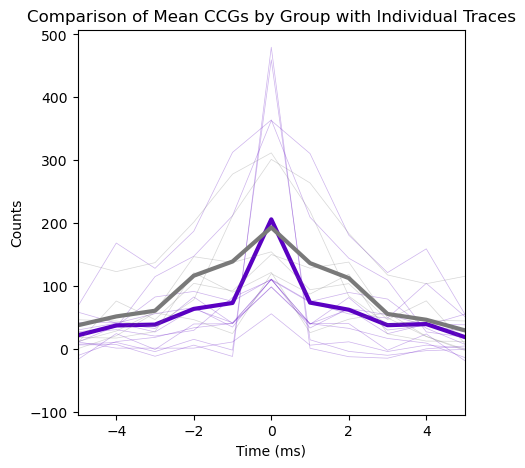

In [380]:
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response='responsive', layers=None, min_spike_pairs=500, xlim=(-5,5), front_group='No_CTZ', limit=True)


In [ ]:
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-50,50), front_group='No_CTZ', threshold=True)
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=50, xlim=(-50,50))
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=True, EorI=None, connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-50,50))
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=True, EorI=None, connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=50, xlim=(-50,50))

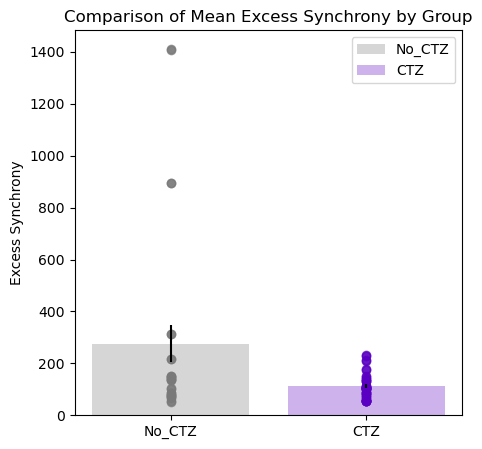

In [557]:
CrossCorrObj.plot_group_excess_synchrony_with_dots(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, limit=True, directory='/Volumes/MannySSD/figures', file_name='RS_excess_synchrony_dots')

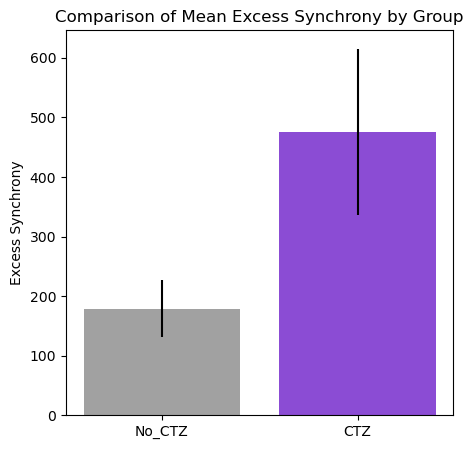

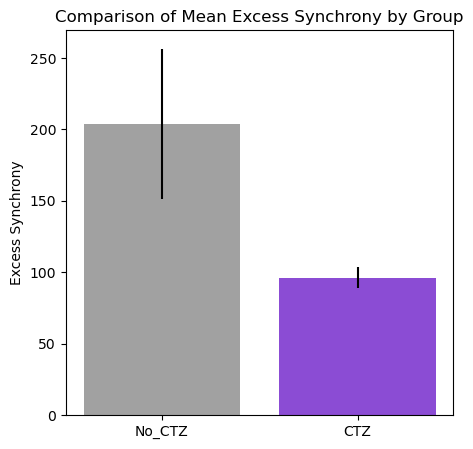

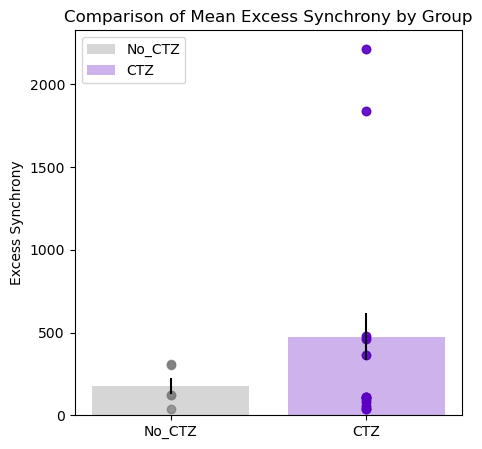

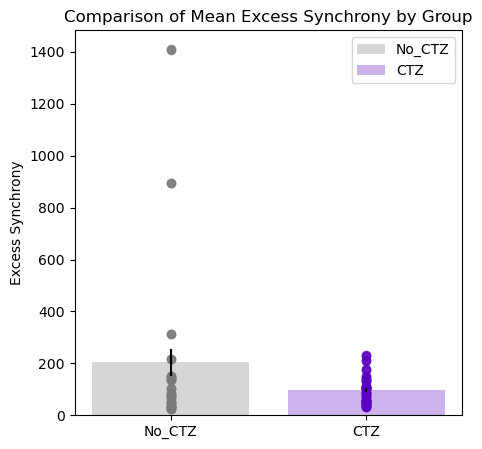

In [558]:
CrossCorrObj.plot_group_excess_synchrony(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, limit=None, directory='/Volumes/MannySSD/figures', file_name='FS_excess_synchrony')
CrossCorrObj.plot_group_excess_synchrony(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, limit=None,directory='/Volumes/MannySSD/figures', file_name='RS_excess_synchrony')
CrossCorrObj.plot_group_excess_synchrony_with_dots(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, limit=None, directory='/Volumes/MannySSD/figures', file_name='FS_excess_synchrony_dots')
CrossCorrObj.plot_group_excess_synchrony_with_dots(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, limit=None, directory='/Volumes/MannySSD/figures', file_name='RS_excess_synchrony_dots')

In [228]:
FSFS_CTZ_synchdf = CrossCorrObj.access_ccgs('CTZ', significance=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000)
FSFS_NoCTZ_synchdf = CrossCorrObj.access_ccgs('No_CTZ', significance=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000)
RSRS_CTZ_synchdf = CrossCorrObj.access_ccgs('CTZ', significance=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000)
RSRS_NoCTZ_synchdf = CrossCorrObj.access_ccgs('No_CTZ', significance=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000)

In [230]:
RSRS_NoCTZ_synchdf = CrossCorrObj.access_ccgs('No_CTZ', significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response='responsive', layers=None, min_spike_pairs=2000)
RSRS_NoCTZ_synchdf


,CellTypes,DCW,EorI,ExcessSynchrony,N_SpikePairs,Significance,StimResp_A,StimResp_B,UnitA,UnitB,group,layers,recording,groupname,ccgs,sd_sig
2984,RS->RS,221.03970459221395,S,41.566973887741305,44288.0,True,1,0,cid17,cid23,No_CTZ,IG->L4,veh_2835,No_CTZ,"[10.162295916535946, -0.6003158002701596, 3.11...",True
2985,RS->RS,-186.7547606025356,S,151.54494101644704,98758.0,True,1,0,cid17,cid37,No_CTZ,IG->L4,veh_2835,No_CTZ,"[-2.886781527415259, -8.118668407786213, 1.516...",True
3046,RS->RS,-329.87489635282463,S,48.531317714882135,15526.0,True,1,0,cid35,cid95,No_CTZ,IG->IG,veh_2836_1,No_CTZ,"[-2.839341711279846, -2.7250776674975805, -3.0...",True
3111,RS->RS,-85.43789269612267,S,53.0752122176736,39718.0,True,1,1,cid72,cid184,No_CTZ,L4->IG,veh_2836_2,No_CTZ,"[-5.493844318803731, -1.5243011467857581, 2.68...",True
3301,RS->RS,-57.40784199200158,S,52.402963283145986,39718.0,True,1,1,cid184,cid72,No_CTZ,IG->L4,veh_2836_2,No_CTZ,"[-4.2136601668520655, 4.398527654568989, -4.40...",True
3531,RS->RS,74.28982089665448,S,34.88276483444975,4016.0,True,1,1,cid129,cid157,No_CTZ,IG->IG,veh_3062_3,No_CTZ,"[-1.4402746639317534, -1.3913704198450902, -1....",True
3566,RS->RS,-136.21401532689495,S,35.35464152700358,4016.0,True,1,1,cid157,cid129,No_CTZ,IG->IG,veh_3062_3,No_CTZ,"[-0.9397758380634421, -1.0578528204665094, -0....",True
3577,RS->RS,35.98466355119555,S,25.384419437806603,3034.0,True,1,0,cid159,cid140,No_CTZ,L4->IG,veh_3062_3,No_CTZ,"[-0.7626919569108705, -0.8681422771034462, -0....",True
3731,RS->RS,-31.71327236205005,S,32.61229365399707,12856.0,True,1,0,cid279,cid376,No_CTZ,L4->IG,veh_3141_2,No_CTZ,"[-2.389321407713681, 2.0437328779035937, 1.908...",True
3732,RS->RS,28.79215438894765,S,77.7367117225345,22202.0,True,1,1,cid279,cid384,No_CTZ,L4->IG,veh_3141_2,No_CTZ,"[-1.8971192006137816, -3.5544056661888206, -6....",True


In [559]:
# Perform the permutation test
results_perm = CrossCorrObj.compare_group_excess_synchrony_permutation(
    significance=None,
    sd_sig=True,
    EorI=['S'],
    connectiontype='RS->RS',
    response=None,
    layers=None,
    min_spike_pairs=1000,
    num_permutations=10000, 
    limit=None
)

No_CTZ Summary Statistics:
count      40.000000
mean      203.751752
std       338.069426
min        24.660601
25%        45.512047
50%        81.735725
75%       149.027752
max      1412.422032
dtype: float64

CTZ Summary Statistics:
count     52.000000
mean      96.196378
std       52.459908
min       30.603071
25%       53.497201
50%       87.935742
75%      116.070249
max      233.137051
dtype: float64

Permutation Test Results:
Observed Difference: 107.5553738019481
P-Value: 0.0176


In [561]:
# Perform the permutation test with quartile filtering
results_perm_quartile = CrossCorrObj.compare_group_excess_synchrony_permutation_quartile(
    significance=None,
    sd_sig=True,
    EorI=['S'],
    connectiontype='RS->RS',
    response=None,
    layers=None,
    min_spike_pairs=1000,
    num_permutations=10000,
    quartile=None, 
    limit=None
)

No_CTZ Summary Statistics:
count      40.000000
mean      203.751752
std       338.069426
min        24.660601
25%        45.512047
50%        81.735725
75%       149.027752
max      1412.422032
Name: ExcessSynchrony, dtype: float64

CTZ Summary Statistics:
count     52.000000
mean      96.196378
std       52.459908
min       30.603071
25%       53.497201
50%       87.935742
75%      116.070249
max      233.137051
Name: ExcessSynchrony, dtype: float64

Permutation Test Results:
Observed Difference: 107.5553738019481
P-Value: 0.0166


In [564]:
# Perform the permutation test with quartile filtering
results_perm_quartile = CrossCorrObj.compare_group_excess_synchrony_permutation_quartile(
    significance=None,
    sd_sig=True,
    EorI=['S'],
    connectiontype='FS->FS',
    response=None,
    layers=None,
    min_spike_pairs=1000,
    num_permutations=10000,
    quartile=None, 
    limit=None
)


No_CTZ Summary Statistics:
count      5.000000
mean     178.991304
std      121.111731
min       40.132320
25%      119.897759
50%      121.733891
75%      301.406240
max      311.786308
Name: ExcessSynchrony, dtype: float64

CTZ Summary Statistics:
count      25.000000
mean      475.902279
std       711.877376
min        39.506305
25%        80.820520
50%       110.546153
75%       459.692331
max      2216.542879
Name: ExcessSynchrony, dtype: float64

Permutation Test Results:
Observed Difference: -296.9109757302916
P-Value: 0.3795


In [234]:
RSRS_CTZ_synchdf = CrossCorrObj.access_ccgs('CTZ', significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=50)
RSRS_NoCTZ_synchdf = CrossCorrObj.access_ccgs('No_CTZ', significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=50)

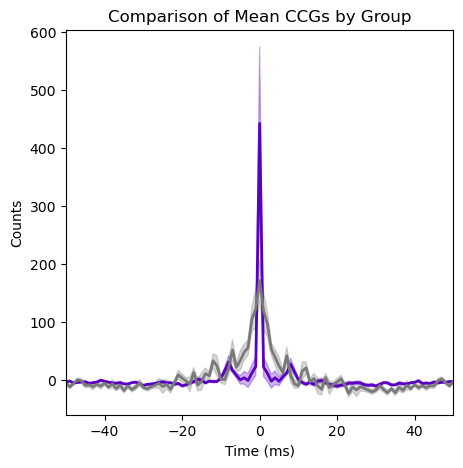

In [241]:
CrossCorrObj.plot_group_ccgs(significance=False, sd_sig=False, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-50,50), front_group='No_CTZ', directory='/Volumes/MannySSD/figures', file_name='ccg_plot_fs_fs')


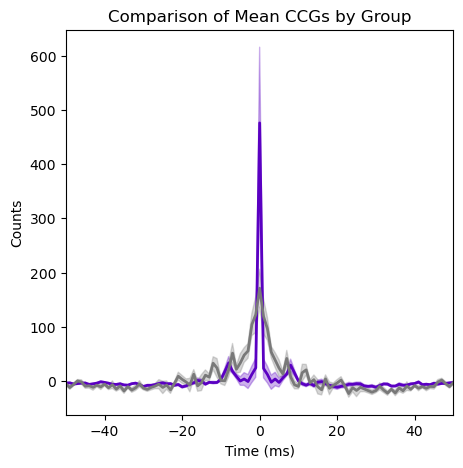

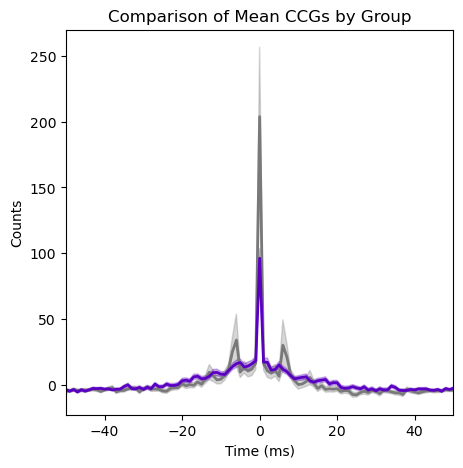

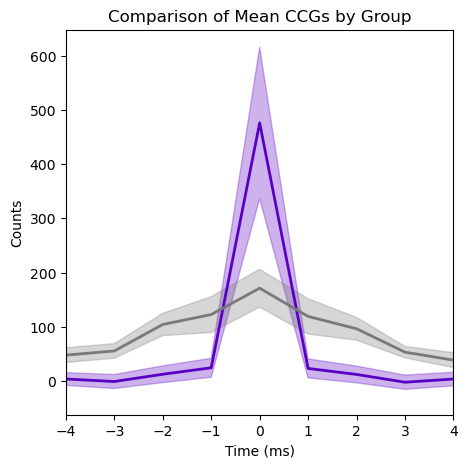

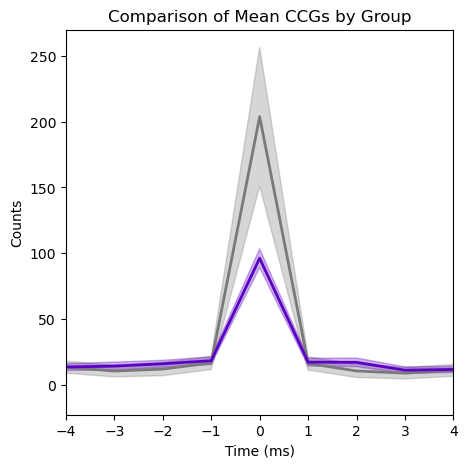

In [236]:
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-50,50), front_group='No_CTZ', directory='/Volumes/MannySSD/figures', file_name='ccg_plot_fs_fs')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000,xlim=(-50,50), directory='/Volumes/MannySSD/figures', file_name='ccg_plot_rs_rs')

CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-4,4), front_group='No_CTZ', directory='/Volumes/MannySSD/figures', file_name='ccg_plot_fs_fs_zoom')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-4,4), directory='/Volumes/MannySSD/figures', file_name='ccg_plot_rs_rs_zoom')

In [ ]:
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=5000, xlim=(-50,50), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=5000, xlim=(-50,50))
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=5000, xlim=(-50,50), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=5000,xlim=(-50,50))
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=None, connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=5000, xlim=(-100,100), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=None, connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=5000, xlim=(-100,100), front_group='CTZ')

FileNotFoundError: [Errno 2] No such file or directory: ''

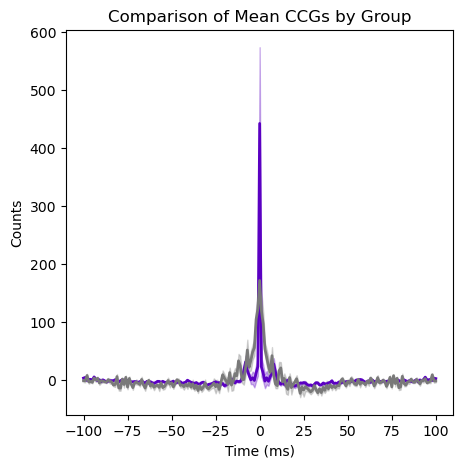

In [243]:
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=None, front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=None)
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30))

CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-6,6), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-6,6))

CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=1, layers=None, min_spike_pairs=50, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=1, layers=None, min_spike_pairs=1000, xlim=(-30,30))

CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-8,8), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-8,8))


CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=None, connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=None, connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30))

CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=None, connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-8,8), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=None, connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-8,8))


In [ ]:
CrossCorrObj.plot_group_ccgs(significance=False, sd_sig=True, EorI=['E'], connectiontype='RS->RS', response='responsive', layers=None, min_spike_pairs=1000, xlim=(-30,30), directory=None, file_name=None)


In [ ]:
CrossCorrObj.plot_group_ccgs_traces(significance=False, sd_sig=True, EorI=['E'], connectiontype='RS->RS', response='responsive', layers=None, min_spike_pairs=1000, xlim=(-30,30))

FileNotFoundError: [Errno 2] No such file or directory: ''

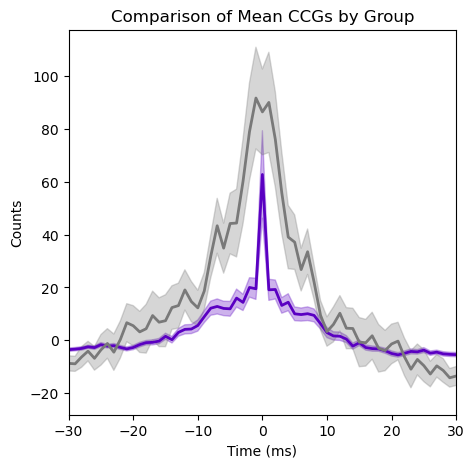

In [244]:



CrossCorrObj.plot_group_ccgs(significance=None, EorI=None, connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, EorI=None, connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30))

CrossCorrObj.plot_group_ccgs(significance=None, EorI=['E'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, EorI=['I'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=50, xlim=(-30,30))

CrossCorrObj.plot_group_ccgs(significance=None, EorI=['I'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=50, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, EorI=['E'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=50, xlim=(-30,30))




In [ ]:
CrossCorrObj.access_ccgs('No_CTZ', significance=False, EorI=['NS', 'E'], connectiontype='FS->FS') #accesses CCGs from 'MonoConnectionsTable' based on specified criteria

In [ ]:
CrossCorrObj.eed.group_names # the names of the groups in the eed object
CrossCorrObj.eed.recording_names # the names of the recordings in the eed object for the group

# Whisker dataframe initializer Starts Here

### intialize whisker df manager

In [668]:
whisker_df_manager = DataFrameManager(whisker)

whisker_df_manager.create_dataframe(['Cell_Type', 'IsSingleUnit', 'StimResponsivity', 'MeanFR_baseline', 'MeanFR_stim','LaminarLabel', 'PeakEvokedFR', 'PeakEvokedFR_Latency', 'FanoFactor_baseline', 'FanoFactor_stim', 'SpikeTimes_all', 'MeanFR_inst_stim', 'Template_Channel', 'ModulationIndex', 'Normalized_Template_Waveform', 'TroughToPeak_duration' ], 'basic_metrics')
#whisker_df_manager.create_psth_dataframe_2(modulation_type='positive')

whisker_df_manager.create_psth_dataframe()

### plotting box plots for evoked firing rates 

### SUA plotting, Stim response

In [ ]:

whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10, 50), cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, smoothing_window=10)
whisker_df_manager.prepare_for_boxplot()
boxplot_FS= whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_FS_baseline_stim')

whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10, 50), cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, smoothing_window=10)
whisker_df_manager.prepare_for_boxplot()
boxplot_RS = whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_RS_baseline_stim')

### MUA only not SUA, is responsive

In [ ]:
whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10, 50), cell_type='FS', is_single_unit=0.0, stim_responsivity=1.0, smoothing_window=10)
whisker_df_manager.prepare_for_boxplot()
boxplot_FS= whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_FS_baseline_stim2')

whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10, 50), cell_type='RS', is_single_unit=0.0, stim_responsivity=1.0, smoothing_window=10)
whisker_df_manager.prepare_for_boxplot()
boxplot_RS = whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_RS_baseline_stim2')

### MUA and SUA combined

In [ ]:
whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10, 50), cell_type='FS', is_single_unit=None, stim_responsivity=1.0, smoothing_window=10)
whisker_df_manager.prepare_for_boxplot()
boxplot_FS= whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_FS_baseline_stim2')

whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10, 50), cell_type='RS', is_single_unit=None, stim_responsivity=1.0, smoothing_window=10)
whisker_df_manager.prepare_for_boxplot()
boxplot_RS = whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_RS_baseline_stim2')

### plot and anlysis bases on location of unit on probe 

In [ ]:
whisker_df_manager.create_dataframe(['Cell_Type', 'IsSingleUnit', 'StimResponsivity', 'MeanFR_baseline', 'MeanFR_stim','LaminarLabel', 'PeakEvokedFR', 'PeakEvokedFR_Latency', 'FanoFactor_baseline', 'FanoFactor_stim', 'SpikeTimes_all', 'MeanFR_inst_stim', 'Template_Channel', 'ModulationIndex'], 'basic_metrics')
whisker_df_manager.create_psth_dataframe()


whisker_df_manager.plot_modulation_index(
     df_name='basic_metrics',
     group_name='CTZ', 
     is_single_unit=None, 
     cell_type='FS', 
     stim_responsivity=None
) 

whisker_df_manager.plot_modulation_index(
     df_name='basic_metrics',
     group_name='No_CTZ', 
     is_single_unit=None, 
     cell_type='FS', 
     stim_responsivity=None
)


In [ ]:
whisker_df_manager.plot_modulation_index_density(
     df_name='basic_metrics', 
     is_single_unit=None, 
     cell_type='FS', 
     stim_responsivity=None, 
     modulation_type='positive'
)

### more whisker evoked PSTHS and visdualize the mean PSTH per recording easily 

In [ ]:
boxplot_FS
boxplot_FS.to_csv('/Volumes/MannySSD/mean_stimulation_data_FS.csv', index=False)

boxplot_RS 
boxplot_RS.to_csv('/Volumes/MannySSD/mean_stimulation_data_RS.csv', index=False)



In [ ]:
#loop through the stim using self.eed.TrialTagsLabels['trialTagsLabels']
for stim in ['Zero', 'Low', 'Mid', 'Max']:
    whisker_df_manager.plot_psth_comparison_grouprecordings('CTZ', 'No_CTZ', stim, cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50, 50), plot_mode='sem', smoothing_window=10, group_by_recordings=True)

In [159]:
ctz_df1, noctz_df2 = whisker_df_manager.compare_groups('CTZ', 'No_CTZ', 'Max', 'RS', is_single_unit=1.0, stim_responsivity=1.0)

def process_data(df, time_range):
    
    time_array = whisker_df_manager.eed.relative_time_ms['relative_time_ms']
    
    if time_range:
        time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
        time_array = time_array[time_mask]
    else:
        time_mask = slice(None)
    
    grouped = df.groupby('recordingname')
    grouped_data = grouped['PSTHs_raw'].apply(lambda x: np.mean([np.array(i)[time_mask] for i in x], axis=0))
    
    return grouped_data

ctz_df1_grouped = process_data(ctz_df1, time_range=(-10, 600))
noctz_df2_grouped = process_data(noctz_df2, time_range=(-10, 600))

Query for group1: (groupname == 'CTZ') & (Cell_Type == 'RS') & (IsSingleUnit == 1.0) & (StimResponsivity == 1.0)
Filtered df1: (9, 11)
Query for group2: (groupname == 'No_CTZ') & (Cell_Type == 'RS') & (IsSingleUnit == 1.0) & (StimResponsivity == 1.0)
Filtered df2: (19, 11)


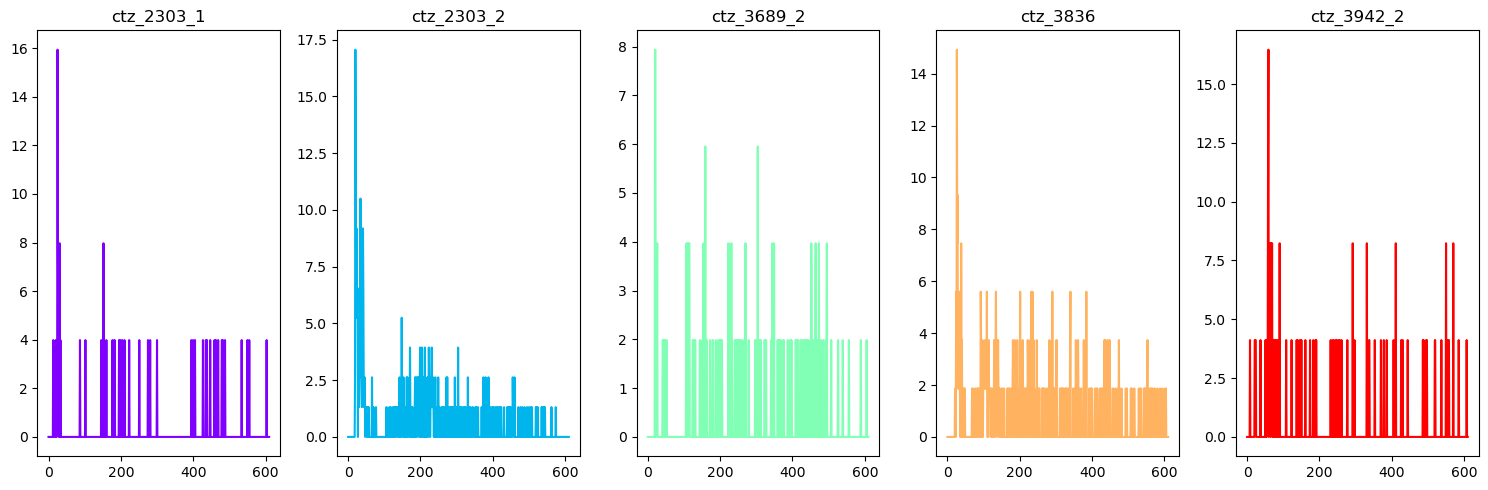

In [160]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Create a color map
colors = cm.rainbow(np.linspace(0, 1, len(ctz_df1_grouped)))

# Create a 1xN subplot
fig, axs = plt.subplots(1, len(ctz_df1_grouped), figsize=(15, 5))

# Iterate over the grouped data
for ax, data, color, name in zip(axs, ctz_df1_grouped, colors, ctz_df1_grouped.index):
    ax.plot(data, color=color)
    ax.set_title(name)

# Show the plot
plt.tight_layout()
plt.show()



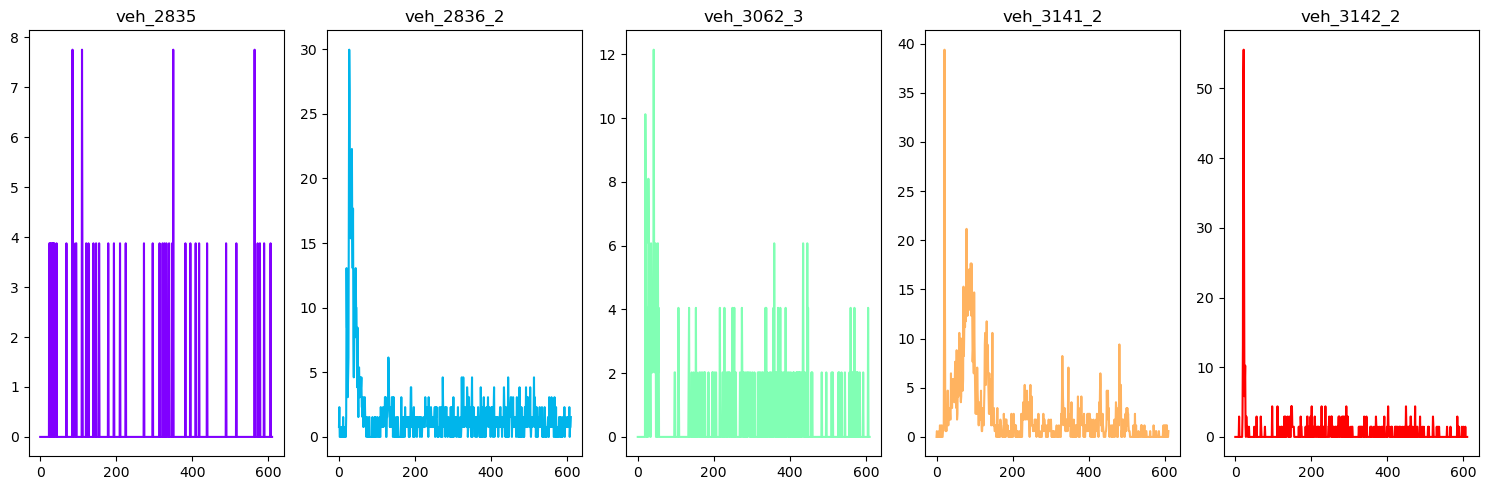

In [161]:
# Create a color map
colors = cm.rainbow(np.linspace(0, 1, len(noctz_df2_grouped)))

# Create a 1xN subplot
fig, axs = plt.subplots(1, len(noctz_df2_grouped), figsize=(15, 5))

# Iterate over the grouped data
for ax, data, color, name in zip(axs, noctz_df2_grouped, colors, noctz_df2_grouped.index):
    ax.plot(data, color=color)
    ax.set_title(name)

# Show the plot
plt.tight_layout()
plt.show()

### more whisker rbp4 plotting and data manager creatr

In [ ]:
rbp4_whisker_df_manager = DataFrameManager(rbp4_whisker)
rbp4_whisker_df_manager.eed
rbp4_whisker_df_manager.create_dataframe(['Cell_Type', 'IsSingleUnit', 'StimResponsivity', 'MeanFR_baseline', 'MeanFR_stim','LaminarLabel', 'PeakEvokedFR', 'PeakEvokedFR_Latency', 'FanoFactor_baseline', 'FanoFactor_stim', 'SpikeTimes_all', 'MeanFR_inst_stim' ], 'basic_metrics')


In [ ]:
rbp4_whisker_df_manager.create_psth_dataframe()
rbp4_whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10,50), cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, smoothing_window=5)
rbp4_whisker_df_manager.prepare_for_boxplot()
rbp4_whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=['Low'], show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_RS_baseline_stim_rbp4')

In [ ]:
rbp4_whisker_df_manager.create_psth_dataframe()
rbp4_whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10,50), cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, smoothing_window=5)
rbp4_whisker_df_manager.prepare_for_boxplot()
rbp4_whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_FS_baseline_stim_rbp4')

rbp4_whisker_df_manager.create_psth_dataframe()
rbp4_whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10,50), cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, smoothing_window=5)
rbp4_whisker_df_manager.prepare_for_boxplot()
rbp4_whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_RS_baseline_stim_rbp4')

rbp4_whisker_df_manager.create_psth_dataframe()
rbp4_whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(10,50), cell_type=None, is_single_unit=None, stim_responsivity=0.0, smoothing_window=5)
rbp4_whisker_df_manager.prepare_for_boxplot()
rbp4_whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_MUA_baseline_stim_rbp4')

### trying to reannalyze PSTH based on modulation index values 

In [ ]:
# Add the ModulationLabel column to the DataFrame
whisker_df_manager.add_modulation_label_column('basic_metrics')

In [47]:
# Save the filtered DataFrame to retain only positive modulation entries
whisker_df_manager.save_filtered_dataframe('basic_metrics', 'positive')
whisker_df_manager.dataframes['basic_metrics']


ModulationLabel column not found in the DataFrame.
Filtered DataFrame was not saved.


,groupname,recordingname,cid,Cell_Type,IsSingleUnit,StimResponsivity,MeanFR_baseline,MeanFR_stim,LaminarLabel,PeakEvokedFR,PeakEvokedFR_Latency,FanoFactor_baseline,FanoFactor_stim,SpikeTimes_all,MeanFR_inst_stim,Template_Channel,ModulationIndex
0,CTZ,ctz_2303_1,cid172,RS,1.0,0.0,0.014028056112224449,"[0.0, 0.2133196808737574, 0.0, 0.3977434687207...",IG,"[0.0, 0.5685427621596706, 0.9958610277891513, ...","[0.0, 19.0, 20.0, 18.0]",0.9999999999999979,"[0.0, 1.0000000000000024, 0.9962962962962968, ...","[264317.0, 264482.0, 900036.0, 909621.0, 90999...","[0.0, 0.20350020350020354, 0.3514320857494289,...",17.0,0.9294743356023306
1,CTZ,ctz_2303_1,cid204,FS,0.0,0.0,0.18637274549098196,"[0.0, 0.0, 0.9209742679789527, 0.5966152030811...",SG,"[0.006107148185710053, 0.0, 2.2790817575866322...","[20.0, 0.0, 10.0, 11.0]",0.9997707407938078,"[0.0, 0.0, 0.9944444444444441, 0.9999999999999...","[264955.0, 921481.0, 1802538.0, 4757215.0, 490...","[0.0, 0.0, 1.0542962572482866, 0.5691519635742...",18.0,0.5149707024371505
2,CTZ,ctz_2303_1,cid225,RS,1.0,0.0,0.03206412825651302,"[0.20626779059693898, 0.2133196808737574, 0.18...",SG,"[0.5497479601048054, 1.229524610184705, 0.4909...","[9.0, 20.0, 19.0, 10.0]",0.9999999999999996,"[1.0000000000000018, 1.0000000000000004, 1.000...","[23044347.0, 45721976.0, 60923841.0, 76824870....","[0.19677292404565133, 0.20350020350020354, 0.1...",31.0,0.7089182918996002
3,CTZ,ctz_2303_1,cid251,RS,0.0,1.0,0.16432865731462926,"[0.0, 0.2133196808737574, 2.762922803936858, 4...",L4,"[0.0, 0.5685427621596706, 4.828492567143039, 9...","[0.0, 17.0, 13.0, 12.0]",0.9996066631266316,"[0.0, 1.000000000000001, 0.9938624338624343, 0...","[3504920.0, 3889642.0, 3938647.0, 4635830.0, 4...","[0.0, 0.20350020350020354, 2.635740643120717, ...",3.0,0.9318518939139749
4,CTZ,ctz_2303_1,cid296,FS,0.0,1.0,0.9018036072144289,"[0.41253558119387795, 4.479713298348906, 6.078...",L4,"[0.5715589340761942, 13.818260355851601, 36.63...","[3.0, 20.0, 20.0, 20.0]",0.9987227870662342,"[1.0000000000000007, 0.9892053583040703, 0.965...","[1222076.0, 5556801.0, 5635707.0, 5671808.0, 8...","[0.39354584809130266, 4.477004477004478, 8.082...",29.0,0.8160230321917847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,No_CTZ,veh_3142_2,cid702,RS,0.0,0.0,0.083248730964467,"[0.0, 0.19347598962968696, 0.0, 0.0]",SG,"[0.0, 0.5156550633541197, 0.0, 0.0]","[0.0, 3.0, 0.0, 0.0]",1.000000000000002,"[0.0, 0.9999999999999998, 0.0, 0.0]","[5387612.0, 30272119.0, 32181690.0, 36392905.0...","[0.0, 0.18456995201181248, 0.0, 0.0]",14.0,-1.0
290,No_CTZ,veh_3143_1,cid135,FS,1.0,1.0,0.1941941941941942,"[0.0, 2.1789081689248078, 6.539319474819986, 9...",IG,"[0.005818621499770995, 4.226664060672606, 13.7...","[20.0, 15.0, 12.0, 12.0]",0.9994297538165785,"[0.0, 0.9956175298804779, 0.970822980197274, 0...","[119431.0, 142541.0, 332476.0, 348113.0, 34847...","[0.0, 2.2675736961451243, 7.693907257226034, 9...",6.0,0.9616747943775739
291,No_CTZ,veh_3143_1,cid164,RS,0.0,0.0,0.34234234234234234,"[0.39304571121621446, 0.0, 0.4359546316546658,...",IG,"[0.6353719392611511, 0.0, 1.346660411497977, 0.0]","[17.0, 0.0, 0.0, 0.0]",0.999423626013092,"[0.9999999999999993, 0.0, 0.9999999999999989, ...","[7765360.0, 7913719.0, 9069832.0, 11251778.0, ...","[0.562429696287964, 0.0, 0.4158868787689748, 0.0]",12.0,-1.0
292,No_CTZ,veh_3143_1,cid179,FS,0.0,0.0,0.014014014014014014,"[0.0, 0.0, 0.0, 0.0]",IG,"[0.0, 0.0, 1.1072868335602215, 0.0]","[0.0, 0.0, 20.0, 0.0]",1.0000000000000013,"[0.0, 0.0, 0.0, 0.0]","[2151587.0, 2466001.0, 2469288.0, 5731178.0, 9...","[0.0, 0.0, 0.0, 0.0]",13.0,-1.0


#### Plot PSTHs based on modulation index, per group as mean, traces, or per recordings, using the older PSTHs

Plotting PSTH for groups: CTZ, No_CTZ with stimulation: Low
Query for group1: (groupname == 'CTZ') & (Cell_Type == 'FS') & (IsSingleUnit == 1.0)
Filtered df1: (19, 10)
Query for group2: (groupname == 'No_CTZ') & (Cell_Type == 'FS') & (IsSingleUnit == 1.0)
Filtered df2: (8, 10)


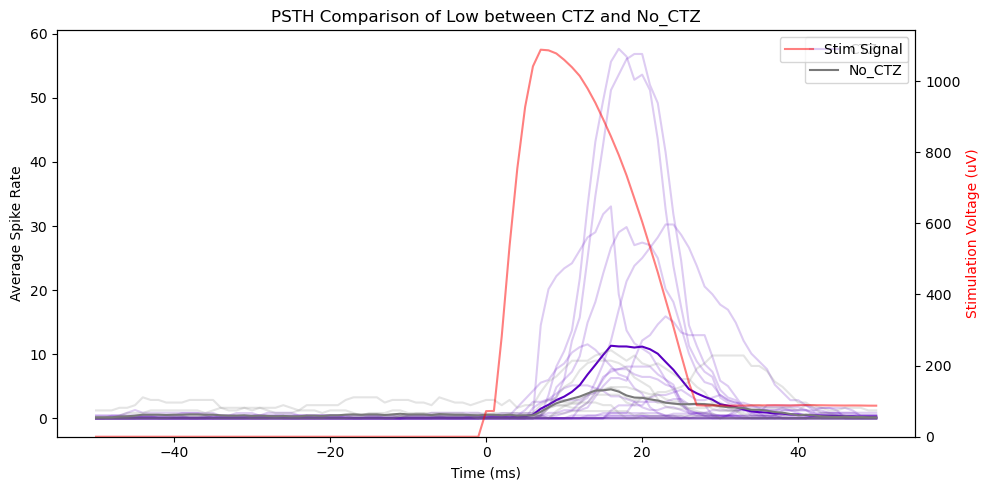

,-50.0,-49.0,-48.0,-47.0,-46.0,-45.0,-44.0,-43.0,-42.0,-41.0,...,46.0,47.0,48.0,49.0,50.0,Group,Stimulation,Cell_Type,IsSingleUnit,StimResponsivity
0,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,CTZ,Low,FS,1.0,None
1,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,CTZ,Low,FS,1.0,None
2,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.854701,0.854701,0.854701,0.854701,0.854701,CTZ,Low,FS,1.0,None
3,0.42735,0.42735,0.427350,0.427350,0.854701,1.282051,0.854701,0.854701,0.854701,0.854701,...,0.000000,0.000000,0.000000,0.000000,0.000000,CTZ,Low,FS,1.0,None
4,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.403226,0.403226,0.000000,0.000000,0.000000,CTZ,Low,FS,1.0,None
5,0.00000,0.00000,0.403226,0.403226,0.403226,0.403226,0.403226,0.403226,0.403226,0.403226,...,1.612903,1.209677,0.403226,0.403226,0.403226,CTZ,Low,FS,1.0,None
6,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.403226,0.403226,0.403226,0.403226,...,0.000000,0.000000,0.000000,0.000000,0.000000,CTZ,Low,FS,1.0,None
7,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,CTZ,Low,FS,1.0,None
8,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.403226,0.403226,0.403226,0.403226,0.403226,CTZ,Low,FS,1.0,None
9,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.403226,0.403226,0.403226,0.403226,0.403226,CTZ,Low,FS,1.0,None


In [118]:
whisker_df_manager.plot_psth_with_stim('CTZ', 'No_CTZ', stim_label='Low', cell_type='FS', is_single_unit=1.0, stim_responsivity=None, time_range=(-50, 50), plot_mode='traces', smoothing_window=10)


In [189]:
## add the modulation index to the dataframe psth_dataframe
whisker_df_manager.add_modulation_label_column('psth_dataframe')
whisker_df_manager.add_modulation_label_column('psth_dataframe_Zero')
whisker_df_manager.add_modulation_label_column('psth_dataframe_Low')
whisker_df_manager.add_modulation_label_column('psth_dataframe_Mid')
whisker_df_manager.add_modulation_label_column('psth_dataframe_Max')

Added ModulationLabel column to 'psth_dataframe' DataFrame.
Added ModulationLabel column to 'psth_dataframe_Zero' DataFrame.
Added ModulationLabel column to 'psth_dataframe_Low' DataFrame.
Added ModulationLabel column to 'psth_dataframe_Mid' DataFrame.
Added ModulationLabel column to 'psth_dataframe_Max' DataFrame.


,groupname,recordingname,cid,Cell_Type,LaminarLabel,IsSingleUnit,StimResponsivity,SpikeTrains_for_PSTHs,PSTHs_raw,ModulationIndex,ModulationLabel
0,CTZ,ctz_2303_1,cid172,RS,IG,1.0,0.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9294743356023306,positive
1,CTZ,ctz_2303_1,cid204,FS,SG,0.0,0.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.5149707024371505,positive
2,CTZ,ctz_2303_1,cid225,RS,SG,1.0,0.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.7089182918996002,positive
3,CTZ,ctz_2303_1,cid251,RS,L4,0.0,1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 3.9840637450199203, 0.0, 0.0, 0.0, 0.0, ...",0.9318518939139749,positive
4,CTZ,ctz_2303_1,cid296,FS,L4,0.0,1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 3.9840637450199203, 0.0, 0.0, 0.0, 3.984...",0.8160230321917847,positive
...,...,...,...,...,...,...,...,...,...,...,...
289,No_CTZ,veh_3142_2,cid702,RS,SG,0.0,0.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-1.0,negative
290,No_CTZ,veh_3143_1,cid135,FS,IG,1.0,1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9616747943775739,positive
291,No_CTZ,veh_3143_1,cid164,RS,IG,0.0,0.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 3.787878787878788, 0.0, 0.0, 3.787878787...",-1.0,negative
292,No_CTZ,veh_3143_1,cid179,FS,IG,0.0,0.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-1.0,negative


In [205]:
#what are the unique recording names for CTZ only
whisker_df_manager.dataframes['psth_dataframe']

#print the unique recording names for the CTZ group
whisker_df_manager.dataframes['psth_dataframe'].groupby('groupname')['recordingname'].unique()[1]

/var/folders/pm/pt74stnd1pn98pmc9gmv1wj80000gn/T/ipykernel_67076/2642917109.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whisker_df_manager.dataframes['psth_dataframe'].groupby('groupname')['recordingname'].unique()[1]


array(['veh_2835', 'veh_2836_1', 'veh_2836_2', 'veh_3062_1', 'veh_3062_2',
       'veh_3062_3', 'veh_3141_1', 'veh_3141_2', 'veh_3142_1',
       'veh_3142_2', 'veh_3143_1'], dtype=object)

In [ ]:
list_of_ctz_recs = ['ctz_2303_1', 'ctz_2303_2', 'ctz_2874_1', 'ctz_2874_2', 'ctz_3689','ctz_3689_2', 'ctz_3835', 'ctz_3836', 'ctz_3942_1', 'ctz_3942_2','ctz_3960', 'ctz_alt1']
list_of_veh_recs = ['veh_2835', 'veh_2836_1', 'veh_2836_2', 'veh_3062_1', 'veh_3062_2',
       'veh_3062_3', 'veh_3141_1', 'veh_3141_2', 'veh_3142_1',
       'veh_3142_2', 'veh_3143_1']

for veh in list_of_veh_recs:
       for ctz in list_of_ctz_recs:
              whisker_df_manager
              whisker_df_manager.plot_group_comparison_1v1(['Zero', 'Low', 'Mid', 'Max'], groupnames=['CTZ', 'No_CTZ'], cell_type='RS', is_single_unit=None, stim_responsivity=None, modulation_label=None,time_range=(-100,600), smoothing_window=10, recordingnames = [ctz, veh])
              #save the figure dynamically as a svg dynamically in the figures folder 
              plt.savefig(f'/Volumes/MannySSD/figures/rs_example_nnn/{ctz}_{veh}_comparison.svg') 
              plt.close()
              

In [ ]:
whisker_df_manager.plot_group_comparison_meansem(['Zero', 'Low', 'Mid', 'Max'], cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, groupnames=['CTZ', 'No_CTZ'], modulation_label='positive', time_range=[-100, 600], smoothing_window=25)
whisker_df_manager.plot_group_comparison(['Zero', 'Low', 'Mid', 'Max'], cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, groupnames=['CTZ', 'No_CTZ'], modulation_label='positive', time_range=[-100, 600], smoothing_window=25)
whisker_df_manager.plot_group_comparison(['Zero', 'Low', 'Mid', 'Max'], cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, groupnames=['CTZ', 'No_CTZ'], modulation_label='positive', time_range=[-100, 600], smoothing_window=25, ylim=(0, 15))



whisker_df_manager.plot_group_comparison_meansem(['Zero', 'Low', 'Mid', 'Max'], cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, groupnames=['CTZ', 'No_CTZ'], modulation_label='positive', time_range=[-100, 600], smoothing_window=25)
whisker_df_manager.plot_group_comparison(['Zero', 'Low', 'Mid', 'Max'], cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, groupnames=['CTZ', 'No_CTZ'], modulation_label='positive', time_range=[-100, 600], smoothing_window=25)


In [ ]:
whisker_df_manager.dataframes['psth_dataframe_Low'].head()

In [ ]:
whisker_df_manager.dataframes['psth_dataframe_Low']['PSTHs_raw']

In [ ]:
all_traces_df = whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='pos_RS_notsua_noneresponsive_sem_final')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='pos_FS_none_stimulations_sem_final')

#whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=None, time_range=(-100,600), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='pos_RS_notsua_noneresponsive_sem_final_fulltime')
#whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=None, time_range=(-100,600), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='pos_RS_notsua_noneresponsive_traces_final_fulltime')

#whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=None, time_range=(-100,600), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='pos_FS_notsua_noneresponsive_sem_final_fulltime')



### to be sorted into sections 

In [ ]:
whisker_df_manager.eed
whisker_df_manager.create_dataframe(['Cell_Type', 'IsSingleUnit', 'StimResponsivity', 'SpikeTimes_all', 'FirstSpikeLatency', 'FirstSpikeLatency_Reliability', 'ISI_baseline_CV', 'ISI_baseline_vec', 'ISI_pdf_peak_xy', 'ISI_pdf_x', 'ISI_pdf_y'  ], 'temporal_spiking_metrics')


In [ ]:
whisker_df_manager.dataframes['temporal_spiking_metrics'].groupby(['groupname', 'Cell_Type']).size()

In [ ]:
whisker_df_manager.unpack_based_on_stim('temporal_spiking_metrics', 'FirstSpikeLatency', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=1)


In [ ]:
whisker_df_manager.unpack_based_on_stim('temporal_spiking_metrics', 'FirstSpikeLatency', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=None)


In [ ]:
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Max'], show_outliers=True, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency', cell_type_filter='RS', is_single_unit=1.0, stim_responsivity_filter=1, remove_outliers_option=False, directory='/Volumes/MannySSD/figures', file_name='boxplot_RS_FirstSpikeLatency')
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Max'], show_outliers=True, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency_Reliability', cell_type_filter='RS', is_single_unit=1.0, stim_responsivity_filter=1, remove_outliers_option=False, directory='/Volumes/MannySSD/figures', file_name='boxplot_RS_FirstSpikeLatency_Reliability')


In [ ]:
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Max'], show_outliers=True, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_FS_FirstSpikeLatency')
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Max'], show_outliers=True, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency_Reliability', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=False, directory='/Volumes/MannySSD/figures', file_name='boxplot_FS_FirstSpikeLatency_Reliability')



In [ ]:
whisker_df_manager.dataframes['basic_metrics'].shape

In [ ]:
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low'], show_outliers=True, dataframe_key='basic_metrics', list_column='FanoFactor_baseline', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=None, remove_outliers_option=True, directory='/Volumes/MannySSD/figures', file_name='boxplot_FS_FirstSpikeLatency')


In [ ]:
whisker_df_manager.plot_rasters_for_cid('CTZ', 'ctz_2303_1', 'cid296', time_window=None)
whisker_df_manager.plot_combined_psth_and_raster('CTZ', 'ctz_2303_1', 'cid296', time_window=None)
whisker_df_manager.plot_combined_psth_and_raster_normalized('CTZ', 'ctz_2303_1', 'cid296', time_window=(-10,50), smoothing_window=5, normalize=False)

In [ ]:

#whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10,200), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_psth_comparison('CTZ', 'No_CTZ', stim_label='Low', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10, 50),  plot_mode='sem', smoothing_window=None)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10, 50), plot_mode='sem', smoothing_window=5)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10, 50), plot_mode='traces', smoothing_window=5)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10, 50), plot_mode='sem', smoothing_window=5)

In [ ]:
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-40, 40), plot_mode='sem', smoothing_window=5)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-40, 40), plot_mode='traces', smoothing_window=5)

whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=None, stim_responsivity=1.0, time_range=(-40, 40), plot_mode='sem', smoothing_window=5)

In [ ]:
df1, df2 = whisker_df_manager.compare_groups('CTZ', 'No_CTZ', 
                                             stim_label='Max',
                                             cell_type='FS', 
                                             is_single_unit='1.0', 
                                             stim_responsivity='1.0')

df1

In [ ]:
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,50), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,50), plot_mode='traces', smoothing_window=8)

whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,50), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,50), plot_mode='traces', smoothing_window=8)

whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=0.0, time_range=(-10,50), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=1.0, time_range=(-10,100), plot_mode='sem', smoothing_window=8)

whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=1.0, time_range=(-10,100), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=0.0, time_range=(-10,50), plot_mode='sem', smoothing_window=8)

whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type=None, is_single_unit=None, stim_responsivity=1.0, time_range=None, plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type=None, is_single_unit=None, stim_responsivity=0.0, time_range=None, plot_mode='sem', smoothing_window=8)

In [ ]:
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,500), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=0.0, time_range=(-10,500), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=1.0, time_range=(-10,500), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=0.0, time_range=(-10,500), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=None, stim_responsivity=0.0, time_range=(-10,500), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=None, stim_responsivity=None, time_range=(-10,500), plot_mode='sem', smoothing_window=8)

In [ ]:
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=0.0, time_range=(-10,45), plot_mode='sem', smoothing_window=5, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_stimulations_nonresponsivewithin20ms_sem')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=0.0, time_range=(-10,45), plot_mode='sem', smoothing_window=5, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='FS_stimulations_nonresponsivewithin20ms_sem')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,45), plot_mode='sem', smoothing_window=5, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_stimulations_sem')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,45), plot_mode='sem', smoothing_window=5, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='FS_stimulations_sem')



In [ ]:
test = whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=None, time_range=(-50,50), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_notsua_noneresponsive_traces')

In [ ]:
test

THIS IS WHAT WILL BE PLOTTED

In [ ]:
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=None, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_notsua_noneresponsive_sem_final')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=None, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='FS_none_stimulations_sem_final')

whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=None, time_range=(-100,600), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_notsua_noneresponsive_sem_final_fulltime')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=None, time_range=(-100,600), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_notsua_noneresponsive_traces_final_fulltime')

whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=None, time_range=(-100,600), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='FS_notsua_noneresponsive_sem_final_fulltime')




saving plots here of different combinations 

In [ ]:

whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=None, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_notsua_noneresponsive_sem')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=None, time_range=(-50,50), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_notsua_noneresponsive_traces')

whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_issua_noneresponsive_sem')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-50,50), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_issua_noneresponsive_traces')

In [ ]:
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_issua_isresponsive_sem')
#whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50,50), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_issua_isresponsive_traces')

whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=0.0, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_notsua_notresponsive_sem')
#whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=0.0, time_range=(-50,50), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_notsua_notresponsive_traces')

In [ ]:

whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=None, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='FS_none_stimulations_sem')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=None, time_range=(-50,50), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='FS_none_stimulations_traces')

In [ ]:

whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_SUA_respopnsive_stimulations_sem')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50,50), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='RS_SUA_respopnsive_stimulations_traces')

whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50,50), plot_mode='sem', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='FS_SUA_respopnsive_stimulations_sem')
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-50,50), plot_mode='traces', smoothing_window=10, directory='/Users/ecrespo/Desktop/emx_data_20ms/', file_name='FS_SUA_respopnsive_stimulations_traces')



In [ ]:
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=1.0, time_range=(-10,100), plot_mode='sem', smoothing_window=3)


In [ ]:
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10,600), plot_mode='sem', smoothing_window=3)
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10,600), plot_mode='sem', smoothing_window=3)





#now do rbp4 

In [ ]:
rbp4_whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=None, stim_responsivity=None, time_range=(-10,200), plot_mode='sem', smoothing_window=5)
rbp4_whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=None, stim_responsivity=None, time_range=(-10,200), plot_mode='sem', smoothing_window=5)

rbp4_whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=None, stim_responsivity=None, time_range=(-10,50), plot_mode='sem', smoothing_window=5)
rbp4_whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=None, stim_responsivity=None, time_range=(-10,50), plot_mode='sem', smoothing_window=5)

rbp4_whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,600), plot_mode='sem', smoothing_window=8)
rbp4_whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,600), plot_mode='sem', smoothing_window=8)
rbp4_whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=0.0, stim_responsivity=1.0, time_range=(-10,600), plot_mode='sem', smoothing_window=8)
rbp4_whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=0.0, stim_responsivity=1.0, time_range=(-10,600), plot_mode='sem', smoothing_window=8)


In [ ]:
rbp4_whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,100), plot_mode='traces', smoothing_window=3)
rbp4_whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10,100), plot_mode='traces', smoothing_window=3)

In [ ]:
rbp4_whisker_df_manager.create_dataframe(['Cell_Type', 'IsSingleUnit', 'StimResponsivity', 'SpikeTimes_all', 'FirstSpikeLatency', 'FirstSpikeLatency_Reliability', 'ISI_baseline_CV', 'ISI_baseline_vec', 'ISI_pdf_peak_xy', 'ISI_pdf_x', 'ISI_pdf_y'  ], 'temporal_spiking_metrics')

rbp4_whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Mid', 'Max'], show_outliers=False, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency', cell_type_filter='RS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=False)
rbp4_whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Mid', 'Max'], show_outliers=False, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency_Reliability', cell_type_filter='RS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=False)
rbp4_whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Mid', 'Max'], show_outliers=False, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=False)
rbp4_whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Mid', 'Max'], show_outliers=False, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency_Reliability', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=False)

In [ ]:
whisker_df_manager.get_filtered_data('basic_metrics', is_single_unit=None, cell_type=None, stim_responsivity=None).head()

In [ ]:
psth = whisker_df_manager.calculate_psth_data('CTZ', 'ctz_2303_1', 'cid296', time_window=None, normalize=True, filter_empty_trials=False)
#plot the psths for four stimulations in the same a 1x4 subplot of the psth
fig, ax = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (stim, data) in enumerate(psth.items()):
    ax[i].plot(data['time_array'], data['counts'], label=stim)
    ax[i].set_title(stim)
    ax[i].set_xlabel('Time (ms)')
    ax[i].set_ylabel('Spike Rate')

In [ ]:
whisker_df_manager.add_modulation_label_column('basic_metrics')
whisker_df_manager.dataframes['basic_metrics'].head()

In [ ]:
mean_df

In [ ]:
mean_df, detailed_df, _ = whisker_df_manager.calculate_all_psths(is_single_unit=None, cell_type=None, stim_responsivity=None, time_window=(10,500), normalize=True, filter_empty_trials=True)


In [ ]:
def filter_mean_df_by_modulation_label(mean_df, basic_metrics_df):
    """
    Filters mean_df to retain only entries with 'positive' ModulationLabel in basic_metrics_df.
    
    Args:
    mean_df (pd.DataFrame): DataFrame containing mean stimulation data.
    basic_metrics_df (pd.DataFrame): DataFrame containing modulation label and other metrics.
    
    Returns:
    pd.DataFrame: Filtered mean_df with only 'positive' ModulationLabel entries.
    """
    # Merge mean_df with basic_metrics_df on the shared columns
    merged_df = mean_df.merge(basic_metrics_df, how='inner', 
                              left_on=['cid', 'LaminarLabel', 'recordingname', 'Group'], 
                              right_on=['cid', 'LaminarLabel', 'recordingname', 'groupname'])
    
    # Filter to retain only entries where ModulationLabel is 'positive'
    filtered_df = merged_df[merged_df['ModulationLabel'] == 'positive']
    
    # Drop columns from basic_metrics_df that were added during the merge
    filtered_df = filtered_df[mean_df.columns]
    
    return filtered_df

# Example usage
mean_df_filtered = filter_mean_df_by_modulation_label(mean_df, whisker_df_manager.dataframes['basic_metrics'])
mean_df_filtered

In [ ]:
SG_stats_df, _= whisker_df_manager.plot_mean_stimulation_box_and_strip2(mean_df_filtered, groups=['CTZ', 'No_CTZ'], stimulations=['Zero','Max'], remove_outliers_option=False, laminar_labels=['SG'], ylim=None, directory='/Volumes/MannySSD/figures', file_name='mean_stimulations_boxplot_SG_MUA')
L4_stats_df, _= whisker_df_manager.plot_mean_stimulation_box_and_strip2(mean_df_filtered, groups=['CTZ', 'No_CTZ'], stimulations=['Zero','Max'],remove_outliers_option=False, laminar_labels=['L4'], ylim=None, directory='/Volumes/MannySSD/figures', file_name='mean_stimulations_boxplot_L4_MUA')
IG_stats_df, _= whisker_df_manager.plot_mean_stimulation_box_and_strip2(mean_df_filtered, groups=['CTZ', 'No_CTZ'], stimulations=['Zero','Max'],remove_outliers_option=False, laminar_labels=['IG'], ylim=None, directory='/Volumes/MannySSD/figures', file_name='mean_stimulations_boxplot_IG_MUA')

In [ ]:
SG_stats_df

In [ ]:
L4_stats_df

In [ ]:
IG_stats_df

In [ ]:

#### do not delete this cell neeed to work on the code below fopr custom box plot
def run_group_comparisons(df, group_column='Group', value_column='mean_stimulation', stim_column='Stimulation'):
    """
    Performs statistical comparisons between groups for each type of stimulation, checks for normality,
    uses the appropriate non-parametric tests, and includes detailed descriptive statistics.
    """
    results = []

    for stim in df[stim_column].unique():
        sub_df = df[df[stim_column] == stim]
        groups = sub_df[group_column].unique()

        if len(groups) < 2:
            continue  # Skip if not enough groups for comparison

        group_data = [sub_df[sub_df[group_column] == g][value_column].dropna() for g in groups]
        normality_results = [shapiro(data) for data in group_data]
        normality_p_values = [result.pvalue for result in normality_results]

        # Choose the appropriate statistical test based on group count
        if len(groups) == 2:
            stat, p_value = mannwhitneyu(*group_data)
            test_used = 'Mann-Whitney U'
        elif len(groups) > 2:
            stat, p_value = kruskal(*group_data)
            test_used = 'Kruskal-Wallis'
            # Note: If using Kruskal-Wallis, consider post-hoc tests for detailed group comparisons
        else:
            continue

        descriptive_stats = [{
            'mean': data.mean(),
            'SD': data.std(),
            'median': data.median(),
            'range_min': data.min(),
            'range_max': data.max(),
        } for data in group_data]

        result_entry = {
            'Stimulation': stim,
            'Test Used': test_used,
            'Test Statistic': stat,
            'p-value': p_value,
            **{f'N Group{i+1}': len(data) for i, data in enumerate(group_data)},
            **{f'Normality p-value Group{i+1}': p for i, p in enumerate(normality_p_values)},
            **{f'{stat_key} Group{i+1}': stat_val for i, stats in enumerate(descriptive_stats) for stat_key, stat_val in stats.items()}
        }

        results.append(result_entry)

    return pd.DataFrame(results)



# Example usage in your data processing workflow
cleaned_df = whisker_df_manager.remove_outliers_by_stimulation(mean_df)  # Assuming outliers have been removed
stats_results = run_group_comparisons(cleaned_df)

stats_results

In [ ]:


#make the legend match the colors of the boxplot
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Create sample data for two groups and two types of stimulation
data = {
    'Stimulation': np.repeat(['Low', 'Medium', 'High'], 100),  # Three stimulation levels
    'Group': np.tile(np.repeat(['CTZ', 'No_CTZ'], 50), 3),  # Two groups
    'mean_stimulation': np.random.rand(300) + np.repeat([0.5, 1.0, 1.5], 100)  # Staggered base values
}

df = pd.DataFrame(data)

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x='Stimulation', y='mean_stimulation', hue='Group',
                 medianprops={'linewidth': 5},
                 whiskerprops={'linewidth': 5},
                 capprops={'linewidth': 0},
                 #boxplot properties
                 boxprops={'edgecolor': 'k', 'linewidth': 10},
                 showfliers=False,  # Outliers not shown
                 width=0.55)


# Apply color to whiskers and median to the CTZ group at low stimulation
# Set color for lower whisker (Line 0)
ax.lines[0].set_color('#5a00c2')
# Set color for upper whisker (Line 1)
ax.lines[1].set_color('#5a00c2')
# Set color for the horizontal cap of the lower whisker (Line 2)
ax.lines[2].set_color('#5a00c2')
# Set color for the horizontal cap of the upper whisker (Line 3)
ax.lines[3].set_color('#5a00c2')
# Set color for the median line (Line 4)
ax.lines[4].set_color('#5a00c2')

# Apply color to whiskers and median to the No_CTZ group at low stimulation
# Set color for lower whisker (Line 5)
ax.lines[5].set_color('#797979')
# Set color for upper whisker (Line 6)
ax.lines[6].set_color('#797979')
# Set color for the horizontal cap of the lower whisker (Line 7)
ax.lines[7].set_color('#797979')
# Set color for the horizontal cap of the upper whisker (Line 8)
ax.lines[8].set_color('#797979')
# Set color for the median line (Line 9)
ax.lines[9].set_color('#797979')

#apply color to the CTZ group at medium stimulation
# Set color for lower whisker (Line 10)
ax.lines[10].set_color('#5a00c2')
# Set color for upper whisker (Line 11)
ax.lines[11].set_color('#5a00c2')
# Set color for the horizontal cap of the lower whisker (Line 12)
ax.lines[12].set_color('#5a00c2')
# Set color for the horizontal cap of the upper whisker (Line 13)
ax.lines[13].set_color('#5a00c2')
# Set color for the median line (Line 14)
ax.lines[14].set_color('#5a00c2')

#apply color to the No_CTZ group at medium stimulation
# Set color for lower whisker (Line 15)
ax.lines[15].set_color('#797979')
# Set color for upper whisker (Line 16)
ax.lines[16].set_color('#797979')
# Set color for the horizontal cap of the lower whisker (Line 17)
ax.lines[17].set_color('#797979')
# Set color for the horizontal cap of the upper whisker (Line 18)
ax.lines[18].set_color('#797979')
# Set color for the median line (Line 19)
ax.lines[19].set_color('#797979')

#apply color to the CTZ group at high stimulation
# Set color for lower whisker (Line 20)
ax.lines[20].set_color('#5a00c2')
# Set color for upper whisker (Line 21)
ax.lines[21].set_color('#5a00c2')
# Set color for the horizontal cap of the lower whisker (Line 22)
ax.lines[22].set_color('#5a00c2')
# Set color for the horizontal cap of the upper whisker (Line 23)
ax.lines[23].set_color('#5a00c2')
# Set color for the median line (Line 24)
ax.lines[24].set_color('#5a00c2')

#apply color to the No_CTZ group at high stimulation
# Set color for lower whisker (Line 25)
ax.lines[25].set_color('#797979')
# Set color for upper whisker (Line 26)
ax.lines[26].set_color('#797979')
# Set color for the horizontal cap of the lower whisker (Line 27)
ax.lines[27].set_color('#797979')
# Set color for the horizontal cap of the upper whisker (Line 28)
ax.lines[28].set_color('#797979')
# Set color for the median line (Line 29)
ax.lines[29].set_color('#797979')


#change thte color of the box face of the CTZ group at low stimulation
ax.patches[1].set_facecolor('#5a00c2')
#change thte color of the box face of the No_CTZ group at low stimulation   
ax.patches[3].set_facecolor('#797979')
#change thte color of the box face of the CTZ group at medium stimulation
ax.patches[4].set_facecolor('#5a00c2')
#change thte color of the box face of the No_CTZ group at medium stimulation
ax.patches[5].set_facecolor('#797979')
#change thte color of the box face of the CTZ group at high stimulation
ax.patches[6].set_facecolor('#5a00c2')
#change thte color of the box face of the No_CTZ group at high stimulation
ax.patches[7].set_facecolor('#797979')



legend_elements = [Line2D([0], [0], color='#5a00c2', lw=10, label='CTZ'),
                     Line2D([0], [0], color='#797979', lw=10, label='No_CTZ')]

ax.legend(handles=legend_elements, title='Group')

# Display the plot
plt.title('Boxplot for Two Groups and Three Stimulations')
plt.show()

In [ ]:
whisker_df_manager.plot_group_cell_distribution()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Function to pad arrays to the maximum length found in any array
def pad_array_to_max_length(arr, max_length):
    padding = max_length - len(arr)
    if padding > 0:
        return np.pad(arr, (0, padding), 'constant', constant_values=(0,))
    return arr

# Function to plot the heatmaps with time bins on the x-axis and adjustable colormap range
def plot_group_stimulation_heatmaps(df, vmin=None, vmax=None):
    groupnames = df['groupname'].unique()
    stimulations = ['Zero', 'Low', 'Mid', 'Max']
    num_groups = len(groupnames)
    
    # Create a subplot grid with 2 rows (or more if more groups) and 4 columns
    fig, axes = plt.subplots(num_groups, 4, figsize=(20, 5 * num_groups), sharex='col', sharey='row')
    
    # If no specific vmin and vmax are provided, determine them from the data
    if vmin is None or vmax is None:
        vmin = df['counts'].apply(np.min).min()  # Minimum value across all counts
        vmax = df['counts'].apply(np.max).max()  # Maximum value

    # Iterate over each group and stimulation to create each subplot
    for i, group in enumerate(groupnames):
        for j, stim in enumerate(stimulations):
            ax = axes[i, j] if num_groups > 1 else axes[j]
            
            # Filter DataFrame for the current group and stimulation
            stim_df = df[(df['groupname'] == group) & (df['Stimulation'] == stim)]

            if not stim_df.empty:
                # Find the maximum length of arrays in the 'counts' column for current group and stimulation
                max_length = stim_df['counts'].map(len).max()

                # Pad all 'counts' arrays to this maximum length
                padded_counts = stim_df['counts'].apply(lambda x: pad_array_to_max_length(x, max_length))

                # Stack the padded counts to create a matrix
                counts_matrix = np.stack(padded_counts.values)
                
                # Extract the time_array from the first row of the filtered DataFrame
                time_bins = stim_df.iloc[0]['time_array']
                num_ticks = min(len(time_bins), 10)
                tick_positions = np.linspace(0, len(time_bins) - 1, num_ticks, dtype=int)
                tick_labels = [f"{time_bins[pos]:.0f}" for pos in tick_positions]

                # Plot the heatmap with user-defined or data-driven color range
                sns.heatmap(counts_matrix, ax=ax, cmap="viridis", vmin=vmin, vmax=vmax, cbar=(j == len(stimulations) - 1))
                
                # Set x-ticks to align with time bins
                ax.set_xticks(tick_positions)
                ax.set_xticklabels(tick_labels, rotation=45, ha='right')
                
                ax.set_title(f'{group} - {stim}')
                ax.set_xlabel('Time (ms)')
                if j == 0:
                    ax.set_ylabel('Cells')

    plt.tight_layout()
    plt.show()




In [ ]:
unfiltered_mean_df, unfiltered_detailed_df = whisker_df_manager.calculate_all_psths(is_single_unit=None, cell_type=None, stim_responsivity=None, time_window=(0, 100), normalize=True, filter_empty_trials=True)


In [ ]:
whisker_df_manager.dataframes['psth_dataframe_Zero']

In [ ]:
_, detailed_df_entirepsth= whisker_df_manager.calculate_all_psths(is_single_unit=1.0, cell_type='RS', stim_responsivity=1.0, time_window=(0, 100), normalize=False, filter_empty_trials=False)
plot_group_stimulation_heatmaps(detailed_df_entirepsth)


In [ ]:
_, detailed_df_entirepsth= whisker_df_manager.calculate_all_psths(is_single_unit=1.0, cell_type='FS', stim_responsivity=1.0, time_window=(0, 100), normalize=True, filter_empty_trials=True)
plot_group_stimulation_heatmaps(detailed_df_entirepsth)

testing correlations 

In [ ]:
whisker_df_manager.dataframes['psth_dataframe_Zero']

In [ ]:
# Assuming 'dataframe' is your DataFrame
def find_recording_with_most_single_units(data):
    # Filter data for single units
    single_unit_data = data[data['IsSingleUnit'] == 1.0]

    # Group by recording name and count entries
    counts = single_unit_data.groupby('recordingname').size()

    # Find the recording with the maximum count
    max_single_units = counts.idxmax()
    max_count = counts.max()

    return max_single_units, max_count

max_recording, max_count = find_recording_with_most_single_units(whisker_df_manager.dataframes['psth_dataframe_Zero'])
print(f"The recording with the most single units is {max_recording} with {max_count} single units.")

In [ ]:
whisker_df_manager.extract_spike_trains('veh_3141_2')

# waveform plots and analysis 

In [662]:
whisker_df_manager.get_filtered_data('basic_metrics', is_single_unit=1.0, cell_type='FS', stim_responsivity=None) 
whisker_df_manager.get_filtered_data('basic_metrics', is_single_unit=1.0, cell_type='RS', stim_responsivity=None)

,groupname,recordingname,cid,Cell_Type,IsSingleUnit,StimResponsivity,MeanFR_baseline,MeanFR_stim,LaminarLabel,PeakEvokedFR,PeakEvokedFR_Latency,FanoFactor_baseline,FanoFactor_stim,SpikeTimes_all,MeanFR_inst_stim,Template_Channel,ModulationIndex,Normalized_Template_Waveform,TroughToPeak_duration
0,CTZ,ctz_2303_1,cid172,RS,1.0,0.0,0.014028056112224449,"[0.0, 0.2133196808737574, 0.0, 0.3977434687207...",IG,"[0.0, 0.5685427621596706, 0.9958610277891513, ...","[0.0, 19.0, 20.0, 18.0]",0.9999999999999979,"[0.0, 1.0000000000000024, 0.9962962962962968, ...","[264317.0, 264482.0, 900036.0, 909621.0, 90999...","[0.0, 0.20350020350020354, 0.3514320857494289,...",17.0,0.9294743356023306,"[0.06150659111213933, 0.06584662356149973, 0.0...",0.5
2,CTZ,ctz_2303_1,cid225,RS,1.0,0.0,0.03206412825651302,"[0.20626779059693898, 0.2133196808737574, 0.18...",SG,"[0.5497479601048054, 1.229524610184705, 0.4909...","[9.0, 20.0, 19.0, 10.0]",0.9999999999999996,"[1.0000000000000018, 1.0000000000000004, 1.000...","[23044347.0, 45721976.0, 60923841.0, 76824870....","[0.19677292404565133, 0.20350020350020354, 0.1...",31.0,0.7089182918996002,"[0.03512036374085121, 0.027771174153940814, 0....",1.0
10,CTZ,ctz_2303_1,cid441,RS,1.0,0.0,0.07414829659318638,"[0.0, 0.2133196808737574, 0.0, 0.0]",IG,"[0.0, 0.5685427621596706, 0.39309707906870345,...","[0.0, 12.0, 0.0, 20.0]",0.9998971272792728,"[0.0, 1.0000000000000004, 0.0, 0.0]","[5671661.0, 7161444.0, 7424776.0, 18942896.0, ...","[0.0, 0.20350020350020354, 0.0, 0.0]",21.0,-1.0,"[0.015020987185851946, 0.007861039732210891, -...",1.1
12,CTZ,ctz_2303_1,cid514,RS,1.0,-1.0,23.288577154308616,"[24.33959929043881, 14.292418618541747, 12.893...",IG,"[25.792532999058796, 24.44531341493791, 20.284...","[9.0, 0.0, 4.0, 1.0]",0.975799871857352,"[0.9716600333079294, 0.9834723962359715, 0.977...","[264215.0, 264637.0, 264818.0, 896081.0, 89981...","[24.79338842975207, 15.059015059015058, 12.475...",17.0,-0.2675497317209139,"[-0.028239425183787588, -0.06067265419999679, ...",1.3
14,CTZ,ctz_2303_1,cid548,RS,1.0,1.0,0.12224448897795591,"[0.20626779059693898, 0.2133196808737574, 1.65...",IG,"[0.5497479601048054, 0.800092071426431, 3.6998...","[10.0, 0.0, 17.0, 16.0]",0.9997674181966173,"[1.0000000000000002, 1.0000000000000007, 0.995...","[910559.0, 5045250.0, 5199719.0, 5519226.0, 87...","[0.19677292404565133, 0.20350020350020354, 1.7...",22.0,0.9060951862638876,"[0.03268567684746575, 0.025375383780790458, 0....",0.9333333333333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,No_CTZ,veh_3142_2,cid595,RS,1.0,0.0,0.09137055837563451,"[0.0, 0.19347598962968696, 0.0, 0.0]",IG,"[0.0, 0.5156550633541197, 0.4935172001832756, ...","[0.0, 17.0, 20.0, 20.0]",0.9997608799617422,"[0.0, 0.9999999999999999, 0.0, 0.0]","[562839.0, 1152882.0, 1606985.0, 3113394.0, 34...","[0.0, 0.18456995201181248, 0.0, 0.0]",26.0,-1.0,"[0.028204768562656152, 0.019777557482892987, 0...",0.7333333333333333
285,No_CTZ,veh_3142_2,cid632,RS,1.0,0.0,0.083248730964467,"[0.0, 2.1282358859265567, 1.1608559377781218, ...",IG,"[0.0, 3.8608000199203563, 2.0844105635535684, ...","[0.0, 15.0, 14.0, 20.0]",0.9998193315266506,"[0.0, 0.9954945730083956, 0.9999999999999989, ...","[346874.0, 365511.0, 377274.0, 409849.0, 40997...","[0.0, 2.030269472129937, 1.1074197120708749, 0...",4.0,0.6701074121370981,"[0.05375982912805598, 0.053383454936064535, 0....",0.4666666666666667
286,No_CTZ,veh_3142_2,cid671,RS,1.0,1.0,0.34517766497461927,"[0.0, 2.7086638548156174, 5.417327709631235, 3...",IG,"[0.4420303254258035, 6.506108345039158, 12.234...","[0.0, 13.0, 13.0, 13.0]",0.999302397684995,"[0.0, 0.9765539259702671, 0.9771920808555412, ...","[196546.0, 554598.0, 560000.0, 902462.0, 11427...","[0.0, 2.5839793281653747, 5.352528608342562, 3...",4.0,0.8328318135835128,"[0.042070580299070535, 0.03531928763286374, 0....",0.8333333333333334
288,No_CTZ,veh_3142_2,cid697,RS,1.0,1.0,0.06700507614213198,"[0.0, 1.3543319274078087, 3.869519792593739, 6...",IG,"[0.

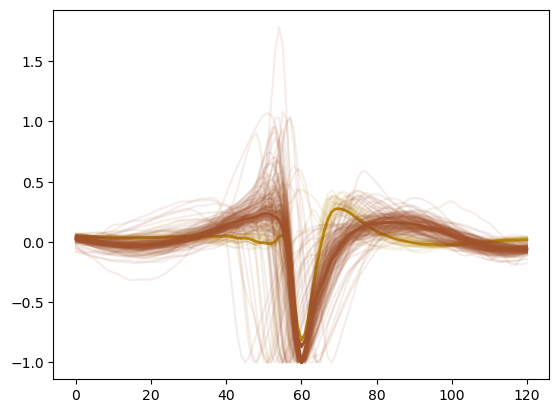

In [658]:
whisker_df_manager.plot_waveforms('FS', label='FS', color='darkgoldenrod')
whisker_df_manager.plot_waveforms('RS', label='RS', color='sienna')



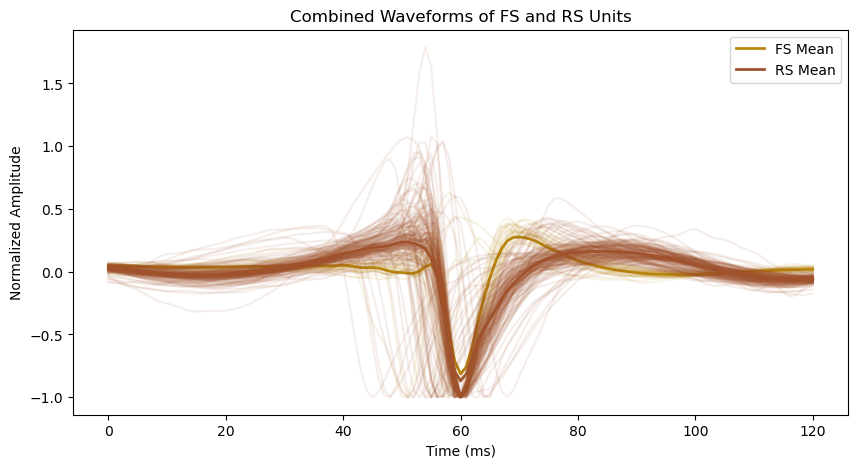

In [637]:
whisker_df_manager.plot_combined_waveforms()

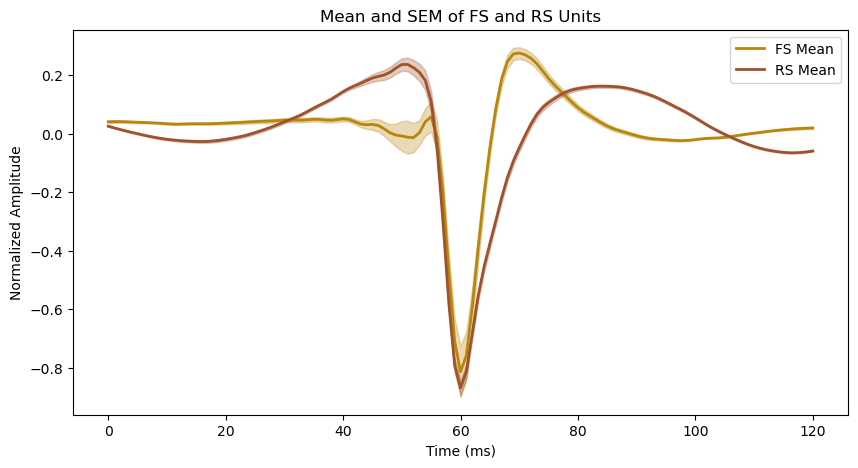

In [640]:
whisker_df_manager.plot_combined_waveforms_meansem()

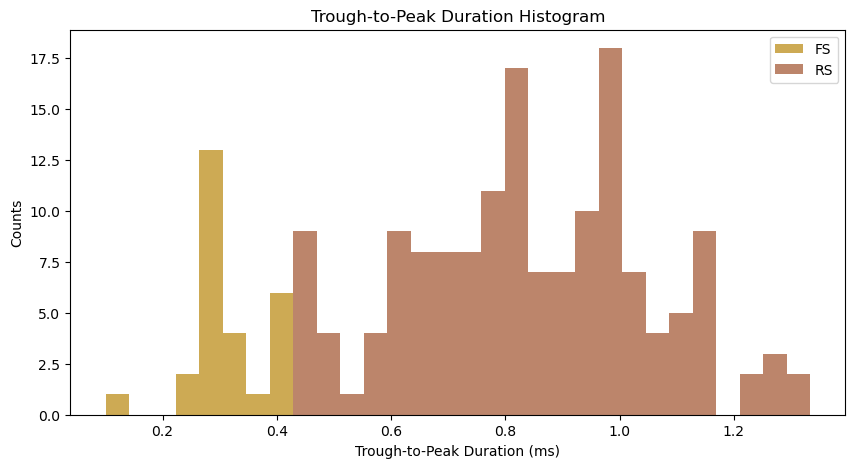

In [671]:
whisker_df_manager.plot_trough_to_peak_histogram()